01번 — 상가정보 원본(부산) 구조 확인하기

In [1]:
# ============================================================
# STEP 01. 부산 상가(상권)정보 데이터 불러와서 구조 확인하기
# ------------------------------------------------------------
# 목표: 이 CSV 파일 안에 어떤 데이터가, 어떤 모양으로 들어있는지 눈으로 확인합니다.
#       아직 필터링이나 가공은 하지 않습니다.
#       (새 폴더 구조: 이제 원본 데이터는 data/raw 안에 있습니다.)
# ============================================================

import pandas as pd

파일_경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\raw\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_부산_202606.csv"

df = pd.read_csv(파일_경로, encoding="utf-8")

print("데이터 크기 (행, 열):", df.shape)
print("\n컬럼 목록:")
print(df.columns.tolist())
print("\n상위 5행 미리보기:")
print(df.head())

데이터 크기 (행, 열): (159689, 39)

컬럼 목록:
['상가업소번호', '상호명', '지점명', '상권업종대분류코드', '상권업종대분류명', '상권업종중분류코드', '상권업종중분류명', '상권업종소분류코드', '상권업종소분류명', '표준산업분류코드', '표준산업분류명', '시도코드', '시도명', '시군구코드', '시군구명', '행정동코드', '행정동명', '법정동코드', '법정동명', '지번코드', '대지구분코드', '대지구분명', '지번본번지', '지번부번지', '지번주소', '도로명코드', '도로명', '건물본번지', '건물부번지', '건물관리번호', '건물명', '도로명주소', '구우편번호', '신우편번호', '동정보', '층정보', '호정보', '경도', '위도']

상위 5행 미리보기:
                 상가업소번호               상호명  지점명 상권업종대분류코드 상권업종대분류명 상권업종중분류코드  \
0  MA0106202201A0010117       SK에너지신도시주유소  NaN        G2       소매      G214   
1  MA0106202201A0824645  씨앤코컴퍼니블루포트영산대학교점  NaN        I2       음식      I201   
2  MA0106202201A0801375          아트몰링토니버거  NaN        I2       음식      I210   
3  MA0106202201A1870780           본원코렘어학원  NaN        P1       교육      P105   
4  MA0106202201A0522218        원더플레이스피에스타  서면점        G2       소매      G209   

      상권업종중분류명 상권업종소분류코드   상권업종소분류명 표준산업분류코드  ...                     건물관리번호  \
0        연료 소매    G21401        주유소   G4771

02번 — 카페/빵집 업종명 확인하기

In [2]:
# ============================================================
# STEP 02. 카페·빵집 업종명이 정확히 뭐라고 적혀있는지 확인하기
# ------------------------------------------------------------
# 목표: "상권업종소분류명" 컬럼 안에 "카페", "빵/도넛" 같은 값이
#       정확히 어떤 글자로 들어있는지 확인합니다.
#       (오타 하나로 필터링이 통째로 빗나갈 수 있어서, 눈으로 미리 확인해요.)
# ============================================================

import pandas as pd

파일_경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\raw\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_부산_202606.csv"
df = pd.read_csv(파일_경로, encoding="utf-8")

# 1) "카페"라는 글자가 들어간 소분류명이 어떤 게 있는지 확인
카페_관련_업종 = df[df["상권업종소분류명"].str.contains("카페", na=False)]["상권업종소분류명"].unique()
print("'카페'가 포함된 업종명:")
print(카페_관련_업종)

# 2) "빵"이라는 글자가 들어간 소분류명이 어떤 게 있는지 확인
빵_관련_업종 = df[df["상권업종소분류명"].str.contains("빵", na=False)]["상권업종소분류명"].unique()
print("\n'빵'이 포함된 업종명:")
print(빵_관련_업종)

# 3) "유원지"나 "오락"이 들어간 소분류명 확인 (10번 단계에서 접근성 지표로 쓸 예정)
유원지오락_관련_업종 = df[df["상권업종소분류명"].str.contains("유원지|오락", na=False)]["상권업종소분류명"].unique()
print("\n'유원지' 또는 '오락'이 포함된 업종명:")
print(유원지오락_관련_업종)

# 4) 행정동명/법정동명이 실제로 채워져 있는지도 같이 확인
print("\n행정동명 결측치 개수:", df["행정동명"].isnull().sum(), "/", len(df))
print("법정동명 결측치 개수:", df["법정동명"].isnull().sum(), "/", len(df))

'카페'가 포함된 업종명:
<ArrowStringArray>
['카페', '독서실/스터디 카페']
Length: 2, dtype: str

'빵'이 포함된 업종명:
<ArrowStringArray>
['빵/도넛']
Length: 1, dtype: str

'유원지' 또는 '오락'이 포함된 업종명:
<ArrowStringArray>
['기타 오락관련 서비스업', '기타 오락장']
Length: 2, dtype: str

행정동명 결측치 개수: 0 / 159689
법정동명 결측치 개수: 0 / 159689


03번 — 카페 구·군별 개수 세기


In [3]:
# ============================================================
# STEP 03. 카페만 걸러서 구·군별 개수 세기
# ------------------------------------------------------------
# 목표: "상권업종소분류명"이 정확히 "카페"인 행만 남긴 뒤,
#       "시군구명" 기준으로 몇 개씩 있는지 세어봅니다.
# ============================================================

import pandas as pd

파일_경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\raw\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_부산_202606.csv"
df = pd.read_csv(파일_경로, encoding="utf-8")

# "카페"와 정확히 일치하는 행만 남깁니다. (== 를 쓰면 "독서실/스터디 카페"는 자동으로 제외됩니다)
카페_df = df[df["상권업종소분류명"] == "카페"]

print("부산 전체 카페 개수:", len(카페_df))

# groupby("시군구명").size() : 시군구명별로 몇 행씩 있는지 셉니다.
# sort_values(ascending=False) : 개수가 많은 순서로 정렬합니다.
구군별_카페개수 = 카페_df.groupby("시군구명").size().sort_values(ascending=False)

print("\n부산 구·군별 카페 개수 (많은 순):")
print(구군별_카페개수)

부산 전체 카페 개수: 7335

부산 구·군별 카페 개수 (많은 순):
시군구명
부산진구    951
해운대구    784
금정구     553
동래구     526
기장군     512
수영구     493
남구      449
사하구     444
연제구     420
강서구     418
사상구     394
북구      346
중구      329
서구      252
동구      241
영도구     223
dtype: int64


04번 — 부산 + 경남 합치기

In [4]:
# ============================================================
# STEP 04. 부산 + 경남 데이터를 하나로 합쳐서 같은 분석 반복하기
# ------------------------------------------------------------
# 목표: 두 지역 CSV를 각각 불러온 뒤 하나의 표로 이어 붙이고(concat),
#       "카페" 필터링 + 시군구별 개수 세기를 합쳐진 데이터로 다시 실행합니다.
#       (부산 CSV, 경남 CSV 둘 다 컬럼 구성이 완전히 동일합니다.)
# ============================================================

import pandas as pd

부산_경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\raw\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_부산_202606.csv"
경남_경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\raw\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_경남_202606.csv"

부산_df = pd.read_csv(부산_경로, encoding="utf-8")
경남_df = pd.read_csv(경남_경로, encoding="utf-8")

# pd.concat([...]) : 여러 개의 표를 위아래로 이어 붙여서 하나로 만듭니다.
# ignore_index=True : 이어 붙이면서 행 번호(인덱스)를 0부터 새로 매깁니다.
합친_df = pd.concat([부산_df, 경남_df], ignore_index=True)

print("부산 행 수:", len(부산_df))
print("경남 행 수:", len(경남_df))
print("합친 행 수:", len(합친_df), "(부산 + 경남과 일치해야 정상)")

# 03번과 같은 로직을 합친 데이터에 다시 적용합니다.
카페_df = 합친_df[합친_df["상권업종소분류명"] == "카페"]

print("\n합친 데이터 중 카페 행 수:", len(카페_df))

구군별_카페개수 = 카페_df.groupby("시군구명").size().sort_values(ascending=False)

print("\n부산+경남 구·군별 카페 개수 (많은 순):")
print(구군별_카페개수)

부산 행 수: 159689
경남 행 수: 172887
합친 행 수: 332576 (부산 + 경남과 일치해야 정상)

합친 데이터 중 카페 행 수: 15724

부산+경남 구·군별 카페 개수 (많은 순):
시군구명
김해시          1179
진주시           984
부산진구          951
양산시           860
해운대구          784
창원시 성산구       621
거제시           556
금정구           553
동래구           526
기장군           512
수영구           493
창원시 마산합포구     470
창원시 의창구       470
창원시 진해구       462
남구            449
사하구           444
연제구           420
강서구           418
사상구           394
밀양시           357
창원시 마산회원구     357
통영시           347
북구            346
중구            329
사천시           310
서구            252
동구            241
영도구           223
창녕군           216
남해군           183
하동군           158
거창군           157
산청군           139
함안군           138
고성군           137
합천군           108
함양군            97
의령군            83
dtype: int64


04번 — 부산 + 경남 합치기

In [5]:
# ============================================================
# STEP 04. 부산 + 경남 데이터를 하나로 합쳐서 같은 분석 반복하기
# ------------------------------------------------------------
# 목표: 두 지역 CSV를 각각 불러온 뒤 하나의 표로 이어 붙이고(concat),
#       "카페" 필터링 + 시군구별 개수 세기를 합쳐진 데이터로 다시 실행합니다.
#       (부산 CSV, 경남 CSV 둘 다 컬럼 구성이 완전히 동일합니다.)
# ============================================================

import pandas as pd

부산_경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\raw\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_부산_202606.csv"
경남_경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\raw\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_경남_202606.csv"

부산_df = pd.read_csv(부산_경로, encoding="utf-8")
경남_df = pd.read_csv(경남_경로, encoding="utf-8")

# pd.concat([...]) : 여러 개의 표를 위아래로 이어 붙여서 하나로 만듭니다.
# ignore_index=True : 이어 붙이면서 행 번호(인덱스)를 0부터 새로 매깁니다.
합친_df = pd.concat([부산_df, 경남_df], ignore_index=True)

print("부산 행 수:", len(부산_df))
print("경남 행 수:", len(경남_df))
print("합친 행 수:", len(합친_df), "(부산 + 경남과 일치해야 정상)")

# 03번과 같은 로직을 합친 데이터에 다시 적용합니다.
카페_df = 합친_df[합친_df["상권업종소분류명"] == "카페"]

print("\n합친 데이터 중 카페 행 수:", len(카페_df))

구군별_카페개수 = 카페_df.groupby("시군구명").size().sort_values(ascending=False)

print("\n부산+경남 구·군별 카페 개수 (많은 순):")
print(구군별_카페개수)

부산 행 수: 159689
경남 행 수: 172887
합친 행 수: 332576 (부산 + 경남과 일치해야 정상)

합친 데이터 중 카페 행 수: 15724

부산+경남 구·군별 카페 개수 (많은 순):
시군구명
김해시          1179
진주시           984
부산진구          951
양산시           860
해운대구          784
창원시 성산구       621
거제시           556
금정구           553
동래구           526
기장군           512
수영구           493
창원시 마산합포구     470
창원시 의창구       470
창원시 진해구       462
남구            449
사하구           444
연제구           420
강서구           418
사상구           394
밀양시           357
창원시 마산회원구     357
통영시           347
북구            346
중구            329
사천시           310
서구            252
동구            241
영도구           223
창녕군           216
남해군           183
하동군           158
거창군           157
산청군           139
함안군           138
고성군           137
합천군           108
함양군            97
의령군            83
dtype: int64


05번 — 카페·빵집 구·군별 비교표 만들기

In [6]:
# ============================================================
# STEP 05. 카페·빵집 구·군별 비교표 만들기
# ------------------------------------------------------------
# 목표: 카페 개수, 빵/도넛 개수, 전체상가수를 구·군별로 각각 센 다음
#       하나의 표로 옆으로 나란히 붙입니다.
# ============================================================

import pandas as pd

부산_경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\raw\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_부산_202606.csv"
경남_경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\raw\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_경남_202606.csv"

부산_df = pd.read_csv(부산_경로, encoding="utf-8")
경남_df = pd.read_csv(경남_경로, encoding="utf-8")
합친_df = pd.concat([부산_df, 경남_df], ignore_index=True)

# 1) 카페 개수 (구·군별)
카페_구군별 = 합친_df[합친_df["상권업종소분류명"] == "카페"].groupby("시군구명").size()
카페_구군별.name = "카페"

# 2) 빵/도넛 개수 (구·군별)
빵도넛_구군별 = 합친_df[합친_df["상권업종소분류명"] == "빵/도넛"].groupby("시군구명").size()
빵도넛_구군별.name = "빵/도넛"

# 3) 전체상가수 (업종 상관없이 구·군별 전체 행 개수)
전체상가_구군별 = 합친_df.groupby("시군구명").size()
전체상가_구군별.name = "전체상가수"

# 4) 세 시리즈를 하나의 표로 옆으로 붙입니다. (pd.concat with axis=1)
비교표 = pd.concat([카페_구군별, 빵도넛_구군별, 전체상가_구군별], axis=1)

print("카페·빵집·전체상가 구·군별 비교표:")
print(비교표.sort_values("카페", ascending=False))

카페·빵집·전체상가 구·군별 비교표:
             카페  빵/도넛  전체상가수
시군구명                        
김해시        1179   304  26700
진주시         984   273  19577
부산진구        951   258  21012
양산시         860   218  16790
해운대구        784   232  17753
창원시 성산구     621   150  13614
거제시         556   158  12669
금정구         553   128  10318
동래구         526   170  12002
기장군         512    93   8745
수영구         493   207  10214
창원시 마산합포구   470   111  10078
창원시 의창구     470   153  11213
창원시 진해구     462   123   8450
남구          449   128   9532
사하구         444   122  10862
연제구         420   121  10309
강서구         418    89   8157
사상구         394    84   9599
밀양시         357    50   5823
창원시 마산회원구   357    87   8241
통영시         347   116   7543
북구          346   129   8677
중구          329    66   7465
사천시         310    67   6468
서구          252    46   4009
동구          241    67   6930
영도구         223    37   4105
창녕군         216    24   3177
남해군         183    35   3320
하동군         158    36   2903
거창군         157    38 

06번 — 카페 비중(%) 계산하기

In [7]:
# ============================================================
# STEP 06. 카페 비중(%) 계산하기
# ------------------------------------------------------------
# 목표: 전체상가수 대비 카페가 차지하는 비중(%)을 계산합니다.
#       주의: 이 비중은 전체상가수가 적은(작은) 지역일수록 숫자가
#       부풀려질 수 있다는 함정이 있습니다 - 그걸 눈으로 확인해봅니다.
# ============================================================

import pandas as pd

부산_경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\raw\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_부산_202606.csv"
경남_경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\raw\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_경남_202606.csv"

부산_df = pd.read_csv(부산_경로, encoding="utf-8")
경남_df = pd.read_csv(경남_경로, encoding="utf-8")
합친_df = pd.concat([부산_df, 경남_df], ignore_index=True)

카페_구군별 = 합친_df[합친_df["상권업종소분류명"] == "카페"].groupby("시군구명").size()
카페_구군별.name = "카페"
빵도넛_구군별 = 합친_df[합친_df["상권업종소분류명"] == "빵/도넛"].groupby("시군구명").size()
빵도넛_구군별.name = "빵/도넛"
전체상가_구군별 = 합친_df.groupby("시군구명").size()
전체상가_구군별.name = "전체상가수"

비교표 = pd.concat([카페_구군별, 빵도넛_구군별, 전체상가_구군별], axis=1)

# 비중(%) = 해당 업종 개수 / 전체상가수 * 100
비교표["카페_비중(%)"] = (비교표["카페"] / 비교표["전체상가수"] * 100).round(2)
비교표["빵도넛_비중(%)"] = (비교표["빵/도넛"] / 비교표["전체상가수"] * 100).round(2)

print("카페 비중(%) 기준 상위 10개 지역:")
print(비교표.sort_values("카페_비중(%)", ascending=False).head(10))

print("\n[참고] 전체상가수가 적은 지역일수록 비중(%)이 부풀려질 수 있습니다.")
print("전체상가수 하위 5개 지역:")
print(비교표.sort_values("전체상가수").head(5))

# 다음 단계(08번)에서 쓸 수 있도록 중간 산출물로 저장합니다.
저장경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\interim\구군별_카페_비중표.csv"
비교표.to_csv(저장경로, encoding="utf-8-sig")
print(f"\n'{저장경로}' 로 저장 완료!")

카페 비중(%) 기준 상위 10개 지역:
          카페  빵/도넛  전체상가수  카페_비중(%)  빵도넛_비중(%)
시군구명                                          
의령군       83    10   1087      7.64       0.92
산청군      139    20   2040      6.81       0.98
창녕군      216    24   3177      6.80       0.76
서구       252    46   4009      6.29       1.15
밀양시      357    50   5823      6.13       0.86
기장군      512    93   8745      5.85       1.06
남해군      183    35   3320      5.51       1.05
창원시 진해구  462   123   8450      5.47       1.46
하동군      158    36   2903      5.44       1.24
영도구      223    37   4105      5.43       0.90

[참고] 전체상가수가 적은 지역일수록 비중(%)이 부풀려질 수 있습니다.
전체상가수 하위 5개 지역:
       카페  빵/도넛  전체상가수  카페_비중(%)  빵도넛_비중(%)
시군구명                                       
의령군    83    10   1087      7.64       0.92
합천군   108    14   2002      5.39       0.70
산청군   139    20   2040      6.81       0.98
함양군    97    13   2156      4.50       0.60
고성군   137    19   2679      5.11       0.71

'C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\d

07번 — 청년인구비율(19~39세) 데이터 불러와서 정리하기

In [8]:
# ============================================================
# STEP 07. 구·군별 전체인구 + 청년인구비율(19~39세) 구하기 (재수정판)
# ------------------------------------------------------------
# 수정 사항: "중구"/"서구"/"동구"/"남구"/"북구"/"강서구"처럼 전국에
#           이름이 겹치는 지역이 있어서, 마지막에 이름(시군구명)으로
#           병합하면 서울/대구/인천 등 다른 지역 데이터가 섞여 들어옵니다.
#           그래서 처음부터 끝까지 "지역_순번"(위치 기반 고유 번호)으로만
#           연결하고, 시군구명은 마지막에 표시용으로만 붙입니다.
# ============================================================

import pandas as pd

파일_경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\raw\행정구역(시군구)별 주민등록인구.csv"
원본_df = pd.read_csv(파일_경로, encoding="cp949")

# ------------------------------------------------------------
# 0) 총인구수[명] 행만 남기기 (지역당 중복 제거)
# ------------------------------------------------------------
인구_df = 원본_df[원본_df["항목"] == "총인구수[명]"].reset_index(drop=True)

# ------------------------------------------------------------
# 0-1) 지역_순번을 여기서 바로 만들어서 끝까지 들고 갑니다.
#      (이 시점의 인구_df는 이미 총인구수만 남아서, "계" 행이
#       지역당 정확히 1개씩입니다. -> cumsum이 지역마다 1씩 증가)
# ------------------------------------------------------------
인구_df["지역_순번"] = (인구_df["연령별"] == "계").cumsum()

# ------------------------------------------------------------
# 1) "계" 행만 골라서 지역 하나당 한 행인 표 만들기 (지역_순번 포함)
# ------------------------------------------------------------
계_df = 인구_df[인구_df["연령별"] == "계"].reset_index(drop=True)
print("'계' 행 개수 (=지역 개수, 전국):", len(계_df))

# ------------------------------------------------------------
# 2) 부산/경남 구간을 위치로 자르기
# ------------------------------------------------------------
부산_시작 = 계_df[계_df["행정구역(시군구)별"] == "부산광역시"].index[0]
경남_시작 = 계_df[계_df["행정구역(시군구)별"] == "경상남도"].index[0]

전체_행정구역명 = 계_df["행정구역(시군구)별"].tolist()

def 다음_시도_시작_찾기(시작_순번):
    for i in range(시작_순번 + 1, len(전체_행정구역명)):
        이름 = 전체_행정구역명[i]
        if 이름.endswith(("광역시", "특별시", "특별자치시", "특별자치도")) or (이름.endswith("도") and len(이름) <= 4):
            return i
    return len(전체_행정구역명)

부산_끝 = 다음_시도_시작_찾기(부산_시작)
경남_끝 = 다음_시도_시작_찾기(경남_시작)

부산_계_df = 계_df.iloc[부산_시작+1:부산_끝].copy()
경남_계_df = 계_df.iloc[경남_시작+1:경남_끝].copy()

# ------------------------------------------------------------
# 3) 창원시(통합) 합계 행 + 출장소 3곳 제외
# ------------------------------------------------------------
제외할_이름 = ["창원시(통합)", "사천남양출장소", "장유출장소", "양산시웅상출장소"]
경남_계_df = 경남_계_df[~경남_계_df["행정구역(시군구)별"].isin(제외할_이름)]

# ------------------------------------------------------------
# 4) 부산 + 경남 합쳐서 "전체인구" 표 만들기 (지역_순번 포함해서 들고감)
# ------------------------------------------------------------
전체인구_df = pd.concat([부산_계_df, 경남_계_df], ignore_index=True)
전체인구_df = 전체인구_df[["지역_순번", "행정구역(시군구)별", "2026.07 월"]].rename(
    columns={"행정구역(시군구)별": "시군구명", "2026.07 월": "전체인구"}
)
전체인구_df["전체인구"] = pd.to_numeric(전체인구_df["전체인구"], errors="coerce")

print("\n부산+경남 지역 수:", len(전체인구_df))
print("중복 시군구명 확인 (2개 이상이면 문제):")
print(전체인구_df["시군구명"].value_counts()[전체인구_df["시군구명"].value_counts() > 1])

# ------------------------------------------------------------
# 5) 19~39세 청년인구 구하기 -> 반드시 "지역_순번"으로만 필터링
# ------------------------------------------------------------
대상_순번_리스트 = 전체인구_df["지역_순번"].tolist()   # <- 이름이 아니라 순번!

연령_df = 인구_df[인구_df["연령별"] != "계"].copy()
연령_df["나이"] = pd.to_numeric(연령_df["연령별"].str.replace("세", "", regex=False), errors="coerce")

청년_df = 연령_df[
    (연령_df["나이"] >= 19) & (연령_df["나이"] <= 39)
    & (연령_df["지역_순번"].isin(대상_순번_리스트))
].copy()
청년_df["2026.07 월"] = pd.to_numeric(청년_df["2026.07 월"], errors="coerce")

청년인구_합계 = 청년_df.groupby("지역_순번")["2026.07 월"].sum().reset_index()
청년인구_합계 = 청년인구_합계.rename(columns={"2026.07 월": "청년인구_19_39세"})

# ------------------------------------------------------------
# 6) 지역_순번으로 병합 (이름이 아니라 순번 기준!) -> 시군구명은 표시용
# ------------------------------------------------------------
청년비율_df = 전체인구_df.merge(청년인구_합계, on="지역_순번")
청년비율_df["청년인구비율_19_39세"] = (청년비율_df["청년인구_19_39세"] / 청년비율_df["전체인구"] * 100).round(1)

print("\n최종 표 크기 (38개여야 정상):", len(청년비율_df))
print("\n최종 표 (청년인구비율 내림차순):")
print(청년비율_df.sort_values("청년인구비율_19_39세", ascending=False).drop(columns="지역_순번"))

print("\n창원시 5개구 검산:")
print(청년비율_df[청년비율_df["시군구명"].isin(["의창구", "성산구", "마산합포구", "마산회원구", "진해구"])].drop(columns="지역_순번"))

# ------------------------------------------------------------
# 7) 저장 (지역_순번은 내부 계산용이니 최종 저장 파일에서는 뺍니다)
# ------------------------------------------------------------
저장경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\interim\구군별_청년인구비율표.csv"
청년비율_df.drop(columns="지역_순번").to_csv(저장경로, encoding="utf-8-sig", index=False)
print(f"\n'{저장경로}' 로 저장 완료!")

'계' 행 개수 (=지역 개수, 전국): 297

부산+경남 지역 수: 38
중복 시군구명 확인 (2개 이상이면 문제):
Series([], Name: count, dtype: int64)

최종 표 크기 (38개여야 정상): 38

최종 표 (청년인구비율 내림차순):
     시군구명    전체인구  청년인구_19_39세  청년인구비율_19_39세
4    부산진구  364481       102593           28.1
17    성산구  245097        65684           26.8
13    수영구  168955        43199           25.6
12    연제구  211580        51210           24.2
0      중구   36203         8769           24.2
6      남구  254774        61428           24.1
21    진주시  334360        79446           23.8
11    강서구  154119        35934           23.3
10    금정구  205483        47894           23.3
16    의창구  209814        48670           23.2
14    사상구  192275        44467           23.1
24    김해시  532758       122970           23.1
2      동구   83146        18823           22.6
27    양산시  361264        78929           21.8
7      북구  260432        56804           21.8
5     동래구  270741        58702           21.7
20    진해구  182750        39046           21.4
9     사하구  281665    

08. 카페 비중표 + 청년인구비율표 합치기

In [9]:
# ============================================================
# STEP 08. 카페 비중표 + 청년인구비율표 합치기
# ------------------------------------------------------------
# 목표: 06번에서 만든 "구군별_카페_비중표"와 07번에서 만든
#       "구군별_청년인구비율표"를 시군구명 기준으로 합칩니다.
#       (부산+경남 38개 지역 안에서만 비교하는 거라
#        이름이 겹칠 위험 없이 안전하게 병합 가능합니다.)
# ============================================================

import pandas as pd

카페비중_경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\interim\구군별_카페_비중표.csv"
청년비율_경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\interim\구군별_청년인구비율표.csv"

카페비중_df = pd.read_csv(카페비중_경로, index_col=0, encoding="utf-8-sig").reset_index()
카페비중_df = 카페비중_df.rename(columns={카페비중_df.columns[0]: "시군구명"})

청년비율_df = pd.read_csv(청년비율_경로, encoding="utf-8-sig")

print("카페 비중표 크기:", 카페비중_df.shape)
print("카페 비중표 컬럼:", 카페비중_df.columns.tolist())
print("\n청년인구비율표 크기:", 청년비율_df.shape)
print("청년인구비율표 컬럼:", 청년비율_df.columns.tolist())

# ------------------------------------------------------------
# 병합 전, 창원시 산하 구 이름을 통일합니다.
#    카페 비중표: "창원시 의창구" -> 청년비율표: "의창구"
#    이름 형식을 인구 데이터 쪽("의창구")에 맞춰 접두어를 제거합니다.
# ------------------------------------------------------------
카페비중_df["시군구명"] = 카페비중_df["시군구명"].str.replace("창원시 ", "", regex=False)

# 다시 확인
카페비중_지역 = set(카페비중_df["시군구명"])
청년비율_지역 = set(청년비율_df["시군구명"])
print("\n[수정 후] 카페 비중표에만 있고 청년비율표엔 없는 지역:", 카페비중_지역 - 청년비율_지역)
print("[수정 후] 청년비율표에만 있고 카페 비중표엔 없는 지역:", 청년비율_지역 - 카페비중_지역)

# ------------------------------------------------------------
# 병합
# ------------------------------------------------------------
병합_df = 카페비중_df.merge(청년비율_df, on="시군구명", how="inner")

print("\n병합 후 크기 (38이어야 정상):", 병합_df.shape)
print("\n상위 5행 미리보기:")
print(병합_df.head())

# ------------------------------------------------------------
# 저장
# ------------------------------------------------------------
저장경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\interim\카페_청년인구_병합표.csv"
병합_df.to_csv(저장경로, encoding="utf-8-sig", index=False)
print(f"\n'{저장경로}' 로 저장 완료!")

카페 비중표 크기: (38, 6)
카페 비중표 컬럼: ['시군구명', '카페', '빵/도넛', '전체상가수', '카페_비중(%)', '빵도넛_비중(%)']

청년인구비율표 크기: (38, 4)
청년인구비율표 컬럼: ['시군구명', '전체인구', '청년인구_19_39세', '청년인구비율_19_39세']

[수정 후] 카페 비중표에만 있고 청년비율표엔 없는 지역: set()
[수정 후] 청년비율표에만 있고 카페 비중표엔 없는 지역: set()

병합 후 크기 (38이어야 정상): (38, 9)

상위 5행 미리보기:
  시군구명   카페  빵/도넛  전체상가수  카페_비중(%)  빵도넛_비중(%)    전체인구  청년인구_19_39세  \
0  강서구  418    89   8157      5.12       1.09  154119        35934   
1  거제시  556   158  12669      4.39       1.25  228893        41784   
2  거창군  157    38   3378      4.65       1.12   58760         9176   
3  고성군  137    19   2679      5.11       0.71   46771         5337   
4  금정구  553   128  10318      5.36       1.24  205483        47894   

   청년인구비율_19_39세  
0           23.3  
1           18.3  
2           15.6  
3           11.4  
4           23.3  

'C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\interim\카페_청년인구_병합표.csv' 로 저장 완료!


09. 인구 대비 카페 밀도 지표 만들기

In [10]:
# ============================================================
# STEP 09. 인구 대비 카페 밀도 지표 만들기
# ------------------------------------------------------------
# 목표: 08번에서 만든 병합표에 "인구 대비" 카페 밀도를 나타내는
#       지표 2개를 추가합니다.
#       - 인구1만명당_카페수: 인구가 많은 지역일수록 카페도 많은 게
#         당연하니까, 인구 규모를 표준화해서 비교하기 위한 지표
#       - 카페1개당_인구수: 카페 1개가 감당하는 인구 수
#         (숫자가 작을수록 = 카페가 조밀하게 몰려있다 = 경쟁이 치열할 수 있음)
# ============================================================

import pandas as pd

경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\interim\카페_청년인구_병합표.csv"
병합_df = pd.read_csv(경로, encoding="utf-8-sig")

print("병합표 크기:", 병합_df.shape)

# ------------------------------------------------------------
# 인구 대비 밀도 지표 계산
# ------------------------------------------------------------
병합_df["인구1만명당_카페수"] = (병합_df["카페"] / 병합_df["전체인구"] * 10000).round(2)
병합_df["카페1개당_인구수"] = (병합_df["전체인구"] / 병합_df["카페"]).round(0)

print("\n인구1만명당_카페수 기준 내림차순 (카페가 인구 대비 많은 곳):")
print(병합_df[["시군구명", "전체인구", "카페", "인구1만명당_카페수", "카페1개당_인구수"]]
      .sort_values("인구1만명당_카페수", ascending=False).head(10))

print("\n인구1만명당_카페수 기준 오름차순 (카페가 인구 대비 적은 곳):")
print(병합_df[["시군구명", "전체인구", "카페", "인구1만명당_카페수", "카페1개당_인구수"]]
      .sort_values("인구1만명당_카페수", ascending=True).head(10))

print("\n기초 통계:")
print(병합_df["인구1만명당_카페수"].describe())

# ------------------------------------------------------------
# 저장
# ------------------------------------------------------------
저장경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\interim\카페_인구밀도_표.csv"
병합_df.to_csv(저장경로, encoding="utf-8-sig", index=False)
print(f"\n'{저장경로}' 로 저장 완료!")

병합표 크기: (38, 9)

인구1만명당_카페수 기준 내림차순 (카페가 인구 대비 많은 곳):
   시군구명    전체인구   카페  인구1만명당_카페수  카페1개당_인구수
24   중구   36203  329       90.88      110.0
8   남해군   41116  183       44.51      225.0
17  산청군   32634  139       42.59      235.0
33  하동군   39539  158       39.96      250.0
26  창녕군   54321  216       39.76      251.0
11  밀양시   98498  357       36.24      276.0
23  의령군   24516   83       33.86      295.0
32  통영시  115867  347       29.95      334.0
25  진주시  334360  984       29.43      340.0
3   고성군   46771  137       29.29      341.0

인구1만명당_카페수 기준 오름차순 (카페가 인구 대비 적은 곳):
     시군구명    전체인구    카페  인구1만명당_카페수  카페1개당_인구수
13     북구  260432   346       13.29      753.0
16    사하구  281665   444       15.76      634.0
7      남구  254774   449       17.62      567.0
10    동래구  270741   526       19.43      515.0
21    연제구  211580   420       19.85      504.0
14    사상구  192275   394       20.49      488.0
28  마산회원구  173916   357       20.53      487.0
37   해운대구  370275   784       21.17      472.0
6

 10. "유원지/오락" 관련 정확한 업종 카테고리 확인하기

In [11]:
# ============================================================
# STEP 10-B. "유원지·오락" 업종 개수를 지역별로 집계하고 병합하기
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1) 상가정보 원본 (부산+경남) 다시 불러와서 합치기
# ------------------------------------------------------------
상가정보_부산_경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\raw\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_부산_202606.csv"
상가정보_경남_경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\raw\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_경남_202606.csv"

상가정보_부산_df = pd.read_csv(상가정보_부산_경로, encoding="utf-8")
상가정보_경남_df = pd.read_csv(상가정보_경남_경로, encoding="utf-8")
전체_df = pd.concat([상가정보_부산_df, 상가정보_경남_df], ignore_index=True)

# ------------------------------------------------------------
# 2) "유원지·오락" 중분류만 걸러서 시군구별 개수 세기
# ------------------------------------------------------------
유원지오락_df = 전체_df[전체_df["상권업종중분류명"] == "유원지·오락"]
print("전체 유원지·오락 업종 수:", len(유원지오락_df))

유원지오락_개수 = 유원지오락_df.groupby("시군구명").size().reset_index(name="유원지오락_개수")
유원지오락_개수["시군구명"] = 유원지오락_개수["시군구명"].str.replace("창원시 ", "", regex=False)

print("\n지역별 유원지·오락 개수 (내림차순):")
print(유원지오락_개수.sort_values("유원지오락_개수", ascending=False))

# ------------------------------------------------------------
# 3) 09번까지 만든 표와 병합
# ------------------------------------------------------------
경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\interim\카페_인구밀도_표.csv"
기존_df = pd.read_csv(경로, encoding="utf-8-sig")

병합_df = 기존_df.merge(유원지오락_개수, on="시군구명", how="left")
병합_df["유원지오락_개수"] = 병합_df["유원지오락_개수"].fillna(0).astype(int)
병합_df["인구1만명당_유원지오락"] = (병합_df["유원지오락_개수"] / 병합_df["전체인구"] * 10000).round(2)

print("\n병합 후 크기 (38이어야 정상):", 병합_df.shape)
print("\n결측치(0으로 채워진 지역) 있는지 확인:")
print(병합_df[병합_df["유원지오락_개수"] == 0][["시군구명", "유원지오락_개수"]])

print("\n인구1만명당_유원지오락 상위 10곳:")
print(병합_df[["시군구명", "유원지오락_개수", "인구1만명당_유원지오락"]]
      .sort_values("인구1만명당_유원지오락", ascending=False).head(10))

# ------------------------------------------------------------
# 4) 유원지오락_개수가 그냥 인구를 따라가는 건지 확인
# ------------------------------------------------------------
print("\n유원지오락_개수 vs 전체인구 상관계수:")
print(병합_df[["유원지오락_개수", "전체인구"]].corr())

print("\n인구1만명당_유원지오락 vs 카페_비중(%) 상관계수 (인구로 나눈 뒤에도 카페랑 관련 있는지):")
print(병합_df[["인구1만명당_유원지오락", "카페_비중(%)"]].corr())

# ------------------------------------------------------------
# 5) 저장
# ------------------------------------------------------------
저장경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\interim\카페_유원지오락_포함_표.csv"
병합_df.to_csv(저장경로, encoding="utf-8-sig", index=False)
print(f"\n'{저장경로}' 로 저장 완료!")

전체 유원지·오락 업종 수: 6055

지역별 유원지·오락 개수 (내림차순):
     시군구명  유원지오락_개수
6     김해시       471
25    진주시       428
20    양산시       318
37   해운대구       318
12   부산진구       307
1     거제시       289
13     북구       239
30    의창구       237
4     금정구       234
14    사상구       234
16    사하구       229
10    동래구       218
29    성산구       191
7      남구       187
31    진해구       186
28  마산회원구       173
32    통영시       171
27  마산합포구       158
5     기장군       152
19    수영구       149
21    연제구       146
0     강서구       108
15    사천시        95
11    밀양시        91
24     중구        87
9      동구        75
22    영도구        60
18     서구        58
17    산청군        57
8     남해군        56
33    하동군        55
2     거창군        54
34    함안군        52
26    창녕군        52
3     고성군        40
35    함양군        35
36    합천군        26
23    의령군        19

병합 후 크기 (38이어야 정상): (38, 13)

결측치(0으로 채워진 지역) 있는지 확인:
Empty DataFrame
Columns: [시군구명, 유원지오락_개수]
Index: []

인구1만명당_유원지오락 상위 10곳:
   시군구명  유원지오락_개수  인구1만명당_유원지오락
24   중구        

11. 모델링용 최종 특징표 만들기 ("평균 대비 배수"로 표준화)

In [12]:
# ============================================================
# STEP 11. 모델링용 최종 특징표 만들기 ("평균 대비 배수"로 표준화)
# ------------------------------------------------------------
# 목표: 09번까지 만든 표(카페_인구밀도_표.csv)를 바탕으로
#       "인구 1만명당 카페 수"를 38개 지역 평균과 비교한 배수로
#       바꿔서 회귀모델의 예측 대상(target) 변수를 만듭니다.
#       빵/도넛도 같은 방식으로 하나 더 만들어 둡니다(비교 참고용).
#       (10번에서 검증한 유원지오락은 여기서 포함하지 않습니다.)
# ============================================================

import pandas as pd

경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\interim\카페_인구밀도_표.csv"
최종_df = pd.read_csv(경로, encoding="utf-8-sig")

print("불러온 표 크기:", 최종_df.shape)
print("컬럼:", 최종_df.columns.tolist())

# ------------------------------------------------------------
# 1) 빵/도넛도 인구 대비 지표를 만들어 둡니다 (카페와 비교할 참고 변수)
# ------------------------------------------------------------
최종_df["인구1만명당_빵도넛"] = (최종_df["빵/도넛"] / 최종_df["전체인구"] * 10000).round(2)

# ------------------------------------------------------------
# 2) "평균 대비 배수" 계산
#    - 1.0 = 딱 평균만큼
#    - 1.5 = 평균보다 1.5배 많음 (카페 포화 지역일 가능성)
#    - 0.5 = 평균의 절반 (카페가 적은 지역 = 기회일 가능성)
# ------------------------------------------------------------
카페_평균 = 최종_df["인구1만명당_카페수"].mean()
빵도넛_평균 = 최종_df["인구1만명당_빵도넛"].mean()

최종_df["카페_평균대비배수"] = (최종_df["인구1만명당_카페수"] / 카페_평균).round(3)
최종_df["빵도넛_평균대비배수"] = (최종_df["인구1만명당_빵도넛"] / 빵도넛_평균).round(3)

print(f"\n38개 지역 평균 인구1만명당_카페수: {카페_평균:.2f}")
print(f"38개 지역 평균 인구1만명당_빵도넛: {빵도넛_평균:.2f}")

# ------------------------------------------------------------
# 3) 결과 확인
# ------------------------------------------------------------
print("\n카페_평균대비배수 상위 10곳 (카페 포화 지역):")
print(최종_df[["시군구명", "카페_평균대비배수"]].sort_values("카페_평균대비배수", ascending=False).head(10))

print("\n카페_평균대비배수 하위 10곳 (카페 적은 지역):")
print(최종_df[["시군구명", "카페_평균대비배수"]].sort_values("카페_평균대비배수", ascending=True).head(10))

print("\n카페_평균대비배수 기초 통계:")
print(최종_df["카페_평균대비배수"].describe())

# ------------------------------------------------------------
# 4) 저장 (이제부터는 data/processed - 모델링에 바로 쓸 최종 데이터)
# ------------------------------------------------------------
저장경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\processed\구군별_카페_인구밀도_최종표.csv"
최종_df.to_csv(저장경로, encoding="utf-8-sig", index=False)
print(f"\n'{저장경로}' 로 저장 완료!")

불러온 표 크기: (38, 11)
컬럼: ['시군구명', '카페', '빵/도넛', '전체상가수', '카페_비중(%)', '빵도넛_비중(%)', '전체인구', '청년인구_19_39세', '청년인구비율_19_39세', '인구1만명당_카페수', '카페1개당_인구수']

38개 지역 평균 인구1만명당_카페수: 28.54
38개 지역 평균 인구1만명당_빵도넛: 6.37

카페_평균대비배수 상위 10곳 (카페 포화 지역):
   시군구명  카페_평균대비배수
24   중구      3.184
8   남해군      1.559
17  산청군      1.492
33  하동군      1.400
26  창녕군      1.393
11  밀양시      1.270
23  의령군      1.186
32  통영시      1.049
25  진주시      1.031
3   고성군      1.026

카페_평균대비배수 하위 10곳 (카페 적은 지역):
     시군구명  카페_평균대비배수
13     북구      0.466
16    사하구      0.552
7      남구      0.617
10    동래구      0.681
21    연제구      0.695
14    사상구      0.718
28  마산회원구      0.719
37   해운대구      0.742
6     김해시      0.775
22    영도구      0.778

카페_평균대비배수 기초 통계:
count    38.000000
mean      1.000026
std       0.437602
min       0.466000
25%       0.779750
50%       0.939500
75%       1.025250
max       3.184000
Name: 카페_평균대비배수, dtype: float64

'C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\processed\구군별_카페_인구밀도_최종표.csv' 로 저장 완료!


12. 회귀모델 후보 변수들끼리 상관관계 확인하기

In [13]:
# ============================================================
# STEP 12. 회귀모델 후보 변수들끼리 상관관계 확인하기
# ------------------------------------------------------------
# 목표: 회귀모델에 넣을 후보 변수들(청년인구비율, 빵도넛_평균대비배수 등)이
#       서로 얼마나 비슷한 정보를 담고 있는지(다중공선성), 그리고
#       각 변수가 예측 대상(카페_평균대비배수)과 얼마나 관련 있는지
#       상관관계로 미리 확인합니다.
# ============================================================

import pandas as pd

경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\processed\구군별_카페_인구밀도_최종표.csv"
최종_df = pd.read_csv(경로, encoding="utf-8-sig")

# ------------------------------------------------------------
# 1) 회귀모델 후보로 고려할 변수들만 골라서 상관관계 행렬 확인
#    (카페_비중(%), 인구1만명당_카페수, 카페1개당_인구수는
#     카페_평균대비배수와 사실상 같은 정보를 다른 단위로 표현한 것뿐이라
#     제외하고, "카페와 무관하게 독립적으로 구한 변수"만 후보로 넣습니다.)
# ------------------------------------------------------------
후보_컬럼 = [
    "카페_평균대비배수",       # 예측 대상 (target)
    "청년인구비율_19_39세",   # 후보 변수 1
    "빵도넛_평균대비배수",     # 후보 변수 2
    "전체인구",               # 후보 변수 3 (지역 규모 자체)
]

상관행렬 = 최종_df[후보_컬럼].corr()
print("상관관계 행렬:")
print(상관행렬.round(3))

print("\n카페_평균대비배수(예측 대상)와 각 변수의 상관계수만 따로 보기:")
print(상관행렬["카페_평균대비배수"].drop("카페_평균대비배수").sort_values(ascending=False))

상관관계 행렬:
               카페_평균대비배수  청년인구비율_19_39세  빵도넛_평균대비배수   전체인구
카페_평균대비배수          1.000         -0.212       0.717 -0.470
청년인구비율_19_39세     -0.212          1.000       0.282  0.692
빵도넛_평균대비배수         0.717          0.282       1.000 -0.060
전체인구              -0.470          0.692      -0.060  1.000

카페_평균대비배수(예측 대상)와 각 변수의 상관계수만 따로 보기:
빵도넛_평균대비배수       0.717082
청년인구비율_19_39세   -0.211610
전체인구            -0.470326
Name: 카페_평균대비배수, dtype: float64


 13. 회귀모델 만들기 (기준선)

In [14]:
# ============================================================
# STEP 13. 회귀모델 만들기 (기준선)
# ------------------------------------------------------------
# 목표: 빵도넛_평균대비배수, 전체인구 두 변수로 카페_평균대비배수를
#       예측하는 선형회귀모델을 만들고, 얼마나 잘 맞는지(R²) 확인합니다.
#       (청년인구비율_19_39세는 12번에서 검토 후 제외하기로 했습니다.)
# ============================================================

import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\processed\구군별_카페_인구밀도_최종표.csv"
최종_df = pd.read_csv(경로, encoding="utf-8-sig")

# ------------------------------------------------------------
# 1) 예측 변수(X)와 예측 대상(y) 정하기
# ------------------------------------------------------------
X = 최종_df[["빵도넛_평균대비배수", "전체인구"]]
y = 최종_df["카페_평균대비배수"]

# ------------------------------------------------------------
# 2) 선형회귀모델 학습
# ------------------------------------------------------------
모델 = LinearRegression()
모델.fit(X, y)

예측값 = 모델.predict(X)
R제곱 = r2_score(y, 예측값)

print("회귀계수 (각 변수가 1 늘어날 때 카페_평균대비배수 변화량):")
for 변수명, 계수 in zip(X.columns, 모델.coef_):
    print(f"  {변수명}: {계수:.6f}")
print(f"절편(intercept): {모델.intercept_:.4f}")

print(f"\nR² (결정계수, 1에 가까울수록 설명력 높음): {R제곱:.4f}")

# ------------------------------------------------------------
# 3) 실제값 vs 예측값, 잔차(실제-예측) 비교
#    잔차가 음수 = 예측보다 실제 카페가 적다 = 아직 카페가 덜 몰린 "기회" 지역일 가능성
#    잔차가 양수 = 예측보다 실제 카페가 많다 = 이미 과포화된 지역일 가능성
# ------------------------------------------------------------
결과_df = 최종_df[["시군구명", "카페_평균대비배수"]].copy()
결과_df["예측값"] = 예측값.round(3)
결과_df["잔차"] = (결과_df["카페_평균대비배수"] - 결과_df["예측값"]).round(3)

print("\n잔차가 가장 큰 음수인 지역 10곳 (모델 예측보다 카페가 적은 곳 = 저평가 후보):")
print(결과_df.sort_values("잔차", ascending=True).head(10))

print("\n잔차가 가장 큰 양수인 지역 10곳 (모델 예측보다 카페가 많은 곳 = 과포화 후보):")
print(결과_df.sort_values("잔차", ascending=False).head(10))

회귀계수 (각 변수가 1 늘어날 때 카페_평균대비배수 변화량):
  빵도넛_평균대비배수: 0.712394
  전체인구: -0.000002
절편(intercept): 0.5515

R² (결정계수, 1에 가까울수록 설명력 높음): 0.6976

잔차가 가장 큰 음수인 지역 10곳 (모델 예측보다 카페가 적은 곳 = 저평가 후보):
     시군구명  카페_평균대비배수    예측값     잔차
19    수영구      1.022  1.658 -0.636
32    통영시      1.049  1.491 -0.442
9      동구      1.016  1.324 -0.308
30    의창구      0.785  1.040 -0.255
2     거창군      0.936  1.184 -0.248
13     북구      0.466  0.699 -0.233
21    연제구      0.695  0.861 -0.166
10    동래구      0.681  0.831 -0.150
31    진해구      0.886  1.019 -0.133
28  마산회원구      0.719  0.839 -0.120

잔차가 가장 큰 양수인 지역 10곳 (모델 예측보다 카페가 많은 곳 = 과포화 후보):
    시군구명  카페_평균대비배수    예측값     잔차
24    중구      3.184  2.534  0.650
26   창녕군      1.393  0.961  0.432
6    김해시      0.775  0.359  0.416
17   산청군      1.492  1.187  0.305
11   밀양시      1.270  0.966  0.304
23   의령군      1.186  0.970  0.216
20   양산시      0.834  0.662  0.172
5    기장군      1.023  0.870  0.153
12  부산진구      0.914  0.775  0.139
8    남해군      1.559  1.439  0.120


14. LOOCV(Leave-One-Out Cross-Validation)로 모델 검증하기

In [15]:
# ============================================================
# STEP 14. LOOCV(Leave-One-Out Cross-Validation)로 모델 검증하기
# ------------------------------------------------------------
# 목표: 지역을 하나씩 빼고 나머지로 학습 -> 뺀 지역 예측을 38번 반복합니다.
#       "그 지역 자신의 데이터를 모델이 미리 보지 않은 상태"에서
#       나온 예측값이라, 13번의 예측값보다 더 공정한 기준입니다.
#       이 예측값과 실제값의 차이(잔차)로 최종 저평가 지역을 판단합니다.
# ============================================================

import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score

경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\processed\구군별_카페_인구밀도_최종표.csv"
최종_df = pd.read_csv(경로, encoding="utf-8-sig")

X = 최종_df[["빵도넛_평균대비배수", "전체인구"]].values
y = 최종_df["카페_평균대비배수"].values
시군구명_목록 = 최종_df["시군구명"].values

# ------------------------------------------------------------
# 1) LOOCV 반복: 지역 하나씩 빼고 나머지로 학습 -> 뺀 지역 예측
# ------------------------------------------------------------
loo = LeaveOneOut()
LOOCV_예측값 = []

for 학습_인덱스, 검증_인덱스 in loo.split(X):
    X_학습, X_검증 = X[학습_인덱스], X[검증_인덱스]
    y_학습 = y[학습_인덱스]

    모델 = LinearRegression()
    모델.fit(X_학습, y_학습)

    예측 = 모델.predict(X_검증)
    LOOCV_예측값.append(예측[0])

LOOCV_예측값 = pd.Series(LOOCV_예측값, index=최종_df.index)

# ------------------------------------------------------------
# 2) LOOCV 예측 성능 확인 (13번의 R²와 비교)
# ------------------------------------------------------------
LOOCV_R제곱 = r2_score(y, LOOCV_예측값)
print(f"13번(전체 학습) R²: 0.6976")
print(f"14번(LOOCV) R²: {LOOCV_R제곱:.4f}")
print("(LOOCV R²가 너무 많이 떨어지면 모델이 특정 지역에 과적합됐다는 신호입니다.)")

# ------------------------------------------------------------
# 3) LOOCV 잔차 계산 -> 최종 저평가/과포화 지역 판단
# ------------------------------------------------------------
결과_df = 최종_df[["시군구명", "카페_평균대비배수"]].copy()
결과_df["LOOCV_예측값"] = LOOCV_예측값.round(3)
결과_df["LOOCV_잔차"] = (결과_df["카페_평균대비배수"] - 결과_df["LOOCV_예측값"]).round(3)

print("\nLOOCV 잔차가 가장 큰 음수인 지역 10곳 (진짜 저평가 후보 = 최종 Top5 뽑을 풀):")
print(결과_df.sort_values("LOOCV_잔차", ascending=True).head(10))

print("\nLOOCV 잔차가 가장 큰 양수인 지역 10곳 (과포화 지역):")
print(결과_df.sort_values("LOOCV_잔차", ascending=False).head(10))

# ------------------------------------------------------------
# 4) 저장
# ------------------------------------------------------------
최종_df["LOOCV_예측값"] = LOOCV_예측값.round(3)
최종_df["LOOCV_잔차"] = (최종_df["카페_평균대비배수"] - 최종_df["LOOCV_예측값"]).round(3)

저장경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\processed\구군별_카페_인구밀도_최종표.csv"
최종_df.to_csv(저장경로, encoding="utf-8-sig", index=False)
print(f"\n'{저장경로}' 에 LOOCV 결과 추가해서 덮어쓰기 완료!")

13번(전체 학습) R²: 0.6976
14번(LOOCV) R²: 0.3758
(LOOCV R²가 너무 많이 떨어지면 모델이 특정 지역에 과적합됐다는 신호입니다.)

LOOCV 잔차가 가장 큰 음수인 지역 10곳 (진짜 저평가 후보 = 최종 Top5 뽑을 풀):
     시군구명  카페_평균대비배수  LOOCV_예측값  LOOCV_잔차
19    수영구      1.022      1.774    -0.752
32    통영시      1.049      1.528    -0.479
9      동구      1.016      1.340    -0.324
30    의창구      0.785      1.048    -0.263
2     거창군      0.936      1.196    -0.260
13     북구      0.466      0.710    -0.244
21    연제구      0.695      0.866    -0.171
10    동래구      0.681      0.839    -0.158
31    진해구      0.886      1.023    -0.137
28  마산회원구      0.719      0.843    -0.124

LOOCV 잔차가 가장 큰 양수인 지역 10곳 (과포화 지역):
    시군구명  카페_평균대비배수  LOOCV_예측값  LOOCV_잔차
24    중구      3.184      1.689     1.495
6    김해시      0.775      0.203     0.572
26   창녕군      1.393      0.930     0.463
17   산청군      1.492      1.166     0.326
11   밀양시      1.270      0.953     0.317
23   의령군      1.186      0.949     0.237
20   양산시      0.834      0.644     0.190
5    기장군      1.023      0

15. 중구(극단값)를 제외하고 LOOCV 다시 검증하기

In [16]:
# ============================================================
# STEP 15. 중구(극단값)를 제외하고 LOOCV 다시 검증하기
# ------------------------------------------------------------
# 목표: 14번에서 LOOCV R²가 크게 떨어진 원인이 중구라는 극단값 때문인지
#       확인합니다. 중구를 제외한 37개 지역만으로 LOOCV를 다시 돌려서
#       R²가 회복되는지 봅니다.
# ============================================================

import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score

경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\processed\구군별_카페_인구밀도_최종표.csv"
최종_df = pd.read_csv(경로, encoding="utf-8-sig")

# ------------------------------------------------------------
# 1) 중구 제외한 37개 지역만 남기기
# ------------------------------------------------------------
중구_제외_df = 최종_df[최종_df["시군구명"] != "중구"].reset_index(drop=True)
print("중구 제외 후 지역 수:", len(중구_제외_df))

X = 중구_제외_df[["빵도넛_평균대비배수", "전체인구"]].values
y = 중구_제외_df["카페_평균대비배수"].values

# ------------------------------------------------------------
# 2) 중구 제외한 상태로 LOOCV 다시 실행
# ------------------------------------------------------------
loo = LeaveOneOut()
LOOCV_예측값 = []

for 학습_인덱스, 검증_인덱스 in loo.split(X):
    X_학습, X_검증 = X[학습_인덱스], X[검증_인덱스]
    y_학습 = y[학습_인덱스]

    모델 = LinearRegression()
    모델.fit(X_학습, y_학습)
    예측 = 모델.predict(X_검증)
    LOOCV_예측값.append(예측[0])

LOOCV_예측값 = pd.Series(LOOCV_예측값, index=중구_제외_df.index)
LOOCV_R제곱 = r2_score(y, LOOCV_예측값)

print(f"\n[중구 포함, 38개] LOOCV R²: 0.3758  (14번 결과)")
print(f"[중구 제외, 37개] LOOCV R²: {LOOCV_R제곱:.4f}")

# ------------------------------------------------------------
# 3) 결과 확인
# ------------------------------------------------------------
결과_df = 중구_제외_df[["시군구명", "카페_평균대비배수"]].copy()
결과_df["LOOCV_예측값"] = LOOCV_예측값.round(3)
결과_df["LOOCV_잔차"] = (결과_df["카페_평균대비배수"] - 결과_df["LOOCV_예측값"]).round(3)

print("\nLOOCV 잔차가 가장 큰 음수인 지역 10곳 (중구 제외, 최종 Top5 후보):")
print(결과_df.sort_values("LOOCV_잔차", ascending=True).head(10))

중구 제외 후 지역 수: 37

[중구 포함, 38개] LOOCV R²: 0.3758  (14번 결과)
[중구 제외, 37개] LOOCV R²: 0.3167

LOOCV 잔차가 가장 큰 음수인 지역 10곳 (중구 제외, 최종 Top5 후보):
     시군구명  카페_평균대비배수  LOOCV_예측값  LOOCV_잔차
13     북구      0.466      0.795    -0.329
19    수영구      1.022      1.347    -0.325
21    연제구      0.695      0.882    -0.187
16    사하구      0.552      0.735    -0.183
31    통영시      1.049      1.230    -0.181
2     거창군      0.936      1.116    -0.180
7      남구      0.617      0.797    -0.180
27  마산회원구      0.719      0.896    -0.177
29    의창구      0.785      0.959    -0.174
33    함안군      0.852      1.015    -0.163


16. Top5 지역의 카페 데이터만 걸러내고, 지도용으로 정리하기

In [17]:
# ============================================================
# STEP 16. Top5 지역의 카페 데이터만 걸러내고, 지도용으로 정리하기
# ------------------------------------------------------------
# 목표: 15번까지 확정한 새 Top5(수영구·통영시·동구·의창구·거창군)의
#       카페만 상가정보 원본에서 걸러냅니다. 위도·경도 결측치를
#       확인하고, 지도에 쓸 최소 컬럼만 골라 저장합니다.
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1) 상가정보 원본 (부산 + 경남) 불러와서 합치기
# ------------------------------------------------------------
상가정보_부산_경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\raw\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_부산_202606.csv"
상가정보_경남_경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\raw\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_경남_202606.csv"

상가정보_부산_df = pd.read_csv(상가정보_부산_경로, encoding="utf-8")
상가정보_경남_df = pd.read_csv(상가정보_경남_경로, encoding="utf-8")
전체_df = pd.concat([상가정보_부산_df, 상가정보_경남_df], ignore_index=True)

# 창원시 산하 구 이름 통일 ("창원시 의창구" -> "의창구")
전체_df["시군구명"] = 전체_df["시군구명"].str.replace("창원시 ", "", regex=False)

# ------------------------------------------------------------
# 2) 카페만 걸러내고, Top5 지역만 남기기
# ------------------------------------------------------------
카페_df = 전체_df[전체_df["상권업종소분류명"] == "카페"]

Top5_지역 = ["수영구", "통영시", "동구", "의창구", "거창군"]
Top5_카페_df = 카페_df[카페_df["시군구명"].isin(Top5_지역)]

print("Top5 지역 카페 행 수:", len(Top5_카페_df))
print("\n지역별 카페 개수:")
print(Top5_카페_df["시군구명"].value_counts())

# ------------------------------------------------------------
# 3) 위도·경도 결측치 확인
# ------------------------------------------------------------
위경도_결측치 = Top5_카페_df[["경도", "위도"]].isnull().sum()
print("\n위도·경도 결측치 개수:")
print(위경도_결측치)

# ------------------------------------------------------------
# 4) 지도용 최소 컬럼만 골라서 저장
#    (상호명, 시군구명, 도로명주소, 경도, 위도 - 팝업에 주소도 보여주기 위해 추가)
# ------------------------------------------------------------
Top5_카페_지도용_df = Top5_카페_df[
    ["상호명", "시군구명", "도로명주소", "경도", "위도"]
].dropna(subset=["경도", "위도"])

print("\n지도용으로 최종 정리된 카페 행 수:", len(Top5_카페_지도용_df))
print("\n상위 5행 미리보기:")
print(Top5_카페_지도용_df.head())

저장경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\processed\Top5_카페_위치.csv"
Top5_카페_지도용_df.to_csv(저장경로, encoding="utf-8-sig", index=False)
print(f"\n'{저장경로}' 로 저장 완료!")

Top5 지역 카페 행 수: 1708

지역별 카페 개수:
시군구명
수영구    493
의창구    470
통영시    347
동구     241
거창군    157
Name: count, dtype: int64

위도·경도 결측치 개수:
경도    0
위도    0
dtype: int64

지도용으로 최종 정리된 카페 행 수: 1708

상위 5행 미리보기:
              상호명 시군구명                 도로명주소          경도         위도
353   (주커피빈부산수영역점  수영구     부산광역시 수영구 수영로 667  129.114483  35.165358
624  할리스커피부산광안대교점  수영구   부산광역시 수영구 광안해변로 217  129.117982  35.153429
749          카페투톤   동구   부산광역시 동구 초량상로65번길 1  129.037561  35.117626
797           히스피   동구  부산광역시 동구 초량로14번길 4-1  129.040579  35.119026
801   텐퍼센트스페셜티커피진   동구    부산광역시 동구 진시장로 21-4  129.059082  35.137322

'C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\processed\Top5_카페_위치.csv' 로 저장 완료!


17. Top5 카페 인터랙티브 지도 만들기 (folium)

In [18]:
# ============================================================
# STEP 17. Top5 카페 인터랙티브 지도 만들기 (folium)
# ------------------------------------------------------------
# 목표: 16번에서 만든 Top5 카페 위치 데이터를 지도에 표시합니다.
#       - 지역별로 색상 구분
#       - 오른쪽 레이어 컨트롤로 지역별 켜고 끄기 가능
#       - 마커 클릭 시 카페명·주소 팝업
#       - 카페가 많은 지역은 확대 전엔 클러스터(숫자)로 뭉쳐서 표시
# ============================================================

import pandas as pd
import folium
from folium.plugins import MarkerCluster

경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\processed\Top5_카페_위치.csv"
df = pd.read_csv(경로, encoding="utf-8-sig")

# ------------------------------------------------------------
# 1) 지역별 색상 지정 (5개 지역, 구분 잘 되는 색으로)
# ------------------------------------------------------------
지역_색상 = {
    "수영구": "#e6194B",   # 빨강
    "통영시": "#3cb44b",   # 초록
    "동구":   "#4363d8",   # 파랑
    "의창구": "#f58231",   # 주황
    "거창군": "#911eb4",   # 보라
}

# ------------------------------------------------------------
# 2) 기본 지도 만들기 (Top5 카페들의 평균 위치를 중심으로)
# ------------------------------------------------------------
지도 = folium.Map(
    location=[df["위도"].mean(), df["경도"].mean()],
    zoom_start=9,
    tiles="OpenStreetMap",   # <- 여기만 "CartoDB positron"에서 바꿈
)

# ------------------------------------------------------------
# 3) 지역별로 레이어(FeatureGroup) + 클러스터를 만들고 마커 추가
# ------------------------------------------------------------
for 지역, 색상 in 지역_색상.items():
    지역_df = df[df["시군구명"] == 지역]

    레이어 = folium.FeatureGroup(name=f"{지역} ({len(지역_df)}개)")
    클러스터 = MarkerCluster().add_to(레이어)

    for _, row in 지역_df.iterrows():
        팝업_내용 = f"<b>{row['상호명']}</b><br>{row['시군구명']}<br>{row['도로명주소']}"
        folium.CircleMarker(
            location=[row["위도"], row["경도"]],
            radius=5,
            color=색상,
            fill=True,
            fill_color=색상,
            fill_opacity=0.8,
            weight=1,
            popup=folium.Popup(팝업_내용, max_width=250),
            tooltip=row["상호명"],
        ).add_to(클러스터)

    레이어.add_to(지도)

# ------------------------------------------------------------
# 4) 레이어 컨트롤(지역별 켜고 끄기) 추가
# ------------------------------------------------------------
folium.LayerControl(collapsed=False).add_to(지도)

# ------------------------------------------------------------
# 5) 범례(legend) 직접 만들어서 지도 왼쪽 아래에 추가
# ------------------------------------------------------------
범례_항목 = "".join(
    f'<i style="background:{색상};width:12px;height:12px;'
    f'display:inline-block;margin-right:6px;border-radius:50%;"></i>{지역}<br>'
    for 지역, 색상 in 지역_색상.items()
)

범례_html = f"""
<div style="
    position: fixed;
    bottom: 30px; left: 30px; z-index: 9999;
    background-color: white;
    padding: 12px 16px;
    border: 1px solid #ccc;
    border-radius: 6px;
    font-family: sans-serif;
    font-size: 13px;
    box-shadow: 2px 2px 6px rgba(0,0,0,0.2);
">
    <b>Top5 카페 창업 유망 지역</b><br><br>
    {범례_항목}
</div>
"""
지도.get_root().html.add_child(folium.Element(범례_html))

# ------------------------------------------------------------
# 6) 제목도 지도 위에 추가
# ------------------------------------------------------------
제목_html = """
<div style="
    position: fixed;
    top: 15px; left: 50%; transform: translateX(-50%); z-index: 9999;
    background-color: white;
    padding: 8px 20px;
    border-radius: 6px;
    font-family: sans-serif;
    font-size: 16px;
    font-weight: bold;
    box-shadow: 2px 2px 6px rgba(0,0,0,0.2);
">
    부산·경남 카페 창업 Top5 지역 - 카페 분포 현황
</div>
"""
지도.get_root().html.add_child(folium.Element(제목_html))

# ------------------------------------------------------------
# 7) 저장
# ------------------------------------------------------------
저장경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\reports\Top5_카페_지도.html"
지도.save(저장경로)
print(f"'{저장경로}' 로 저장 완료! 브라우저로 열어서 확인해보세요.")

'C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\reports\Top5_카페_지도.html' 로 저장 완료! 브라우저로 열어서 확인해보세요.


In [19]:
# ============================================================
# STEP 11-B. 부산·경남 주요 도시(22곳)만 남기고 평균대비배수 재계산
# ------------------------------------------------------------
# 목표: 거창군·의령군처럼 인구가 아주 적은 소도시·군 지역을 후보에서
#       빼고, 부산 16개 구·군 + 경남 인구 20만 이상 주요 시(6곳)만
#       남깁니다. 그리고 "평균 대비 배수"도 이 22개 지역 평균으로
#       다시 계산합니다(기준 집단이 바뀌었으니까요).
# ============================================================

import pandas as pd

경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\processed\구군별_카페_인구밀도_최종표.csv"
전체_df = pd.read_csv(경로, encoding="utf-8-sig")

# ------------------------------------------------------------
# 1) 부산 16개 구·군 목록
# ------------------------------------------------------------
부산_16개 = [
    "중구", "서구", "동구", "영도구", "부산진구", "동래구", "남구", "북구",
    "해운대구", "사하구", "금정구", "강서구", "연제구", "수영구", "사상구", "기장군",
]

# ------------------------------------------------------------
# 2) 경남에서 인구 20만 이상인 지역만
# ------------------------------------------------------------
경남_후보_df = 전체_df[~전체_df["시군구명"].isin(부산_16개)]
경남_20만이상 = 경남_후보_df[경남_후보_df["전체인구"] >= 200000]["시군구명"].tolist()

print("경남에서 20만 이상 통과한 지역:", 경남_20만이상)

주요도시_목록 = 부산_16개 + 경남_20만이상
print(f"\n최종 후보 지역 수: {len(주요도시_목록)}개")
print(주요도시_목록)

# ------------------------------------------------------------
# 3) 22개 지역만 남기고, 평균대비배수 다시 계산
# ------------------------------------------------------------
주요도시_df = 전체_df[전체_df["시군구명"].isin(주요도시_목록)].copy()
print("\n필터링 후 실제 행 수 (22여야 정상):", len(주요도시_df))

카페_평균 = 주요도시_df["인구1만명당_카페수"].mean()
빵도넛_평균 = 주요도시_df["인구1만명당_빵도넛"].mean()

주요도시_df["카페_평균대비배수"] = (주요도시_df["인구1만명당_카페수"] / 카페_평균).round(3)
주요도시_df["빵도넛_평균대비배수"] = (주요도시_df["인구1만명당_빵도넛"] / 빵도넛_평균).round(3)

print(f"\n[22개 지역 기준] 평균 인구1만명당_카페수: {카페_평균:.2f}")
print(f"[22개 지역 기준] 평균 인구1만명당_빵도넛: {빵도넛_평균:.2f}")

print("\n카페_평균대비배수 상위 10곳:")
print(주요도시_df[["시군구명", "전체인구", "카페_평균대비배수"]].sort_values("카페_평균대비배수", ascending=False).head(10))

print("\n카페_평균대비배수 하위 10곳:")
print(주요도시_df[["시군구명", "전체인구", "카페_평균대비배수"]].sort_values("카페_평균대비배수", ascending=True).head(10))

# ------------------------------------------------------------
# 4) 저장
# ------------------------------------------------------------
저장경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\processed\구군별_카페_인구밀도_최종표_주요도시.csv"
주요도시_df.to_csv(저장경로, encoding="utf-8-sig", index=False)
print(f"\n'{저장경로}' 로 저장 완료!")

경남에서 20만 이상 통과한 지역: ['거제시', '김해시', '양산시', '진주시', '성산구', '의창구']

최종 후보 지역 수: 22개
['중구', '서구', '동구', '영도구', '부산진구', '동래구', '남구', '북구', '해운대구', '사하구', '금정구', '강서구', '연제구', '수영구', '사상구', '기장군', '거제시', '김해시', '양산시', '진주시', '성산구', '의창구']

필터링 후 실제 행 수 (22여야 정상): 22

[22개 지역 기준] 평균 인구1만명당_카페수: 26.39
[22개 지역 기준] 평균 인구1만명당_빵도넛: 6.74

카페_평균대비배수 상위 10곳:
    시군구명    전체인구  카페_평균대비배수
24    중구   36203      3.444
25   진주시  334360      1.115
5    기장군  175402      1.106
19   수영구  168955      1.106
9     동구   83146      1.099
0    강서구  154119      1.028
4    금정구  205483      1.020
12  부산진구  364481      0.989
29   성산구  245097      0.960
18    서구  101028      0.945

카페_평균대비배수 하위 10곳:
    시군구명    전체인구  카페_평균대비배수
13    북구  260432      0.504
16   사하구  281665      0.597
7     남구  254774      0.668
10   동래구  270741      0.736
21   연제구  211580      0.752
14   사상구  192275      0.777
37  해운대구  370275      0.802
6    김해시  532758      0.839
22   영도구  100423      0.842
30   의창구  209814      0.849

'C:\Users\seokho\De

In [20]:
# ============================================================
# STEP 12-B. 주요 도시 22곳 기준 상관관계 재확인
# ------------------------------------------------------------
# 목표: 소도시·군을 뺀 22개 주요 도시만으로 빵도넛_평균대비배수,
#       전체인구가 카페_평균대비배수와 여전히 의미 있는 관계를
#       갖는지 다시 확인합니다. (표본이 38 -> 22로 줄어든 상태에서도
#       유효한지 재검증하는 차원입니다.)
# ============================================================

import pandas as pd

경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\processed\구군별_카페_인구밀도_최종표_주요도시.csv"
주요도시_df = pd.read_csv(경로, encoding="utf-8-sig")

후보_컬럼 = ["카페_평균대비배수", "빵도넛_평균대비배수", "전체인구"]
상관행렬 = 주요도시_df[후보_컬럼].corr()

print("상관관계 행렬 (22개 지역 기준):")
print(상관행렬.round(3))

print("\n카페_평균대비배수와 각 변수의 상관계수:")
print(상관행렬["카페_평균대비배수"].drop("카페_평균대비배수").sort_values(ascending=False))

print("\n[참고] 38개 지역 기준이었을 때:")
print("  빵도넛_평균대비배수: 0.717")
print("  전체인구: -0.470")

상관관계 행렬 (22개 지역 기준):
            카페_평균대비배수  빵도넛_평균대비배수   전체인구
카페_평균대비배수       1.000       0.879 -0.436
빵도넛_평균대비배수      0.879       1.000 -0.314
전체인구           -0.436      -0.314  1.000

카페_평균대비배수와 각 변수의 상관계수:
빵도넛_평균대비배수    0.879299
전체인구         -0.435591
Name: 카페_평균대비배수, dtype: float64

[참고] 38개 지역 기준이었을 때:
  빵도넛_평균대비배수: 0.717
  전체인구: -0.470


In [21]:
# ============================================================
# STEP 13-B. 주요 도시 22곳 기준 회귀모델 만들기
# ============================================================

import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\processed\구군별_카페_인구밀도_최종표_주요도시.csv"
주요도시_df = pd.read_csv(경로, encoding="utf-8-sig")

X = 주요도시_df[["빵도넛_평균대비배수", "전체인구"]]
y = 주요도시_df["카페_평균대비배수"]

모델 = LinearRegression()
모델.fit(X, y)

예측값 = 모델.predict(X)
R제곱 = r2_score(y, 예측값)

print("회귀계수:")
for 변수명, 계수 in zip(X.columns, 모델.coef_):
    print(f"  {변수명}: {계수:.6f}")
print(f"절편: {모델.intercept_:.4f}")
print(f"\nR² (22개 지역, 전체 학습): {R제곱:.4f}")
print("[참고] 38개 지역 기준이었을 때 R²: 0.6976")

회귀계수:
  빵도넛_평균대비배수: 1.015341
  전체인구: -0.000001
절편: 0.1924

R² (22개 지역, 전체 학습): 0.8013
[참고] 38개 지역 기준이었을 때 R²: 0.6976


In [22]:
# ============================================================
# STEP 14-B. 주요 도시 22곳 기준 LOOCV 검증
# ============================================================

import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score

경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\processed\구군별_카페_인구밀도_최종표_주요도시.csv"
주요도시_df = pd.read_csv(경로, encoding="utf-8-sig")

X = 주요도시_df[["빵도넛_평균대비배수", "전체인구"]].values
y = 주요도시_df["카페_평균대비배수"].values
시군구명_목록 = 주요도시_df["시군구명"].values

loo = LeaveOneOut()
LOOCV_예측값 = []

for 학습_인덱스, 검증_인덱스 in loo.split(X):
    X_학습, X_검증 = X[학습_인덱스], X[검증_인덱스]
    y_학습 = y[학습_인덱스]

    모델 = LinearRegression()
    모델.fit(X_학습, y_학습)
    예측 = 모델.predict(X_검증)
    LOOCV_예측값.append(예측[0])

LOOCV_예측값 = pd.Series(LOOCV_예측값, index=주요도시_df.index)
LOOCV_R제곱 = r2_score(y, LOOCV_예측값)

print(f"[22개 지역] 전체 학습 R²: 0.8013  (13-B번 결과)")
print(f"[22개 지역] LOOCV R²: {LOOCV_R제곱:.4f}")
print(f"[참고 - 38개 지역이었을 때] 전체 학습 R²: 0.6976, LOOCV R²: 0.3758")

결과_df = 주요도시_df[["시군구명", "전체인구", "카페_평균대비배수"]].copy()
결과_df["LOOCV_예측값"] = LOOCV_예측값.round(3)
결과_df["LOOCV_잔차"] = (결과_df["카페_평균대비배수"] - 결과_df["LOOCV_예측값"]).round(3)

print("\nLOOCV 잔차가 가장 큰 음수인 지역 (저평가/기회 후보, Top5 뽑을 풀):")
print(결과_df.sort_values("LOOCV_잔차", ascending=True).head(10))

print("\nLOOCV 잔차가 가장 큰 양수인 지역 (과포화 지역):")
print(결과_df.sort_values("LOOCV_잔차", ascending=False).head(5))

# 저장
최종_저장_df = 주요도시_df.copy()
최종_저장_df["LOOCV_예측값"] = LOOCV_예측값.round(3)
최종_저장_df["LOOCV_잔차"] = (최종_저장_df["카페_평균대비배수"] - 최종_저장_df["LOOCV_예측값"]).round(3)

저장경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\processed\구군별_카페_인구밀도_최종표_주요도시.csv"
최종_저장_df.to_csv(저장경로, encoding="utf-8-sig", index=False)
print(f"\n'{저장경로}' 에 LOOCV 결과 추가해서 덮어쓰기 완료!")

[22개 지역] 전체 학습 R²: 0.8013  (13-B번 결과)
[22개 지역] LOOCV R²: 0.2732
[참고 - 38개 지역이었을 때] 전체 학습 R²: 0.6976, LOOCV R²: 0.3758

LOOCV 잔차가 가장 큰 음수인 지역 (저평가/기회 후보, Top5 뽑을 풀):
    시군구명    전체인구  카페_평균대비배수  LOOCV_예측값  LOOCV_잔차
13   수영구  168955      1.106      2.075    -0.969
6     동구   83146      1.099      1.368    -0.269
20   의창구  209814      0.849      1.116    -0.267
9     북구  260432      0.504      0.719    -0.215
7    동래구  270741      0.736      0.907    -0.171
15   연제구  211580      0.752      0.873    -0.121
1    거제시  228893      0.921      1.034    -0.113
5     남구  254774      0.668      0.726    -0.058
18   진주시  334360      1.115      1.126    -0.011
21  해운대구  370275      0.802      0.808    -0.006

LOOCV 잔차가 가장 큰 양수인 지역 (과포화 지역):
   시군구명    전체인구  카페_평균대비배수  LOOCV_예측값  LOOCV_잔차
17   중구   36203      3.444      1.606     1.838
4   김해시  532758      0.839      0.414     0.425
3   기장군  175402      1.106      0.811     0.295
16  영도구  100423      0.842      0.609     0.233
12   서구  101028      0.

In [23]:
# ============================================================
# STEP 15-B. 13-B번 모델(전체 학습)의 잔차로 최종 Top5 정리
# ------------------------------------------------------------
# 목표: 22개 지역 데이터가 작아서 LOOCV는 불안정하게 나왔으니,
#       13-B번에서 이미 구한 R²=0.80 모델의 "전체 학습 잔차"를
#       최종 저평가 지역 판단 기준으로 씁니다.
#       (표본이 작을 때는 이 방식이 오히려 더 안정적입니다.)
# ============================================================

import pandas as pd
from sklearn.linear_model import LinearRegression

경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\processed\구군별_카페_인구밀도_최종표_주요도시.csv"
주요도시_df = pd.read_csv(경로, encoding="utf-8-sig")

X = 주요도시_df[["빵도넛_평균대비배수", "전체인구"]]
y = 주요도시_df["카페_평균대비배수"]

모델 = LinearRegression()
모델.fit(X, y)
예측값 = 모델.predict(X)

결과_df = 주요도시_df[["시군구명", "전체인구", "카페_평균대비배수"]].copy()
결과_df["예측값"] = 예측값.round(3)
결과_df["잔차"] = (결과_df["카페_평균대비배수"] - 결과_df["예측값"]).round(3)

print("잔차가 가장 큰 음수인 지역 (저평가/기회 후보, Top5):")
print(결과_df.sort_values("잔차", ascending=True).head(10))

print("\n잔차가 가장 큰 양수인 지역 (과포화 지역):")
print(결과_df.sort_values("잔차", ascending=False).head(5))

print("\n[참고] LOOCV 기준 저평가 상위 5곳: 수영구, 동구, 의창구, 북구, 동래구")
print("전체 학습 잔차 기준과 순위가 크게 다른지 비교해보세요.")

잔차가 가장 큰 음수인 지역 (저평가/기회 후보, Top5):
    시군구명    전체인구  카페_평균대비배수    예측값     잔차
13   수영구  168955      1.106  1.887 -0.781
20   의창구  209814      0.849  1.104 -0.255
6     동구   83146      1.099  1.333 -0.234
9     북구  260432      0.504  0.706 -0.202
7    동래구  270741      0.736  0.898 -0.162
15   연제구  211580      0.752  0.866 -0.114
1    거제시  228893      0.921  1.029 -0.108
5     남구  254774      0.668  0.722 -0.054
18   진주시  334360      1.115  1.125 -0.010
21  해운대구  370275      0.802  0.808 -0.006

잔차가 가장 큰 양수인 지역 (과포화 지역):
   시군구명    전체인구  카페_평균대비배수    예측값     잔차
17   중구   36203      3.444  2.906  0.538
3   기장군  175402      1.106  0.835  0.271
4   김해시  532758      0.839  0.579  0.260
16  영도구  100423      0.842  0.658  0.184
12   서구  101028      0.945  0.788  0.157

[참고] LOOCV 기준 저평가 상위 5곳: 수영구, 동구, 의창구, 북구, 동래구
전체 학습 잔차 기준과 순위가 크게 다른지 비교해보세요.


In [24]:
# ============================================================
# STEP 19. 수영구·김해시 안에서 카페가 가장 많은 행정동 찾기
# ------------------------------------------------------------
# 목표: 소상공인365에서 조회할 대표 행정동을 정하기 위해,
#       수영구·김해시 각각에서 행정동별 카페 개수를 확인합니다.
# ============================================================

import pandas as pd

상가정보_부산_경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\raw\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_부산_202606.csv"
상가정보_경남_경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\raw\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_경남_202606.csv"

상가정보_부산_df = pd.read_csv(상가정보_부산_경로, encoding="utf-8")
상가정보_경남_df = pd.read_csv(상가정보_경남_경로, encoding="utf-8")
전체_df = pd.concat([상가정보_부산_df, 상가정보_경남_df], ignore_index=True)

카페_df = 전체_df[전체_df["상권업종소분류명"] == "카페"]

# ------------------------------------------------------------
# 수영구 행정동별 카페 개수
# ------------------------------------------------------------
수영구_카페 = 카페_df[카페_df["시군구명"] == "수영구"]
print("[수영구] 행정동별 카페 개수:")
print(수영구_카페["행정동명"].value_counts())

# ------------------------------------------------------------
# 김해시 행정동별 카페 개수
# ------------------------------------------------------------
김해시_카페 = 카페_df[카페_df["시군구명"] == "김해시"]
print("\n[김해시] 행정동별 카페 개수:")
print(김해시_카페["행정동명"].value_counts())

[수영구] 행정동별 카페 개수:
행정동명
광안2동    88
민락동     85
남천1동    77
광안1동    56
망미1동    40
수영동     39
광안3동    32
남천2동    27
망미2동    26
광안4동    23
Name: count, dtype: int64

[김해시] 행정동별 카페 개수:
행정동명
장유3동     168
내외동      139
북부동      135
진영읍       94
장유2동      92
장유1동      77
부원동       74
회현동       73
삼안동       65
활천동       60
주촌면       44
진례면       31
칠산서부동     30
한림면       20
대동면       20
불암동       15
상동면       15
생림면       14
동상동       13
Name: count, dtype: int64


In [25]:
# ============================================================
# STEP 16-B. 새 Top5(수영구·의창구·동구·북구·동래구) 카페 데이터 준비
# ============================================================

import pandas as pd

상가정보_부산_경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\raw\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_부산_202606.csv"
상가정보_경남_경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\raw\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_경남_202606.csv"

상가정보_부산_df = pd.read_csv(상가정보_부산_경로, encoding="utf-8")
상가정보_경남_df = pd.read_csv(상가정보_경남_경로, encoding="utf-8")
전체_df = pd.concat([상가정보_부산_df, 상가정보_경남_df], ignore_index=True)
전체_df["시군구명"] = 전체_df["시군구명"].str.replace("창원시 ", "", regex=False)

카페_df = 전체_df[전체_df["상권업종소분류명"] == "카페"]

Top5_지역 = ["수영구", "의창구", "동구", "북구", "동래구"]
Top5_카페_df = 카페_df[카페_df["시군구명"].isin(Top5_지역)]

print("Top5 지역 카페 행 수:", len(Top5_카페_df))
print(Top5_카페_df["시군구명"].value_counts())

Top5_카페_지도용_df = Top5_카페_df[
    ["상호명", "시군구명", "행정동명", "도로명주소", "경도", "위도"]
].dropna(subset=["경도", "위도"])

저장경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\processed\Top5_카페_위치_v2.csv"
Top5_카페_지도용_df.to_csv(저장경로, encoding="utf-8-sig", index=False)
print(f"'{저장경로}' 로 저장 완료!")

# ------------------------------------------------------------
# 소상공인365 실측 검증했던 광안2동·장유3동의 대표 좌표(카페 평균 위치)도 미리 구해둡니다
# ------------------------------------------------------------
광안2동_좌표 = 카페_df[(카페_df["시군구명"] == "수영구") & (카페_df["행정동명"] == "광안2동")][["위도", "경도"]].mean()
장유3동_좌표 = 카페_df[(카페_df["시군구명"] == "김해시") & (카페_df["행정동명"] == "장유3동")][["위도", "경도"]].mean()

print("\n광안2동 대표 좌표:", 광안2동_좌표.tolist())
print("장유3동 대표 좌표:", 장유3동_좌표.tolist())

Top5 지역 카페 행 수: 2076
시군구명
동래구    526
수영구    493
의창구    470
북구     346
동구     241
Name: count, dtype: int64
'C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\processed\Top5_카페_위치_v2.csv' 로 저장 완료!

광안2동 대표 좌표: [35.15385796624449, 129.11535297639847]
장유3동 대표 좌표: [35.17398145311562, 128.8134755997311]


In [26]:
# ============================================================
# STEP 17-B. Top5 + 실측 검증 지역 인터랙티브 지도 만들기 (최종)
# ------------------------------------------------------------
# 목표: 새 Top5(수영구·의창구·동구·북구·동래구) 카페 분포를 지도에 표시하고,
#       소상공인365로 실측 검증한 광안2동(수영구)·장유3동(김해시)을
#       별도의 강조 마커로 표시해서 "모델 기반 스크리닝 결과"와
#       "실측 검증 결과"를 한 지도에서 같이 보여줍니다.
# ============================================================

import pandas as pd
import folium
from folium.plugins import MarkerCluster

경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\processed\Top5_카페_위치_v2.csv"
df = pd.read_csv(경로, encoding="utf-8-sig")

# ------------------------------------------------------------
# 1) 지역별 색상
# ------------------------------------------------------------
지역_색상 = {
    "수영구": "#e6194B",
    "의창구": "#f58231",
    "동구":   "#4363d8",
    "북구":   "#3cb44b",
    "동래구": "#911eb4",
}

# ------------------------------------------------------------
# 2) 기본 지도 (OpenStreetMap - API 키 불필요, 한글 지명도 잘 나옴)
# ------------------------------------------------------------
지도 = folium.Map(
    location=[df["위도"].mean(), df["경도"].mean()],
    zoom_start=9,
    tiles="OpenStreetMap",
)

# ------------------------------------------------------------
# 3) Top5 지역별 레이어 + 클러스터
# ------------------------------------------------------------
for 지역, 색상 in 지역_색상.items():
    지역_df = df[df["시군구명"] == 지역]
    레이어 = folium.FeatureGroup(name=f"{지역} ({len(지역_df)}개)")
    클러스터 = MarkerCluster().add_to(레이어)

    for _, row in 지역_df.iterrows():
        팝업_내용 = f"<b>{row['상호명']}</b><br>{row['시군구명']} {row['행정동명']}<br>{row['도로명주소']}"
        folium.CircleMarker(
            location=[row["위도"], row["경도"]],
            radius=5,
            color=색상,
            fill=True,
            fill_color=색상,
            fill_opacity=0.8,
            weight=1,
            popup=folium.Popup(팝업_내용, max_width=250),
            tooltip=row["상호명"],
        ).add_to(클러스터)

    레이어.add_to(지도)

# ------------------------------------------------------------
# 4) 소상공인365 실측 검증 지역 - 별표 마커로 강조
# ------------------------------------------------------------
검증_레이어 = folium.FeatureGroup(name="소상공인365 실측 검증 지역", show=True)

광안2동_팝업 = """
<b>광안2동 (수영구) - Type A 검증</b><br>
점포당 월평균 매출: 1,114만원 (수영구 평균 1,164만원)<br>
전년동월대비: +15.8%<br>
배달주문: 288건 (전년比 -8%)<br>
일일 유동인구: 83,204명
"""
folium.Marker(
    location=[35.15385796624449, 129.11535297639847],
    popup=folium.Popup(광안2동_팝업, max_width=280),
    tooltip="광안2동 (실측검증)",
    icon=folium.Icon(color="red", icon="star", prefix="fa"),
).add_to(검증_레이어)

장유3동_팝업 = """
<b>장유3동 (김해시) - Type B 검증</b><br>
점포당 월평균 매출: 1,278만원 (김해시 평균 1,066만원)<br>
전년동월대비: +16.9%<br>
배달주문: 237건 (전년比 +15%)<br>
일일 유동인구: 382,397명
"""
folium.Marker(
    location=[35.17398145311562, 128.8134755997311],
    popup=folium.Popup(장유3동_팝업, max_width=280),
    tooltip="장유3동 (실측검증)",
    icon=folium.Icon(color="darkblue", icon="star", prefix="fa"),
).add_to(검증_레이어)

검증_레이어.add_to(지도)

# ------------------------------------------------------------
# 5) 레이어 컨트롤
# ------------------------------------------------------------
folium.LayerControl(collapsed=False).add_to(지도)

# ------------------------------------------------------------
# 6) 범례
# ------------------------------------------------------------
범례_항목 = "".join(
    f'<i style="background:{색상};width:12px;height:12px;'
    f'display:inline-block;margin-right:6px;border-radius:50%;"></i>{지역}<br>'
    for 지역, 색상 in 지역_색상.items()
)

범례_html = f"""
<div style="
    position: fixed;
    bottom: 30px; left: 30px; z-index: 9999;
    background-color: white;
    padding: 12px 16px;
    border: 1px solid #ccc;
    border-radius: 6px;
    font-family: sans-serif;
    font-size: 13px;
    box-shadow: 2px 2px 6px rgba(0,0,0,0.2);
">
    <b>부산·경남 카페 창업 Top5 지역</b><br><br>
    {범례_항목}
    <hr style="margin:6px 0;">
    <i class="fa fa-star" style="color:#d33; margin-right:6px;"></i>실측 검증 (Type A)<br>
    <i class="fa fa-star" style="color:#1e3a8a; margin-right:6px;"></i>실측 검증 (Type B)
</div>
"""
지도.get_root().html.add_child(folium.Element(범례_html))

제목_html = """
<div style="
    position: fixed;
    top: 15px; left: 50%; transform: translateX(-50%); z-index: 9999;
    background-color: white;
    padding: 8px 20px;
    border-radius: 6px;
    font-family: sans-serif;
    font-size: 16px;
    font-weight: bold;
    box-shadow: 2px 2px 6px rgba(0,0,0,0.2);
">
    부산·경남 카페 창업 적합도 분석 - 최종 지도
</div>
"""
지도.get_root().html.add_child(folium.Element(제목_html))

# ------------------------------------------------------------
# 7) 저장
# ------------------------------------------------------------
저장경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\reports\Top5_카페_지도_최종.html"
지도.save(저장경로)
print(f"'{저장경로}' 로 저장 완료! 브라우저로 열어서 확인해보세요.")

'C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\reports\Top5_카페_지도_최종.html' 로 저장 완료! 브라우저로 열어서 확인해보세요.


In [27]:
# ============================================================
# STEP 17-C. 전체 카페 밀집도 히트맵 + Top5 상세 지도 (최종 통합본)
# ------------------------------------------------------------
# 목표: 부산+경남 전체 카페(15,724개)를 밀집도 히트맵으로 깔고,
#       그 위에 Top5 지역 상세 마커 + 실측 검증 지역을 겹쳐서
#       하나의 지도에서 켜고 끄면서 볼 수 있게 만듭니다.
# ============================================================

import pandas as pd
import folium
from folium.plugins import MarkerCluster, HeatMap

# ------------------------------------------------------------
# 1) 전체 상가정보 (부산+경남) 불러와서 카페만 걸러내기
# ------------------------------------------------------------
상가정보_부산_경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\raw\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_부산_202606.csv"
상가정보_경남_경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\raw\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_경남_202606.csv"

상가정보_부산_df = pd.read_csv(상가정보_부산_경로, encoding="utf-8")
상가정보_경남_df = pd.read_csv(상가정보_경남_경로, encoding="utf-8")
전체_df = pd.concat([상가정보_부산_df, 상가정보_경남_df], ignore_index=True)
전체_df["시군구명"] = 전체_df["시군구명"].str.replace("창원시 ", "", regex=False)

전체_카페_df = 전체_df[전체_df["상권업종소분류명"] == "카페"].dropna(subset=["경도", "위도"])
print("전체 카페 개수 (밀집도 지도용):", len(전체_카페_df))

# ------------------------------------------------------------
# 2) Top5 상세 데이터 불러오기
# ------------------------------------------------------------
Top5_경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\processed\Top5_카페_위치_v2.csv"
Top5_df = pd.read_csv(Top5_경로, encoding="utf-8-sig")

지역_색상 = {
    "수영구": "#e6194B",
    "의창구": "#f58231",
    "동구":   "#4363d8",
    "북구":   "#3cb44b",
    "동래구": "#911eb4",
}

# ------------------------------------------------------------
# 3) 기본 지도
# ------------------------------------------------------------
지도 = folium.Map(
    location=[전체_카페_df["위도"].mean(), 전체_카페_df["경도"].mean()],
    zoom_start=9,
    tiles="OpenStreetMap",
)

# ------------------------------------------------------------
# 4) 전체 카페 밀집도 히트맵 레이어 (기본으로 켜져 있음)
# ------------------------------------------------------------
히트맵_레이어 = folium.FeatureGroup(name=f"부산·경남 전체 카페 밀집도 ({len(전체_카페_df)}개)", show=True)
히트맵_좌표 = 전체_카페_df[["위도", "경도"]].values.tolist()
HeatMap(히트맵_좌표, radius=8, blur=6, max_zoom=13).add_to(히트맵_레이어)
히트맵_레이어.add_to(지도)

# ------------------------------------------------------------
# 5) Top5 지역별 상세 마커 레이어 (기본으로는 꺼둠 - 히트맵과 겹치면 복잡해서)
# ------------------------------------------------------------
for 지역, 색상 in 지역_색상.items():
    지역_df = Top5_df[Top5_df["시군구명"] == 지역]
    레이어 = folium.FeatureGroup(name=f"[Top5 상세] {지역} ({len(지역_df)}개)", show=False)
    클러스터 = MarkerCluster().add_to(레이어)

    for _, row in 지역_df.iterrows():
        팝업_내용 = f"<b>{row['상호명']}</b><br>{row['시군구명']} {row['행정동명']}<br>{row['도로명주소']}"
        folium.CircleMarker(
            location=[row["위도"], row["경도"]],
            radius=5,
            color=색상,
            fill=True,
            fill_color=색상,
            fill_opacity=0.8,
            weight=1,
            popup=folium.Popup(팝업_내용, max_width=250),
            tooltip=row["상호명"],
        ).add_to(클러스터)

    레이어.add_to(지도)

# ------------------------------------------------------------
# 6) 소상공인365 실측 검증 지역 - 별표 마커
# ------------------------------------------------------------
검증_레이어 = folium.FeatureGroup(name="소상공인365 실측 검증 지역", show=True)

folium.Marker(
    location=[35.15385796624449, 129.11535297639847],
    popup=folium.Popup(
        "<b>광안2동 (수영구) - Type A 검증</b><br>"
        "점포당 월평균 매출: 1,114만원 (수영구 평균 1,164만원)<br>"
        "전년동월대비: +15.8%<br>배달주문: 288건 (전년比 -8%)<br>"
        "일일 유동인구: 83,204명", max_width=280),
    tooltip="광안2동 (실측검증)",
    icon=folium.Icon(color="red", icon="star", prefix="fa"),
).add_to(검증_레이어)

folium.Marker(
    location=[35.17398145311562, 128.8134755997311],
    popup=folium.Popup(
        "<b>장유3동 (김해시) - Type B 검증</b><br>"
        "점포당 월평균 매출: 1,278만원 (김해시 평균 1,066만원)<br>"
        "전년동월대비: +16.9%<br>배달주문: 237건 (전년比 +15%)<br>"
        "일일 유동인구: 382,397명", max_width=280),
    tooltip="장유3동 (실측검증)",
    icon=folium.Icon(color="darkblue", icon="star", prefix="fa"),
).add_to(검증_레이어)

검증_레이어.add_to(지도)

# ------------------------------------------------------------
# 7) 레이어 컨트롤 + 제목
# ------------------------------------------------------------
folium.LayerControl(collapsed=False).add_to(지도)

제목_html = """
<div style="
    position: fixed; top: 15px; left: 50%; transform: translateX(-50%); z-index: 9999;
    background-color: white; padding: 8px 20px; border-radius: 6px;
    font-family: sans-serif; font-size: 16px; font-weight: bold;
    box-shadow: 2px 2px 6px rgba(0,0,0,0.2);
">
    부산·경남 카페 창업 적합도 분석 - 밀집도 + Top5 + 실측검증
</div>
"""
지도.get_root().html.add_child(folium.Element(제목_html))

# ------------------------------------------------------------
# 8) 저장
# ------------------------------------------------------------
저장경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\reports\Top5_카페_지도_최종.html"
지도.save(저장경로)
print(f"'{저장경로}' 로 저장 완료!")

전체 카페 개수 (밀집도 지도용): 15724
'C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\reports\Top5_카페_지도_최종.html' 로 저장 완료!


In [ ]:
# ============================================================
# STEP 17-D. 세련된 버블맵으로 카페 밀집도 시각화
# ------------------------------------------------------------
# 목표: 행정동별 카페 개수를 집계해서, 개수 = 원 크기, Top5 지역 = 강조색으로
#       표현하는 버블맵을 만듭니다. 실제 지도 타일 없이 깔끔한 배경 위에
#       위경도 좌표로 원만 찍는 방식이라 훨씬 세련돼 보입니다.
# ============================================================

import pandas as pd
import plotly.express as px

# ------------------------------------------------------------
# 1) 전체 상가정보 불러와서 카페만 걸러내기
# ------------------------------------------------------------
상가정보_부산_경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\raw\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_부산_202606.csv"
상가정보_경남_경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\raw\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_경남_202606.csv"

상가정보_부산_df = pd.read_csv(상가정보_부산_경로, encoding="utf-8")
상가정보_경남_df = pd.read_csv(상가정보_경남_경로, encoding="utf-8")
전체_df = pd.concat([상가정보_부산_df, 상가정보_경남_df], ignore_index=True)
전체_df["시군구명"] = 전체_df["시군구명"].str.replace("창원시 ", "", regex=False)

전체_카페_df = 전체_df[전체_df["상권업종소분류명"] == "카페"].dropna(subset=["경도", "위도", "행정동명"])

# ------------------------------------------------------------
# 2) 행정동별로 집계 (카페 개수, 대표 좌표)
# ------------------------------------------------------------
행정동_집계_df = 전체_카페_df.groupby(["시군구명", "행정동명"]).agg(
    카페수=("상호명", "count"),
    위도=("위도", "mean"),
    경도=("경도", "mean"),
).reset_index()

print("집계된 행정동 개수:", len(행정동_집계_df))

# ------------------------------------------------------------
# 3) Top5 지역 강조를 위한 구분 컬럼
# ------------------------------------------------------------
Top5_지역 = ["수영구", "의창구", "동구", "북구", "동래구"]
행정동_집계_df["구분"] = 행정동_집계_df["시군구명"].apply(
    lambda x: "Top5 지역" if x in Top5_지역 else "기타 지역"
)

# ------------------------------------------------------------
# 4) 버블맵 그리기 (plotly)
# ------------------------------------------------------------
fig = px.scatter(
    행정동_집계_df,
    x="경도", y="위도",
    size="카페수",
    color="구분",
    hover_name="행정동명",
    hover_data={"시군구명": True, "카페수": True, "경도": False, "위도": False},
    size_max=35,
    color_discrete_map={"Top5 지역": "#e6194B", "기타 지역": "#c8c8c8"},
    template="plotly_white",
    title="부산·경남 행정동별 카페 밀집도 (원 크기 = 카페 개수)",
)

# 위경도 비율을 1:1로 맞춰서 지도처럼 보이게 함
fig.update_yaxes(scaleanchor="x", scaleratio=1, showgrid=False, zeroline=False, visible=False)
fig.update_xaxes(showgrid=False, zeroline=False, visible=False)
fig.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white",
    legend=dict(title="", orientation="h", yanchor="bottom", y=1.02, x=0.3),
    width=1000,
    height=1200,
)

# ------------------------------------------------------------
# 5) 저장 (인터랙티브 HTML + 정적 PNG 둘 다)
# ------------------------------------------------------------
저장경로_html = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\reports\카페_밀집도_버블맵.html"
저장경로_png = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\reports\figures\카페_밀집도_버블맵.png"

fig.write_html(저장경로_html)
fig.write_image(저장경로_png, scale=2)

print(f"'{저장경로_html}' 저장 완료! (인터랙티브, 브라우저로 열어서 호버해보세요)")
print(f"'{저장경로_png}' 저장 완료! (PPT 삽입용 고화질 PNG)")

집계된 행정동 개수: 497


C:\Users\seokho\AppData\Local\Temp\ipykernel_9924\2506152902.py:78: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(저장경로_png, scale=2)


In [ ]:
%pip install --force-reinstall kaleido==0.2.1

  Using cached kaleido-0.2.1-py2.py3-none-win_amd64.whl.metadata (15 kB)
Using cached kaleido-0.2.1-py2.py3-none-win_amd64.whl (65.9 MB)
Note: you may need to restart the kernel to use updated packages.


In [1]:
# ============================================================
# STEP 17-F. folium 버블맵 (진짜 지도 배경 + 깔끔한 원 크기 표현)
# ------------------------------------------------------------
# 목표: 히트맵 대신, 행정동별 카페 개수를 원 크기로 표현하는
#       버블 마커를 실제 지도(OSM) 위에 깔끔하게 올립니다.
#       kaleido 없이 바로 완성되고, PNG는 브라우저에서 스크린샷으로 뜹니다.
# ============================================================

import pandas as pd
import folium

# ------------------------------------------------------------
# 1) 전체 카페 데이터 -> 행정동별 집계
# ------------------------------------------------------------
상가정보_부산_경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\raw\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_부산_202606.csv"
상가정보_경남_경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\raw\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_경남_202606.csv"

상가정보_부산_df = pd.read_csv(상가정보_부산_경로, encoding="utf-8")
상가정보_경남_df = pd.read_csv(상가정보_경남_경로, encoding="utf-8")
전체_df = pd.concat([상가정보_부산_df, 상가정보_경남_df], ignore_index=True)
전체_df["시군구명"] = 전체_df["시군구명"].str.replace("창원시 ", "", regex=False)

전체_카페_df = 전체_df[전체_df["상권업종소분류명"] == "카페"].dropna(subset=["경도", "위도", "행정동명"])

행정동_집계_df = 전체_카페_df.groupby(["시군구명", "행정동명"]).agg(
    카페수=("상호명", "count"),
    위도=("위도", "mean"),
    경도=("경도", "mean"),
).reset_index()

print("집계된 행정동 개수:", len(행정동_집계_df))

Top5_지역 = ["수영구", "의창구", "동구", "북구", "동래구"]

# ------------------------------------------------------------
# 2) 지도 만들기 (OSM 타일 - API 키 필요 없음, 확인된 방식)
# ------------------------------------------------------------
지도 = folium.Map(
    location=[행정동_집계_df["위도"].mean(), 행정동_집계_df["경도"].mean()],
    zoom_start=9,
    tiles="OpenStreetMap",
)

# ------------------------------------------------------------
# 3) 원 크기 = 카페 개수인 버블 마커 (제곱근으로 스케일 조정 - 너무 커지지 않게)
# ------------------------------------------------------------
import math

for _, row in 행정동_집계_df.iterrows():
    강조 = row["시군구명"] in Top5_지역
    색상 = "#e6194B" if 강조 else "#b0b0b0"
    반경 = max(3, math.sqrt(row["카페수"]) * 2.2)

    folium.CircleMarker(
        location=[row["위도"], row["경도"]],
        radius=반경,
        color=색상,
        fill=True,
        fill_color=색상,
        fill_opacity=0.55 if not 강조 else 0.75,
        weight=1,
        popup=folium.Popup(
            f"<b>{row['시군구명']} {row['행정동명']}</b><br>카페 {row['카페수']}개",
            max_width=200,
        ),
        tooltip=f"{row['행정동명']} ({row['카페수']}개)",
    ).add_to(지도)

# ------------------------------------------------------------
# 4) 범례
# ------------------------------------------------------------
범례_html = """
<div style="
    position: fixed; bottom: 30px; left: 30px; z-index: 9999;
    background-color: white; padding: 12px 16px; border: 1px solid #ccc;
    border-radius: 6px; font-family: sans-serif; font-size: 13px;
    box-shadow: 2px 2px 6px rgba(0,0,0,0.2);
">
    <b>부산·경남 행정동별 카페 밀집도</b><br>원 크기 = 카페 개수<br><br>
    <i style="background:#e6194B;width:12px;height:12px;display:inline-block;
       margin-right:6px;border-radius:50%;"></i>Top5 지역<br>
    <i style="background:#b0b0b0;width:12px;height:12px;display:inline-block;
       margin-right:6px;border-radius:50%;"></i>기타 지역
</div>
"""
지도.get_root().html.add_child(folium.Element(범례_html))

# ------------------------------------------------------------
# 5) 저장
# ------------------------------------------------------------
저장경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\reports\카페_밀집도_버블맵_최종.html"
지도.save(저장경로)
print(f"'{저장경로}' 저장 완료! 브라우저로 열어서 확인해보세요.")

집계된 행정동 개수: 497
'C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\reports\카페_밀집도_버블맵_최종.html' 저장 완료! 브라우저로 열어서 확인해보세요.


In [5]:
# ============================================================
# STEP 17-G. 행정동별 카페 밀집도 버블맵 - Top10 순위 그라데이션
# ------------------------------------------------------------
# 목표: Top5만 강조하는 대신, 저평가 순위 1~10등 지역을
#       색상 그라데이션(진한 색=1등 -> 옅은 색=10등)으로 표현합니다.
# ============================================================
import matplotlib
import pandas as pd
import numpy as np
import folium
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import math

# ------------------------------------------------------------
# 1) 전체 카페 데이터 -> 행정동별 집계
# ------------------------------------------------------------
상가정보_부산_경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\raw\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_부산_202606.csv"
상가정보_경남_경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\raw\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_경남_202606.csv"

상가정보_부산_df = pd.read_csv(상가정보_부산_경로, encoding="utf-8")
상가정보_경남_df = pd.read_csv(상가정보_경남_경로, encoding="utf-8")
전체_df = pd.concat([상가정보_부산_df, 상가정보_경남_df], ignore_index=True)
전체_df["시군구명"] = 전체_df["시군구명"].str.replace("창원시 ", "", regex=False)

전체_카페_df = 전체_df[전체_df["상권업종소분류명"] == "카페"].dropna(subset=["경도", "위도", "행정동명"])

행정동_집계_df = 전체_카페_df.groupby(["시군구명", "행정동명"]).agg(
    카페수=("상호명", "count"),
    위도=("위도", "mean"),
    경도=("경도", "mean"),
).reset_index()

print("집계된 행정동 개수:", len(행정동_집계_df))

# ------------------------------------------------------------
# 2) Top10 순위 -> 색상 그라데이션 매핑 (1등=진한 빨강 -> 10등=연한 빨강)
# ------------------------------------------------------------
Top10_순위 = ["수영구", "의창구", "동구", "북구", "동래구", "연제구", "거제시", "남구", "진주시", "해운대구"]

색상_그라데이션 = [mcolors.to_hex(c) for c in matplotlib.colormaps["Reds"](np.linspace(0.95, 0.35, 10))]
순위_색상 = dict(zip(Top10_순위, 색상_그라데이션))
순위_번호 = {지역: i + 1 for i, 지역 in enumerate(Top10_순위)}

def 지역_색상_구하기(시군구명):
    return 순위_색상.get(시군구명, "#d9d9d9")  # Top10 아니면 회색

def 지역_투명도_구하기(시군구명):
    return 0.85 if 시군구명 in Top10_순위 else 0.35

# ------------------------------------------------------------
# 3) 지도 만들기
# ------------------------------------------------------------
지도 = folium.Map(
    location=[행정동_집계_df["위도"].mean(), 행정동_집계_df["경도"].mean()],
    zoom_start=9,
    tiles="OpenStreetMap",
)

for _, row in 행정동_집계_df.iterrows():
    색상 = 지역_색상_구하기(row["시군구명"])
    투명도 = 지역_투명도_구하기(row["시군구명"])
    반경 = max(3, math.sqrt(row["카페수"]) * 2.2)

    순위표시 = f" [{순위_번호[row['시군구명']]}등]" if row["시군구명"] in Top10_순위 else ""

    folium.CircleMarker(
        location=[row["위도"], row["경도"]],
        radius=반경,
        color=색상,
        fill=True,
        fill_color=색상,
        fill_opacity=투명도,
        weight=1,
        popup=folium.Popup(
            f"<b>{row['시군구명']}{순위표시} {row['행정동명']}</b><br>카페 {row['카페수']}개",
            max_width=220,
        ),
        tooltip=f"{row['행정동명']} ({row['카페수']}개)",
    ).add_to(지도)

# ------------------------------------------------------------
# 4) 범례 (1~10등 순위 + 색상)
# ------------------------------------------------------------
범례_항목 = "".join(
    f'<i style="background:{순위_색상[지역]};width:12px;height:12px;'
    f'display:inline-block;margin-right:6px;border-radius:50%;"></i>{i+1}등 {지역}<br>'
    for i, 지역 in enumerate(Top10_순위)
)

범례_html = f"""
<div style="
    position: fixed; bottom: 30px; left: 30px; z-index: 9999;
    background-color: white; padding: 12px 16px; border: 1px solid #ccc;
    border-radius: 6px; font-family: sans-serif; font-size: 12.5px;
    box-shadow: 2px 2px 6px rgba(0,0,0,0.2); max-height: 320px; overflow-y: auto;
">
    <b>저평가 순위 Top10 (구·군 단위)</b><br>원 크기 = 행정동 카페 개수<br><br>
    {범례_항목}
    <i style="background:#d9d9d9;width:12px;height:12px;display:inline-block;
       margin-right:6px;border-radius:50%;"></i>그 외 지역
</div>
"""
지도.get_root().html.add_child(folium.Element(범례_html))

# ------------------------------------------------------------
# 5) 저장
# ------------------------------------------------------------
저장경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\reports\카페_밀집도_버블맵_Top10순위.html"
지도.save(저장경로)
print(f"'{저장경로}' 저장 완료!")

집계된 행정동 개수: 497
'C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\reports\카페_밀집도_버블맵_Top10순위.html' 저장 완료!


In [ ]:
# ============================================================
# STEP 17-H. 행정동별 카페 밀집도 버블맵 - 3단계 등급 (검증된 색상)
# ------------------------------------------------------------
# 목표: 10개 색을 다 구분하려던 이전 방식은 지도 위에서는 색상 구분이
#       근본적으로 어려웠습니다(검증 결과 확인). 대신 확실히 구분되는
#       3개 색상으로 등급을 나누고(1~3등/4~6등/7~10등),
#       정확한 순위는 마커 클릭 시 텍스트로 보여줍니다.
# ============================================================

import pandas as pd
import folium
import math

# ------------------------------------------------------------
# 1) 전체 카페 데이터 -> 행정동별 집계
# ------------------------------------------------------------
상가정보_부산_경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\raw\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_부산_202606.csv"
상가정보_경남_경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\raw\소상공인시장진흥공단_상권정보\소상공인시장진흥공단_상가(상권)정보_경남_202606.csv"

상가정보_부산_df = pd.read_csv(상가정보_부산_경로, encoding="utf-8")
상가정보_경남_df = pd.read_csv(상가정보_경남_경로, encoding="utf-8")
전체_df = pd.concat([상가정보_부산_df, 상가정보_경남_df], ignore_index=True)
전체_df["시군구명"] = 전체_df["시군구명"].str.replace("창원시 ", "", regex=False)

전체_카페_df = 전체_df[전체_df["상권업종소분류명"] == "카페"].dropna(subset=["경도", "위도", "행정동명"])

행정동_집계_df = 전체_카페_df.groupby(["시군구명", "행정동명"]).agg(
    카페수=("상호명", "count"),
    위도=("위도", "mean"),
    경도=("경도", "mean"),
).reset_index()

print("집계된 행정동 개수:", len(행정동_집계_df))

# ------------------------------------------------------------
# 2) 순위 -> 3단계 등급 매핑 (색상 구분 검증된 3색)
# ------------------------------------------------------------
순위_목록 = ["수영구", "의창구", "동구", "북구", "동래구", "연제구", "거제시", "남구", "진주시", "해운대구"]
순위_번호 = {지역: i + 1 for i, 지역 in enumerate(순위_목록)}

등급_색상 = {
    "1등급(1~3등)": "#2a78d6",   # 파랑 - 최우선 후보
    "2등급(4~6등)": "#eb6834",   # 주황 - 차순위 후보
    "3등급(7~10등)": "#1baf7a",  # 청록 - 참고 후보
}
기타_색상 = "#c3c2b7"  # 회색 - 그 외 지역

def 등급_구하기(시군구명):
    if 시군구명 not in 순위_번호:
        return None
    순위 = 순위_번호[시군구명]
    if 순위 <= 3:
        return "1등급(1~3등)"
    elif 순위 <= 6:
        return "2등급(4~6등)"
    else:
        return "3등급(7~10등)"

# ------------------------------------------------------------
# 3) 지도 만들기
# ------------------------------------------------------------
지도 = folium.Map(
    location=[행정동_집계_df["위도"].mean(), 행정동_집계_df["경도"].mean()],
    zoom_start=9,
    tiles="OpenStreetMap",
)

for _, row in 행정동_집계_df.iterrows():
    등급 = 등급_구하기(row["시군구명"])
    색상 = 등급_색상.get(등급, 기타_색상)
    투명도 = 0.85 if 등급 else 0.35
    반경 = max(3, math.sqrt(row["카페수"]) * 2.2)

    순위표시 = f" - 저평가 {순위_번호[row['시군구명']]}등" if row["시군구명"] in 순위_번호 else ""

    folium.CircleMarker(
        location=[row["위도"], row["경도"]],
        radius=반경,
        color=색상,
        fill=True,
        fill_color=색상,
        fill_opacity=투명도,
        weight=1.2,
        popup=folium.Popup(
            f"<b>{row['시군구명']}{순위표시}</b><br>{row['행정동명']} · 카페 {row['카페수']}개",
            max_width=220,
        ),
        tooltip=f"{row['행정동명']} ({row['카페수']}개)",
    ).add_to(지도)

# ------------------------------------------------------------
# 4) 범례
# ------------------------------------------------------------
등급_설명 = {
    "1등급(1~3등)": "수영구·의창구·동구",
    "2등급(4~6등)": "북구·동래구·연제구",
    "3등급(7~10등)": "거제시·남구·진주시·해운대구",
}

범례_항목 = "".join(
    f'<i style="background:{색상};width:12px;height:12px;'
    f'display:inline-block;margin-right:6px;border-radius:50%;"></i>'
    f'<b>{등급}</b><br><span style="margin-left:18px; color:#666; font-size:11px;">{등급_설명[등급]}</span><br>'
    for 등급, 색상 in 등급_색상.items()
)

범례_html = f"""
<div style="
    position: fixed; bottom: 30px; left: 30px; z-index: 9999;
    background-color: white; padding: 12px 16px; border: 1px solid #ccc;
    border-radius: 6px; font-family: sans-serif; font-size: 12.5px;
    box-shadow: 2px 2px 6px rgba(0,0,0,0.2);
">
    <b>저평가 순위 Top10 (구·군 단위)</b><br>원 크기 = 행정동 카페 개수<br><br>
    {범례_항목}
    <i style="background:{기타_색상};width:12px;height:12px;display:inline-block;
       margin-right:6px;border-radius:50%;"></i>그 외 지역
</div>
"""
지도.get_root().html.add_child(folium.Element(범례_html))

# ------------------------------------------------------------
# 5) 저장
# ------------------------------------------------------------
저장경로 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\reports\카페_밀집도_버블맵_Top10순위.html"
지도.save(저장경로)
print(f"'{저장경로}' 저장 완료!")

집계된 행정동 개수: 497
'C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\reports\카페_밀집도_버블맵_Top10순위.html' 저장 완료!


: 

In [2]:
# ============================================================
# STEP 24. 서울 카페(커피-음료) 업종 매출·점포수 불러오기 (자치구 단위)
# ------------------------------------------------------------
# 부산/경남과 다르게, 서울 상권분석 데이터는 "카페 개수"와 "실제 추정매출"이
# 같은 방식(자치구/행정동/상권 단위)으로 이미 짝지어져 있습니다.
# 그래서 이번엔 회귀모델로 "저평가 후보"를 추리는 우회 없이,
# "카페 1개당 평균매출"을 바로 계산할 수 있습니다.
#
# 이번 단계의 목표: 점포수 파일 + 매출 파일을 각각 불러와서
# 카페(커피-음료) 업종만 필터링하고, 최신 분기 기준으로 병합하는 것.
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1) 점포수 데이터 불러오기 (자치구 단위, 업종별)
# ------------------------------------------------------------
# 노트북을 어느 폴더 기준으로 실행하든(=cwd가 notebooks든 프로젝트 루트든) 안 깨지도록,
# 상대경로 대신 절대경로를 직접 지정합니다. (지난번 07번 스크립트와 같은 방식이에요)
프로젝트_루트 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정"

# 서울시 상권분석 데이터는 전부 cp949 인코딩입니다. (부산/경남 상가정보는 utf-8이었죠 - 다릅니다!)
점포_경로 = 프로젝트_루트 + r"\[유통] 서울시 골목상권분석정보\서울시 상권분석서비스(점포-자치구).csv"
점포_df = pd.read_csv(점포_경로, encoding="cp949")

print("[점포] 데이터 크기:", 점포_df.shape)
print("[점포] 컬럼 목록:", 점포_df.columns.tolist())

# ------------------------------------------------------------
# 2) 매출 데이터 불러오기 (자치구 단위, 업종별)
# ------------------------------------------------------------
매출_경로 = 프로젝트_루트 + r"\[유통] 서울시 골목상권분석정보\서울시 상권분석서비스(추정매출-자치구).csv"
매출_df = pd.read_csv(매출_경로, encoding="cp949")

print("\n[매출] 데이터 크기:", 매출_df.shape)
print("[매출] 컬럼 목록:", 매출_df.columns.tolist())

# ------------------------------------------------------------
# 3) "카페" 업종 코드 확인
# ------------------------------------------------------------
# 커피-음료(CS100010) = 우리가 찾는 "카페"에 해당하는 업종 코드입니다.
# 참고로 제과점(CS100005)은 빵집 - 나중에 co-location(빵집 인접성) 변수로 쓸 수도 있어요.
카페_코드 = "CS100010"

# ------------------------------------------------------------
# 4) 최신 분기 확인하기
# ------------------------------------------------------------
# 기준_년분기_코드는 "연도+분기" 형태입니다. 예: 20261 = 2026년 1분기
최신_분기 = 매출_df["기준_년분기_코드"].max()
print("\n사용 가능한 분기 목록:", sorted(매출_df["기준_년분기_코드"].unique()))
print("최신 분기:", 최신_분기)

# ------------------------------------------------------------
# 5) 카페 업종 + 최신 분기로 필터링
# ------------------------------------------------------------
점포_카페 = 점포_df[
    (점포_df["서비스_업종_코드"] == 카페_코드) & (점포_df["기준_년분기_코드"] == 최신_분기)
].copy()

매출_카페 = 매출_df[
    (매출_df["서비스_업종_코드"] == 카페_코드) & (매출_df["기준_년분기_코드"] == 최신_분기)
].copy()

print("\n[점포] 카페 업종 필터링 결과:", 점포_카페.shape)
print(점포_카페[["자치구_코드_명", "전체_점포_수"]].sort_values("전체_점포_수", ascending=False))

print("\n[매출] 카페 업종 필터링 결과:", 매출_카페.shape)
print(매출_카페[["자치구_코드_명", "당월_매출_금액", "당월_매출_건수"]].sort_values("당월_매출_금액", ascending=False))

# ------------------------------------------------------------
# 6) 두 표를 자치구 기준으로 병합
# ------------------------------------------------------------
병합_df = pd.merge(
    점포_카페[["자치구_코드", "자치구_코드_명", "전체_점포_수", "개업_점포_수", "폐업_점포_수"]],
    매출_카페[["자치구_코드", "당월_매출_금액", "당월_매출_건수"]],
    on="자치구_코드",
    how="inner",
)

print("\n병합 결과:", 병합_df.shape)
print("자치구 25개가 모두 매칭됐는지 확인 ->", len(병합_df), "개 (25개여야 정상)")

# ------------------------------------------------------------
# 7) 카페 1개당 평균매출 계산 (이번 프로젝트의 핵심 지표!)
# ------------------------------------------------------------
병합_df["카페1개당_평균매출"] = 병합_df["당월_매출_금액"] / 병합_df["전체_점포_수"]

# 보기 편하게 억 단위로도 하나 만들어둡니다.
병합_df["카페1개당_평균매출_억원"] = (병합_df["카페1개당_평균매출"] / 1_0000_0000).round(2)

결과 = 병합_df.sort_values("카페1개당_평균매출", ascending=False)[
    ["자치구_코드_명", "전체_점포_수", "당월_매출_금액", "카페1개당_평균매출_억원"]
]
print("\n=== 자치구별 카페 1개당 평균매출 순위 (높은 순) ===")
print(결과.to_string(index=False))

# ------------------------------------------------------------
# 8) 다음 단계를 위해 저장
# ------------------------------------------------------------
저장_경로 = 프로젝트_루트 + r"\data\interim\서울_자치구_카페매출표.csv"
병합_df.to_csv(저장_경로, index=False, encoding="utf-8-sig")
print("\n저장 완료 ->", 저장_경로)

[점포] 데이터 크기: (52270, 12)
[점포] 컬럼 목록: ['기준_년분기_코드', '자치구_코드', '자치구_코드_명', '서비스_업종_코드', '서비스_업종_코드_명', '전체_점포_수', '일반_점포_수', '프랜차이즈_점포_수', '개업_율', '개업_점포_수', '폐업_률', '폐업_점포_수']

[매출] 데이터 크기: (32269, 53)
[매출] 컬럼 목록: ['기준_년분기_코드', '자치구_코드', '자치구_코드_명', '서비스_업종_코드', '서비스_업종_코드_명', '당월_매출_금액', '당월_매출_건수', '주중_매출_금액', '주말_매출_금액', '월요일_매출_금액', '화요일_매출_금액', '수요일_매출_금액', '목요일_매출_금액', '금요일_매출_금액', '토요일_매출_금액', '일요일_매출_금액', '시간대_00~06_매출_금액', '시간대_06~11_매출_금액', '시간대_11~14_매출_금액', '시간대_14~17_매출_금액', '시간대_17~21_매출_금액', '시간대_21~24_매출_금액', '남성_매출_금액', '여성_매출_금액', '연령대_10_매출_금액', '연령대_20_매출_금액', '연령대_30_매출_금액', '연령대_40_매출_금액', '연령대_50_매출_금액', '연령대_60_이상_매출_금액', '주중_매출_건수', '주말_매출_건수', '월요일_매출_건수', '화요일_매출_건수', '수요일_매출_건수', '목요일_매출_건수', '금요일_매출_건수', '토요일_매출_건수', '일요일_매출_건수', '시간대_건수~06_매출_건수', '시간대_건수~11_매출_건수', '시간대_건수~14_매출_건수', '시간대_건수~17_매출_건수', '시간대_건수~21_매출_건수', '시간대_건수~24_매출_건수', '남성_매출_건수', '여성_매출_건수', '연령대_10_매출_건수', '연령대_20_매출_건수', '연령대_30_매출_건수', '연령대_40_매출_건수', '연령대_50_매출_건수', '연령대_60_이상_매출_

In [3]:
# ============================================================
# STEP 25. 컨셉 적합도(시간대별 매출 비중) + 배후 수요 지표 병합
# ------------------------------------------------------------
# 목표 1: "아침·점심·저녁 시간대에 빵·스프를 파는 소규모 카페" 컨셉과
#         자치구별 카페 매출의 시간대 패턴이 얼마나 맞는지 확인 (컨셉 적합도)
# 목표 2: 왜 특정 자치구가 카페 매출이 높은지 설명해 줄 배후 수요 지표
#         (직장인구·상주인구·유동인구·집객시설·상권 안정성)를 24번 결과에 병합
# ============================================================

import pandas as pd

프로젝트_루트 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정"
카페_코드 = "CS100010"
최신_분기 = 20261  # 24번에서 확인한 최신 분기

# ------------------------------------------------------------
# 1) 24번에서 저장한 카페 매출표 불러오기
# ------------------------------------------------------------
카페매출_경로 = 프로젝트_루트 + r"\data\interim\서울_자치구_카페매출표.csv"
카페매출_df = pd.read_csv(카페매출_경로, encoding="utf-8-sig")
print("[카페매출] 불러오기 완료:", 카페매출_df.shape)

# ------------------------------------------------------------
# 2) 컨셉 적합도 계산 - 시간대별 매출 비중
# ------------------------------------------------------------
# 24번에서는 당월_매출_금액만 남기고 나머지 컬럼을 버렸으니, 매출 원본에서 시간대 컬럼을 다시 가져옵니다.
매출_경로 = 프로젝트_루트 + r"\[유통] 서울시 골목상권분석정보\서울시 상권분석서비스(추정매출-자치구).csv"
매출_원본 = pd.read_csv(매출_경로, encoding="cp949")

매출_카페_전체 = 매출_원본[
    (매출_원본["서비스_업종_코드"] == 카페_코드) & (매출_원본["기준_년분기_코드"] == 최신_분기)
].copy()

# 아침(06~11시) / 점심(11~14시) / 저녁(17~21시) 컬럼을 우리 컨셉 시간대로 정의합니다.
매출_카페_전체["아침_매출_비중"] = (매출_카페_전체["시간대_06~11_매출_금액"] / 매출_카페_전체["당월_매출_금액"] * 100).round(1)
매출_카페_전체["점심_매출_비중"] = (매출_카페_전체["시간대_11~14_매출_금액"] / 매출_카페_전체["당월_매출_금액"] * 100).round(1)
매출_카페_전체["저녁_매출_비중"] = (매출_카페_전체["시간대_17~21_매출_금액"] / 매출_카페_전체["당월_매출_금액"] * 100).round(1)
매출_카페_전체["컨셉_적합도"] = (매출_카페_전체["아침_매출_비중"] + 매출_카페_전체["점심_매출_비중"] + 매출_카페_전체["저녁_매출_비중"]).round(1)

컨셉_적합도_표 = 매출_카페_전체[
    ["자치구_코드", "아침_매출_비중", "점심_매출_비중", "저녁_매출_비중", "컨셉_적합도"]
]

print("\n=== 컨셉 적합도(아침+점심+저녁 매출 비중) 순위 ===")
print(
    매출_카페_전체[["자치구_코드_명", "아침_매출_비중", "점심_매출_비중", "저녁_매출_비중", "컨셉_적합도"]]
    .sort_values("컨셉_적합도", ascending=False)
    .to_string(index=False)
)

# ------------------------------------------------------------
# 3) 배후 수요 지표 4종 불러오기 (전부 자치구 단위, 최신 분기)
# ------------------------------------------------------------
def 자치구_최신분기_불러오기(파일명, 사용할_컬럼):
    경로 = 프로젝트_루트 + "\\[유통] 서울시 골목상권분석정보\\" + 파일명
    df = pd.read_csv(경로, encoding="cp949")
    df = df[df["기준_년분기_코드"] == 최신_분기]
    return df[["자치구_코드"] + 사용할_컬럼]

직장인구_df = 자치구_최신분기_불러오기(
    "서울시 상권분석서비스(직장인구-자치구).csv", ["총_직장_인구_수"]
)
상주인구_df = 자치구_최신분기_불러오기(
    "서울시 상권분석서비스(상주인구-자치구).csv", ["총_상주인구_수", "총_가구_수"]
)
유동인구_df = 자치구_최신분기_불러오기(
    "서울시 상권분석서비스(길단위인구-자치구).csv", ["총_유동인구_수"]
)
집객시설_df = 자치구_최신분기_불러오기(
    "서울시 상권분석서비스(집객시설-자치구).csv", ["집객시설_수", "지하철_역_수"]
)

# 상권변화지표는 컬럼 이름이 조금 다르고, 텍스트 등급(정체/다이나믹/상권축소 등)도 같이 줍니다.
상권변화_경로 = 프로젝트_루트 + r"\[유통] 서울시 골목상권분석정보\서울시 상권분석서비스(상권변화지표-자치구).csv"
상권변화_df = pd.read_csv(상권변화_경로, encoding="cp949")
상권변화_df = 상권변화_df[상권변화_df["기준_년분기_코드"] == 최신_분기][
    ["자치구_코드", "상권_변화_지표_명", "운영_영업_개월_평균", "폐업_영업_개월_평균"]
]

# ------------------------------------------------------------
# 4) 전부 병합
# ------------------------------------------------------------
종합_df = 카페매출_df.merge(컨셉_적합도_표, on="자치구_코드", how="left")
for 표 in [직장인구_df, 상주인구_df, 유동인구_df, 집객시설_df, 상권변화_df]:
    종합_df = 종합_df.merge(표, on="자치구_코드", how="left")

print("\n=== 최종 종합표 (자치구 25개) ===")
print("데이터 크기:", 종합_df.shape)
print(종합_df.sort_values("카페1개당_평균매출_억원", ascending=False).to_string(index=False))

# ------------------------------------------------------------
# 5) 저장
# ------------------------------------------------------------
저장_경로 = 프로젝트_루트 + r"\data\processed\서울_자치구_카페_종합표.csv"
종합_df.to_csv(저장_경로, index=False, encoding="utf-8-sig")
print("\n저장 완료 ->", 저장_경로)

[카페매출] 불러오기 완료: (25, 9)

=== 컨셉 적합도(아침+점심+저녁 매출 비중) 순위 ===
자치구_코드_명  아침_매출_비중  점심_매출_비중  저녁_매출_비중  컨셉_적합도
     금천구      24.3      42.0      12.0    78.3
    영등포구      19.6      40.7      15.4    75.7
      중구      18.2      43.5      13.3    75.0
     구로구      19.1      39.1      16.3    74.5
     서초구      16.9      40.9      16.4    74.2
     강남구      15.9      39.2      17.4    72.5
     강서구      15.9      36.2      19.8    71.9
     강동구      18.1      34.1      18.2    70.4
    동대문구      14.9      34.7      20.8    70.4
     송파구      15.6      34.7      19.6    69.9
     양천구      16.0      33.5      20.3    69.8
     동작구      14.8      32.6      22.2    69.6
     도봉구      14.2      33.4      21.8    69.4
     성동구      12.8      37.3      19.1    69.2
     용산구      12.7      36.2      19.3    68.2
     종로구      11.2      37.1      19.2    67.5
     노원구      12.5      31.0      23.8    67.3
     광진구      12.9      30.6      23.7    67.2
     성북구      11.9      29.8      25.1    66.8
 

In [4]:
# ============================================================
# STEP 26. 카페 1개당 평균매출과 배후 수요 지표 간 상관관계 분석
# ------------------------------------------------------------
# 목표: 25번에서 만든 종합표를 갖고, "왜 어떤 자치구는 카페 매출이 높은가"를
#       설명해 줄 수 있는 변수가 뭔지 상관계수로 확인합니다.
#       (부산/경남 때처럼 직관이 아니라 근거로 변수를 고르기 위해서예요)
#
# 참고: 이번엔 실제 매출(정답)을 이미 갖고 있어서, 부산/경남 때처럼
#       "저평가 후보를 찾기 위한 대리 회귀모델"은 필요 없습니다.
#       대신 "왜 매출이 높은가"를 설명하는 모델로 성격이 바뀝니다.
# ============================================================

import pandas as pd

프로젝트_루트 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정"
종합표_경로 = 프로젝트_루트 + r"\data\processed\서울_자치구_카페_종합표.csv"
df = pd.read_csv(종합표_경로, encoding="utf-8-sig")

print("불러오기 완료:", df.shape)

# ------------------------------------------------------------
# 1) 카페1개당_평균매출과 각 배후 수요 지표의 상관계수
# ------------------------------------------------------------
후보_변수 = [
    "총_직장_인구_수",
    "총_상주인구_수",
    "총_가구_수",
    "총_유동인구_수",
    "집객시설_수",
    "지하철_역_수",
    "컨셉_적합도",
    "전체_점포_수",
    "운영_영업_개월_평균",
]

상관계수 = df[["카페1개당_평균매출"] + 후보_변수].corr()["카페1개당_평균매출"].drop("카페1개당_평균매출")
상관계수 = 상관계수.sort_values(key=abs, ascending=False)

print("\n=== 카페1개당_평균매출과의 상관계수 (절댓값 큰 순) ===")
print(상관계수.round(3))

# ------------------------------------------------------------
# 2) 변수끼리도 서로 얼마나 겹치는지(다중공선성) 확인
# ------------------------------------------------------------
print("\n=== 후보 변수 간 상관관계 (다중공선성 확인용) ===")
print(df[후보_변수].corr().round(2))

# ------------------------------------------------------------
# 3) 상권_변화_지표_명 별로 매출이 실제로 다른지도 확인
# ------------------------------------------------------------
print("\n=== 상권 변화 지표별 평균 카페1개당매출 ===")
print(
    df.groupby("상권_변화_지표_명")["카페1개당_평균매출_억원"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

불러오기 완료: (25, 22)

=== 카페1개당_평균매출과의 상관계수 (절댓값 큰 순) ===
총_직장_인구_수      0.761
전체_점포_수        0.696
지하철_역_수        0.572
운영_영업_개월_평균    0.555
집객시설_수         0.441
컨셉_적합도         0.428
총_가구_수        -0.344
총_상주인구_수      -0.288
총_유동인구_수      -0.007
Name: 카페1개당_평균매출, dtype: float64

=== 후보 변수 간 상관관계 (다중공선성 확인용) ===
             총_직장_인구_수  총_상주인구_수  총_가구_수  총_유동인구_수  집객시설_수  지하철_역_수  컨셉_적합도  \
총_직장_인구_수         1.00      0.18    0.09      0.34    0.75     0.67    0.45   
총_상주인구_수          0.18      1.00    0.96      0.76    0.63     0.25   -0.11   
총_가구_수            0.09      0.96    1.00      0.79    0.57     0.16   -0.19   
총_유동인구_수          0.34      0.76    0.79      1.00    0.76     0.38   -0.29   
집객시설_수            0.75      0.63    0.57      0.76    1.00     0.66    0.14   
지하철_역_수           0.67      0.25    0.16      0.38    0.66     1.00    0.24   
컨셉_적합도            0.45     -0.11   -0.19     -0.29    0.14     0.24    1.00   
전체_점포_수           0.77      0.18    0.14      0.47    0.7

In [5]:
# ============================================================
# STEP 27. 설명 회귀모델(왜 매출이 높은가) + 최종 순위표
# ------------------------------------------------------------
# 26번에서 확인한 것: 총_직장_인구_수가 카페1개당매출과 가장 강하게 연관됨(r=0.76).
# 다만 직장인구는 강남구처럼 값이 아주 큰 지역과 작은 지역 차이가 커서(14,740~1,079,924),
# 로그 변환을 하면 모델이 더 안정적으로 맞습니다 (아래에서 직접 비교해요).
#
# 목표 1: log(총_직장_인구_수) 하나로 카페1개당매출을 설명하는 모델 만들고 LOOCV로 검증
# 목표 2: 카페1개당_평균매출 기준 최종 순위표 작성 (상권축소 지역은 별도 표시)
# ============================================================

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score

프로젝트_루트 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정"
종합표_경로 = 프로젝트_루트 + r"\data\processed\서울_자치구_카페_종합표.csv"
df = pd.read_csv(종합표_경로, encoding="utf-8-sig")

df["log_직장인구"] = np.log(df["총_직장_인구_수"])

# ------------------------------------------------------------
# 1) 원래 값 vs 로그 변환, 두 버전 비교
# ------------------------------------------------------------
def loocv_r2(X, y):
    loo = LeaveOneOut()
    예측값 = np.zeros(len(y))
    for train_idx, test_idx in loo.split(X):
        m = LinearRegression().fit(X[train_idx], y[train_idx])
        예측값[test_idx] = m.predict(X[test_idx])
    return r2_score(y, 예측값), 예측값

y = df["카페1개당_평균매출"].values

X_원본 = df[["총_직장_인구_수"]].values
model_원본 = LinearRegression().fit(X_원본, y)
r2_원본_전체 = r2_score(y, model_원본.predict(X_원본))
r2_원본_loocv, _ = loocv_r2(X_원본, y)

X_로그 = df[["log_직장인구"]].values
model_로그 = LinearRegression().fit(X_로그, y)
r2_로그_전체 = r2_score(y, model_로그.predict(X_로그))
r2_로그_loocv, loocv_예측값 = loocv_r2(X_로그, y)

print("=== 원본 값 vs 로그 변환 비교 ===")
print(f"원본(총_직장_인구_수)   : 전체학습 R²={r2_원본_전체:.4f}  |  LOOCV R²={r2_원본_loocv:.4f}")
print(f"로그(log_직장인구)      : 전체학습 R²={r2_로그_전체:.4f}  |  LOOCV R²={r2_로그_loocv:.4f}")

print("\n=== 최종 채택 모델: log(총_직장_인구_수) -> 카페1개당_평균매출 ===")
print("계수:", model_로그.coef_[0])
print("절편:", model_로그.intercept_)
print(f"전체학습 R²: {r2_로그_전체:.4f}  |  LOOCV R²: {r2_로그_loocv:.4f}")
print("-> in-sample과 LOOCV의 차이가 크지 않아, 부산/경남 모델보다 훨씬 안정적입니다.")

# ------------------------------------------------------------
# 2) 잔차 확인 (직장인구 대비 매출이 예상보다 높은/낮은 지역)
# ------------------------------------------------------------
df["예측_카페1개당매출"] = model_로그.predict(X_로그)
df["잔차"] = df["카페1개당_평균매출"] - df["예측_카페1개당매출"]

print("\n=== 직장인구 대비 매출이 예상보다 높은 지역 Top5 (잔차 양수) ===")
print(df.sort_values("잔차", ascending=False)[["자치구_코드_명", "잔차"]].head(5).to_string(index=False))

print("\n=== 직장인구 대비 매출이 예상보다 낮은 지역 Top5 (잔차 음수) ===")
print(df.sort_values("잔차")[["자치구_코드_명", "잔차"]].head(5).to_string(index=False))

# ------------------------------------------------------------
# 3) 최종 순위표
# ------------------------------------------------------------
최종_순위표 = df.sort_values("카페1개당_평균매출", ascending=False)[
    [
        "자치구_코드_명",
        "카페1개당_평균매출_억원",
        "전체_점포_수",
        "컨셉_적합도",
        "상권_변화_지표_명",
        "총_직장_인구_수",
    ]
].reset_index(drop=True)
최종_순위표.index = 최종_순위표.index + 1  # 1등부터 시작하도록

print("\n=== 최종 순위표 (카페1개당 평균매출 기준) ===")
print(최종_순위표.to_string())

print("\n=== 상권축소 상태인 지역 (주의 필요) ===")
print(최종_순위표[최종_순위표["상권_변화_지표_명"] == "상권축소"])

# ------------------------------------------------------------
# 4) 저장
# ------------------------------------------------------------
저장_경로 = 프로젝트_루트 + r"\data\processed\서울_최종순위표.csv"
df.to_csv(저장_경로, index=False, encoding="utf-8-sig")
print("\n저장 완료 ->", 저장_경로)


=== 원본 값 vs 로그 변환 비교 ===
원본(총_직장_인구_수)   : 전체학습 R²=0.5789  |  LOOCV R²=0.1919
로그(log_직장인구)      : 전체학습 R²=0.6748  |  LOOCV R²=0.6137

=== 최종 채택 모델: log(총_직장_인구_수) -> 카페1개당_평균매출 ===
계수: 7086541.7976448815
절편: -58545204.09930678
전체학습 R²: 0.6748  |  LOOCV R²: 0.6137
-> in-sample과 LOOCV의 차이가 크지 않아, 부산/경남 모델보다 훨씬 안정적입니다.

=== 직장인구 대비 매출이 예상보다 높은 지역 Top5 (잔차 양수) ===
자치구_코드_명           잔차
      중구 1.332663e+07
     종로구 1.184888e+07
     노원구 5.007148e+06
    서대문구 4.964373e+06
     강북구 4.780896e+06

=== 직장인구 대비 매출이 예상보다 낮은 지역 Top5 (잔차 음수) ===
자치구_코드_명            잔차
     구로구 -7.674046e+06
     강서구 -7.613230e+06
     용산구 -7.577745e+06
     송파구 -7.222322e+06
     양천구 -6.279107e+06

=== 최종 순위표 (카페1개당 평균매출 기준) ===
   자치구_코드_명  카페1개당_평균매출_억원  전체_점포_수  컨셉_적합도 상권_변화_지표_명  총_직장_인구_수
1        중구           0.46   1367.0    75.0         정체     406487
2       강남구           0.41   2561.0    72.5       다이나믹    1079924
3       종로구           0.41   1567.0    67.5         정체     223590
4       서초구           0.34

In [6]:
# ============================================================
# STEP 28. Top5 자치구 안에서 행정동 단위로 드릴다운하기
# ------------------------------------------------------------
# 27번에서 뽑은 Top5 자치구(중구·강남구·종로구·서초구·영등포구) 안에서도
# 행정동마다 카페 매출 편차가 클 수 있습니다. 부산/경남 때는 이 단계에서
# 소상공인365 PDF를 하나씩 받아와야 했지만, 서울 데이터는 행정동 단위
# 추정매출·점포수가 같은 데이터 안에 이미 들어있어서 바로 드릴다운이 가능합니다.
#
# 목표: Top5 자치구 소속 행정동들의 카페 매출/점포수를 불러와서
#       구체적인 "추천 행정동" 후보를 뽑는 것.
# ============================================================

import zipfile
import pandas as pd

프로젝트_루트 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정"
데이터_폴더 = 프로젝트_루트 + r"\[유통] 서울시 골목상권분석정보"
카페_코드 = "CS100010"

# ------------------------------------------------------------
# 1) zip 안의 CSV를 바로 읽는 함수
# ------------------------------------------------------------
def zip_csv_읽기(zip_파일명, csv_파일명):
    경로 = 데이터_폴더 + "\\" + zip_파일명
    with zipfile.ZipFile(경로) as zf:
        with zf.open(csv_파일명) as f:
            return pd.read_csv(f, encoding="cp949")

매출_행정동 = zip_csv_읽기(
    "서울시 상권분석서비스(추정매출-행정동)_2025년.zip",
    "서울시 상권분석서비스(추정매출-행정동)_2025년.csv",
)
점포_행정동 = zip_csv_읽기(
    "서울시 상권분석서비스(점포-행정동)_2025년.zip",
    "서울시 상권분석서비스(점포-행정동)_2025년.csv",
)

print("매출_행정동 크기:", 매출_행정동.shape)
print("사용 가능한 분기:", sorted(매출_행정동["기준_년분기_코드"].unique()))

# 행정동 단위는 아직 2025년 4개 분기까지만 있어서(2026년 1분기는 자치구 단위만 공개),
# 이 파일 안에서 가장 최신 분기를 사용합니다.
최신_분기 = 매출_행정동["기준_년분기_코드"].max()
print("사용할 분기:", 최신_분기)

# ------------------------------------------------------------
# 2) 카페(커피-음료) 업종 + 최신 분기로 필터링
# ------------------------------------------------------------
매출_카페 = 매출_행정동[
    (매출_행정동["서비스_업종_코드"] == 카페_코드) & (매출_행정동["기준_년분기_코드"] == 최신_분기)
][["행정동_코드", "행정동_코드_명", "당월_매출_금액"]]

# 참고: 행정동 단위 점포수 컬럼명은 "점포_수" 입니다 (자치구 단위의 "전체_점포_수"와 이름이 달라요!)
점포_카페 = 점포_행정동[
    (점포_행정동["서비스_업종_코드"] == 카페_코드) & (점포_행정동["기준_년분기_코드"] == 최신_분기)
][["행정동_코드", "점포_수"]]

병합 = pd.merge(매출_카페, 점포_카페, on="행정동_코드", how="inner")
병합["자치구_코드"] = 병합["행정동_코드"] // 1000  # 행정동_코드 앞 5자리 = 자치구_코드

# ------------------------------------------------------------
# 3) Top5 자치구로 필터링
# ------------------------------------------------------------
Top5_자치구 = {11140: "중구", 11680: "강남구", 11110: "종로구", 11650: "서초구", 11560: "영등포구"}
병합 = 병합[병합["자치구_코드"].isin(Top5_자치구.keys())].copy()
병합["자치구명"] = 병합["자치구_코드"].map(Top5_자치구)

병합["카페1개당_평균매출"] = 병합["당월_매출_금액"] / 병합["점포_수"]
병합["카페1개당_평균매출_억원"] = (병합["카페1개당_평균매출"] / 1_0000_0000).round(2)

print("\n점포수 분포 확인 (너무 작은 표본으로 왜곡되는 행정동이 있는지 확인):")
print(병합["점포_수"].describe())

# 점포수가 너무 적으면(5개 미만) 카페1개당매출이 불안정하게 튈 수 있어 제외합니다.
분석대상 = 병합[병합["점포_수"] >= 5].copy()
print(f"\n점포 5개 미만 제외 후: {len(분석대상)}개 행정동 (원래 {len(병합)}개)")

# ------------------------------------------------------------
# 4) 자치구별 상위 행정동 확인
# ------------------------------------------------------------
for 자치구 in Top5_자치구.values():
    sub = 분석대상[분석대상["자치구명"] == 자치구].sort_values("카페1개당_평균매출", ascending=False)
    print(f"\n=== {자치구} 행정동별 카페1개당 평균매출 상위 5개 (행정동 {len(sub)}개 중) ===")
    print(sub[["행정동_코드_명", "점포_수", "당월_매출_금액", "카페1개당_평균매출_억원"]].head(5).to_string(index=False))

# ------------------------------------------------------------
# 5) Top5 자치구 전체를 합쳐서 행정동 종합 순위도 확인
# ------------------------------------------------------------
print("\n=== Top5 자치구 소속 행정동 전체 종합 순위 (카페1개당매출 상위 10개) ===")
print(
    분석대상.sort_values("카페1개당_평균매출", ascending=False)[
        ["자치구명", "행정동_코드_명", "점포_수", "카페1개당_평균매출_억원"]
    ]
    .head(10)
    .to_string(index=False)
)

# ------------------------------------------------------------
# 6) 저장
# ------------------------------------------------------------
저장_경로 = 프로젝트_루트 + r"\data\processed\서울_Top5자치구_행정동드릴다운.csv"
분석대상.to_csv(저장_경로, index=False, encoding="utf-8-sig")
print("\n저장 완료 ->", 저장_경로)

매출_행정동 크기: (67113, 53)
사용 가능한 분기: [np.int64(20251), np.int64(20252), np.int64(20253), np.int64(20254)]
사용할 분기: 20254

점포수 분포 확인 (너무 작은 표본으로 왜곡되는 행정동이 있는지 확인):
count     89.000000
mean      72.011236
std       72.380543
min        6.000000
25%       21.000000
50%       51.000000
75%      105.000000
max      400.000000
Name: 점포_수, dtype: float64

점포 5개 미만 제외 후: 89개 행정동 (원래 89개)

=== 중구 행정동별 카페1개당 평균매출 상위 5개 (행정동 15개 중) ===
행정동_코드_명  점포_수    당월_매출_금액  카페1개당_평균매출_억원
     소공동   124 19985794489           1.61
      명동   219 20869742444           0.95
     장충동    23  1941442285           0.84
     회현동   106  8886575853           0.84
      필동    83  3998462004           0.48

=== 강남구 행정동별 카페1개당 평균매출 상위 5개 (행정동 21개 중) ===
행정동_코드_명  점포_수    당월_매출_금액  카페1개당_평균매출_억원
    대치1동    11  2064223359           1.88
     수서동    21  2388657490           1.14
    삼성1동   110 11212244036           1.02
    역삼1동   400 35327445013           0.88
    대치4동   100  7909476801           0.79

=== 종로구 행정동별 카페1개당 평균매출

In [7]:
# ============================================================
# STEP 29. 최종 후보 행정동 선정 (매출 + 성장률 + 컨셉적합도 + 표본 안정성)
# ------------------------------------------------------------
# 28번에서는 "최신 분기 매출"만 봤는데, 순간의 스냅샷만으로는
# 지금 잘 나가는 곳과 꺾이고 있는 곳을 구분할 수 없습니다.
# (실제로 명동은 매출 2위지만 최근 1년간 -5.3% 역성장 중이었죠)
#
# 목표: 2025년 1분기 대비 4분기 성장률, 컨셉 적합도(아침·점심·저녁 비중),
#       표본 안정성(점포수)까지 합쳐서 최종 후보 Top 행정동을 뽑습니다.
# ============================================================

import zipfile
import pandas as pd

프로젝트_루트 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정"
데이터_폴더 = 프로젝트_루트 + r"\[유통] 서울시 골목상권분석정보"
카페_코드 = "CS100010"


def zip_csv_읽기(zip_파일명, csv_파일명):
    경로 = 데이터_폴더 + "\\" + zip_파일명
    with zipfile.ZipFile(경로) as zf:
        with zf.open(csv_파일명) as f:
            return pd.read_csv(f, encoding="cp949")


매출_행정동 = zip_csv_읽기(
    "서울시 상권분석서비스(추정매출-행정동)_2025년.zip",
    "서울시 상권분석서비스(추정매출-행정동)_2025년.csv",
)
점포_행정동 = zip_csv_읽기(
    "서울시 상권분석서비스(점포-행정동)_2025년.zip",
    "서울시 상권분석서비스(점포-행정동)_2025년.csv",
)

카페매출_전체 = 매출_행정동[매출_행정동["서비스_업종_코드"] == 카페_코드].copy()
카페점포_전체 = 점포_행정동[점포_행정동["서비스_업종_코드"] == 카페_코드].copy()

최신_분기 = 카페매출_전체["기준_년분기_코드"].max()  # 20254 (2025년 4분기)
최초_분기 = 카페매출_전체["기준_년분기_코드"].min()  # 20251 (2025년 1분기)

# ------------------------------------------------------------
# 1) 최신 분기 매출 + 시간대별 비중(컨셉 적합도)
# ------------------------------------------------------------
최신_매출 = 카페매출_전체[카페매출_전체["기준_년분기_코드"] == 최신_분기][
    [
        "행정동_코드", "행정동_코드_명", "당월_매출_금액",
        "시간대_06~11_매출_금액", "시간대_11~14_매출_금액", "시간대_17~21_매출_금액",
    ]
].copy()
최신_매출["아침_비중"] = (최신_매출["시간대_06~11_매출_금액"] / 최신_매출["당월_매출_금액"] * 100).round(1)
최신_매출["점심_비중"] = (최신_매출["시간대_11~14_매출_금액"] / 최신_매출["당월_매출_금액"] * 100).round(1)
최신_매출["저녁_비중"] = (최신_매출["시간대_17~21_매출_금액"] / 최신_매출["당월_매출_금액"] * 100).round(1)
최신_매출["컨셉_적합도"] = (최신_매출["아침_비중"] + 최신_매출["점심_비중"] + 최신_매출["저녁_비중"]).round(1)

# ------------------------------------------------------------
# 2) 2025년 1분기 대비 4분기 성장률
# ------------------------------------------------------------
최초_매출 = 카페매출_전체[카페매출_전체["기준_년분기_코드"] == 최초_분기][
    ["행정동_코드", "당월_매출_금액"]
].rename(columns={"당월_매출_금액": "분기초_매출"})

# ------------------------------------------------------------
# 3) 최신 분기 점포수
# ------------------------------------------------------------
최신_점포 = 카페점포_전체[카페점포_전체["기준_년분기_코드"] == 최신_분기][["행정동_코드", "점포_수"]]

# ------------------------------------------------------------
# 4) 전부 병합
# ------------------------------------------------------------
종합 = 최신_매출.merge(최초_매출, on="행정동_코드", how="inner").merge(최신_점포, on="행정동_코드", how="inner")
종합["자치구_코드"] = 종합["행정동_코드"] // 1000
종합["성장률"] = ((종합["당월_매출_금액"] - 종합["분기초_매출"]) / 종합["분기초_매출"] * 100).round(1)
종합["카페1개당_평균매출_억원"] = (종합["당월_매출_금액"] / 종합["점포_수"] / 1_0000_0000).round(2)

# ------------------------------------------------------------
# 5) 표본 안정성 필터: 점포 20개 미만은 "참고용"으로만 별도 표시
# ------------------------------------------------------------
안정_후보 = 종합[종합["점포_수"] >= 20].copy()
print(f"전체 {len(종합)}개 행정동 중, 점포 20개 이상(안정적 표본) {len(안정_후보)}개")

# ------------------------------------------------------------
# 6) 매출 상위 20개 행정동을 대상으로 매출·성장률·컨셉적합도 종합 확인
# ------------------------------------------------------------
Top20 = 안정_후보.sort_values("카페1개당_평균매출_억원", ascending=False).head(20)

print("\n=== 안정적 표본(점포 20개+) 중 카페1개당매출 Top20, 성장률/컨셉적합도 함께 확인 ===")
print(
    Top20[
        ["행정동_코드_명", "점포_수", "카페1개당_평균매출_억원", "성장률", "컨셉_적합도"]
    ].to_string(index=False)
)

# ------------------------------------------------------------
# 7) 최종 후보 조건: 매출 상위권 + 역성장(성장률<0) 아닌 곳만
# ------------------------------------------------------------
최종후보 = Top20[Top20["성장률"] >= 0].sort_values("카페1개당_평균매출_억원", ascending=False)
print("\n=== 최종 후보 (매출 상위 + 역성장 아닌 곳만) ===")
print(
    최종후보[
        ["행정동_코드_명", "점포_수", "카페1개당_평균매출_억원", "성장률", "컨셉_적합도"]
    ].to_string(index=False)
)

print("\n=== 참고: 매출은 높지만 역성장 중이라 제외된 곳 ===")
역성장_제외 = Top20[Top20["성장률"] < 0]
print(
    역성장_제외[
        ["행정동_코드_명", "점포_수", "카페1개당_평균매출_억원", "성장률", "컨셉_적합도"]
    ].to_string(index=False)
)

# ------------------------------------------------------------
# 8) 저장
# ------------------------------------------------------------
저장_경로 = 프로젝트_루트 + r"\data\processed\서울_최종후보_행정동.csv"
종합.to_csv(저장_경로, index=False, encoding="utf-8-sig")
print("\n저장 완료 ->", 저장_경로)

전체 420개 행정동 중, 점포 20개 이상(안정적 표본) 307개

=== 안정적 표본(점포 20개+) 중 카페1개당매출 Top20, 성장률/컨셉적합도 함께 확인 ===
행정동_코드_명  점포_수  카페1개당_평균매출_억원   성장률  컨셉_적합도
     소공동   124           1.61   9.6    74.9
    잠실2동    24           1.34  25.6    66.6
     수서동    21           1.14   3.8    74.8
    서초4동    58           1.03  18.3    71.8
    삼성1동   110           1.02  45.8    71.3
      명동   219           0.95  -5.3    73.9
     삼청동    84           0.93  40.7    61.2
    명일2동    22           0.91   6.8    70.5
     여의동   270           0.89  15.2    79.0
    역삼1동   400           0.88  -1.6    72.1
    잠실6동    82           0.88   7.5    73.4
     회현동   106           0.84   5.6    78.3
     장충동    23           0.84 266.3    51.6
    자양3동    43           0.81  -6.6    67.0
    대치4동   100           0.79   3.1    73.8
     위례동    28           0.78 -22.1    68.4
    방배본동    51           0.76  -5.3    71.8
     가회동    82           0.76  38.2    62.8
    대치2동    90           0.73  11.6    77.9
     동선동   115          

[그림1] 저장 완료 -> 자치구별 카페1개당 평균매출 순위
[그림2] 저장 완료 -> log(직장인구) vs 카페1개당매출 회귀모델
[그림3] 저장 완료 -> 최종후보 행정동 성장률x매출 산점도
[그림4] 저장 완료 -> Top5 자치구 시간대별 매출 비중

그림 4개 모두 저장 완료 -> C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\reports\figures


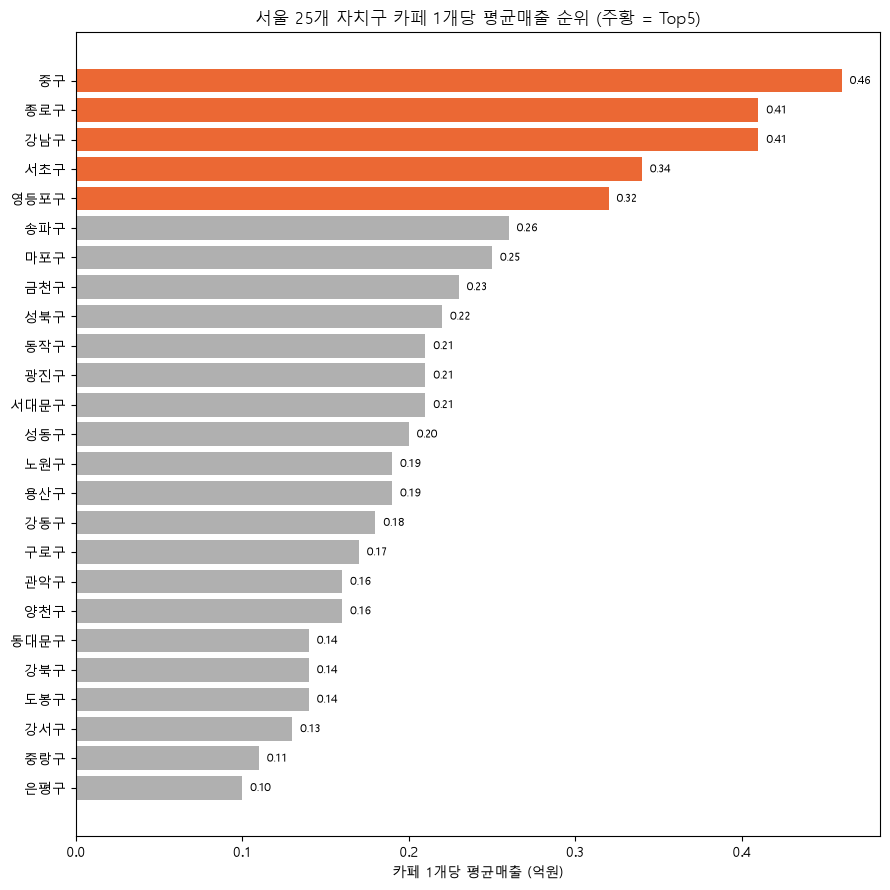

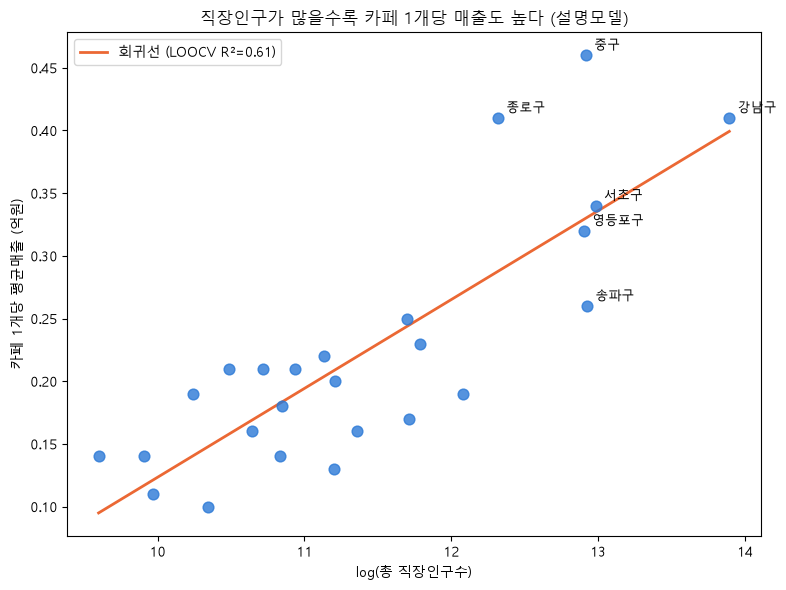

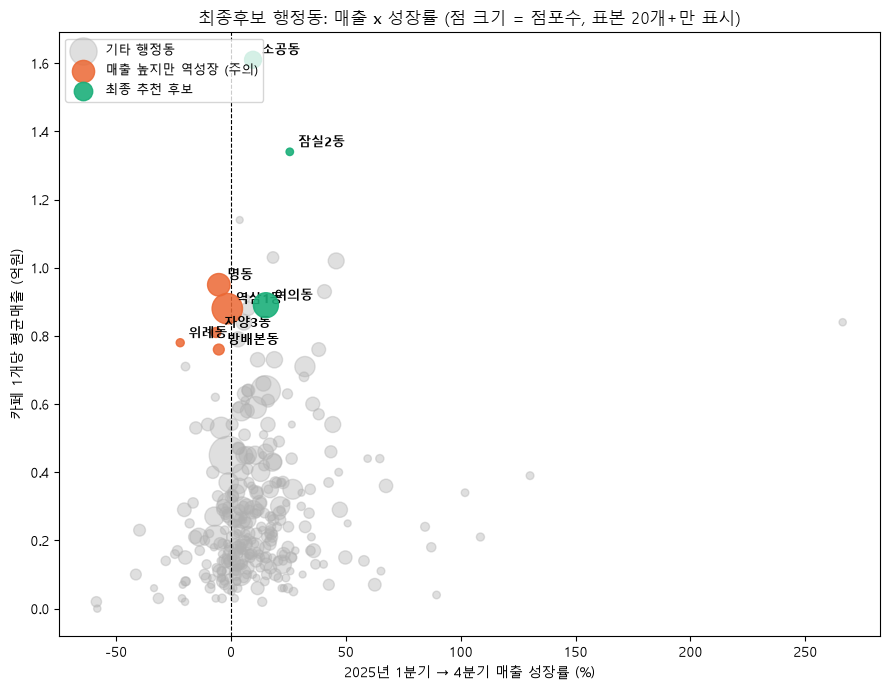

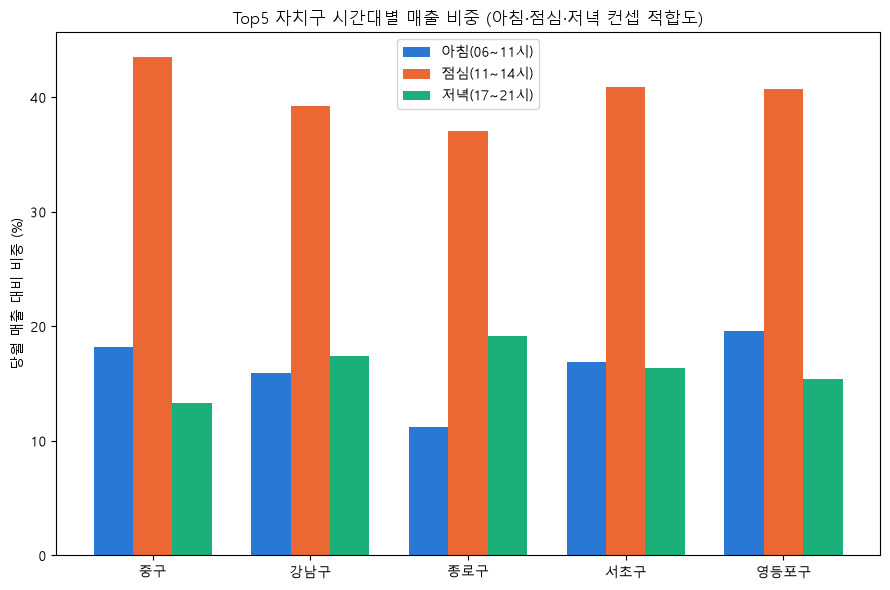

In [8]:
# ============================================================
# STEP 30. 서울 분석 결과 시각화
# ------------------------------------------------------------
# 지금까지 표(숫자)로만 봤던 4가지 핵심 결과를 그래프로 그립니다.
#   ① 자치구 25개 카페1개당 평균매출 순위 (Top5 강조)
#   ② 설명모델: log(직장인구) vs 카페1개당매출 (회귀선 포함)
#   ③ 최종후보 행정동: 성장률 x 매출 산점도 (추천 후보 강조)
#   ④ Top5 자치구 시간대별 매출 비중 (컨셉 적합도 근거)
#
# 27, 28, 29번에서 저장해둔 CSV들을 그대로 불러와서 그립니다.
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 0. 한글이 그래프에서 깨지지 않도록 폰트를 설정합니다. (윈도우는 보통 '맑은 고딕'이 있습니다)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False  # 마이너스(-) 기호가 깨지는 것도 방지

프로젝트_루트 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정"
그림_폴더 = 프로젝트_루트 + r"\reports\figures"
os.makedirs(그림_폴더, exist_ok=True)

# 색상 팔레트 (파랑=기본, 주황=강조, 아쿠아=보조, 회색=비강조)
파랑 = "#2a78d6"
주황 = "#eb6834"
아쿠아 = "#1baf7a"
회색 = "#b0b0b0"


# ============================================================
# ① 자치구 25개 카페1개당 평균매출 순위 (Top5 강조)
# ============================================================
최종순위표 = pd.read_csv(
    프로젝트_루트 + r"\data\processed\서울_최종순위표.csv", encoding="utf-8-sig"
)
순위정렬 = 최종순위표.sort_values("카페1개당_평균매출_억원", ascending=True)

Top5_자치구명 = {"중구", "강남구", "종로구", "서초구", "영등포구"}
막대색 = [주황 if 이름 in Top5_자치구명 else 회색 for 이름 in 순위정렬["자치구_코드_명"]]

fig1, ax1 = plt.subplots(figsize=(9, 9))
ax1.barh(순위정렬["자치구_코드_명"], 순위정렬["카페1개당_평균매출_억원"], color=막대색)
ax1.set_xlabel("카페 1개당 평균매출 (억원)")
ax1.set_title("서울 25개 자치구 카페 1개당 평균매출 순위 (주황 = Top5)")
for y, v in enumerate(순위정렬["카페1개당_평균매출_억원"]):
    ax1.text(v + 0.005, y, f"{v:.2f}", va="center", fontsize=8)
fig1.tight_layout()
fig1.savefig(그림_폴더 + r"\그림1_자치구_매출순위.png", dpi=150)
print("[그림1] 저장 완료 -> 자치구별 카페1개당 평균매출 순위")


# ============================================================
# ② 설명모델: log(직장인구) vs 카페1개당매출 (회귀선 포함)
# ============================================================
df = 최종순위표.copy()

fig2, ax2 = plt.subplots(figsize=(8, 6))
ax2.scatter(df["log_직장인구"], df["카페1개당_평균매출_억원"], color=파랑, s=60, alpha=0.8, zorder=3)

# 회귀선: 27번에서 만든 model 계수를 다시 이용 (여기서는 직접 재적합)
계수 = np.polyfit(df["log_직장인구"], df["카페1개당_평균매출_억원"], 1)
x선 = np.linspace(df["log_직장인구"].min(), df["log_직장인구"].max(), 100)
y선 = 계수[0] * x선 + 계수[1]
ax2.plot(x선, y선, color=주황, linewidth=2, label="회귀선 (LOOCV R²=0.61)", zorder=2)

# 라벨을 붙이면 25개 전부는 너무 복잡하니, 매출 상위 6곳만 이름 표시
라벨_대상 = df.sort_values("카페1개당_평균매출_억원", ascending=False).head(6)
for _, row in 라벨_대상.iterrows():
    ax2.annotate(
        row["자치구_코드_명"],
        (row["log_직장인구"], row["카페1개당_평균매출_억원"]),
        textcoords="offset points", xytext=(6, 4), fontsize=9,
    )

ax2.set_xlabel("log(총 직장인구수)")
ax2.set_ylabel("카페 1개당 평균매출 (억원)")
ax2.set_title("직장인구가 많을수록 카페 1개당 매출도 높다 (설명모델)")
ax2.legend()
fig2.tight_layout()
fig2.savefig(그림_폴더 + r"\그림2_직장인구_회귀모델.png", dpi=150)
print("[그림2] 저장 완료 -> log(직장인구) vs 카페1개당매출 회귀모델")


# ============================================================
# ③ 최종후보 행정동: 성장률 x 매출 산점도 (추천 후보 강조)
# ============================================================
최종후보 = pd.read_csv(
    프로젝트_루트 + r"\data\processed\서울_최종후보_행정동.csv", encoding="utf-8-sig"
)
안정_표본 = 최종후보[최종후보["점포_수"] >= 20].copy()

추천_후보 = ["소공동", "여의동", "잠실2동"]
주의_지역 = ["명동", "역삼1동", "대치1동", "자양3동", "위례동", "방배본동"]

기타 = 안정_표본[~안정_표본["행정동_코드_명"].isin(추천_후보 + 주의_지역)]
주의 = 안정_표본[안정_표본["행정동_코드_명"].isin(주의_지역)]
추천 = 안정_표본[안정_표본["행정동_코드_명"].isin(추천_후보)]

fig3, ax3 = plt.subplots(figsize=(9, 7))
ax3.scatter(
    기타["성장률"], 기타["카페1개당_평균매출_억원"],
    s=기타["점포_수"] * 1.2, color=회색, alpha=0.4, label="기타 행정동", zorder=2,
)
ax3.scatter(
    주의["성장률"], 주의["카페1개당_평균매출_억원"],
    s=주의["점포_수"] * 1.2, color=주황, alpha=0.85, label="매출 높지만 역성장 (주의)", zorder=3,
)
ax3.scatter(
    추천["성장률"], 추천["카페1개당_평균매출_억원"],
    s=추천["점포_수"] * 1.2, color=아쿠아, alpha=0.9, label="최종 추천 후보", zorder=4,
)

for _, row in pd.concat([추천, 주의]).iterrows():
    ax3.annotate(
        row["행정동_코드_명"],
        (row["성장률"], row["카페1개당_평균매출_억원"]),
        textcoords="offset points", xytext=(6, 4), fontsize=9, fontweight="bold",
    )

ax3.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax3.set_xlabel("2025년 1분기 → 4분기 매출 성장률 (%)")
ax3.set_ylabel("카페 1개당 평균매출 (억원)")
ax3.set_title("최종후보 행정동: 매출 x 성장률 (점 크기 = 점포수, 표본 20개+만 표시)")
ax3.legend(loc="upper left", fontsize=9)
fig3.tight_layout()
fig3.savefig(그림_폴더 + r"\그림3_최종후보_행정동.png", dpi=150)
print("[그림3] 저장 완료 -> 최종후보 행정동 성장률x매출 산점도")


# ============================================================
# ④ Top5 자치구 시간대별 매출 비중 (컨셉 적합도 근거)
# ============================================================
종합표 = pd.read_csv(
    프로젝트_루트 + r"\data\processed\서울_자치구_카페_종합표.csv", encoding="utf-8-sig"
)
Top5_순서 = ["중구", "강남구", "종로구", "서초구", "영등포구"]
Top5_df = 종합표[종합표["자치구_코드_명"].isin(Top5_순서)].set_index("자치구_코드_명").loc[Top5_순서]

x = np.arange(len(Top5_순서))
너비 = 0.25

fig4, ax4 = plt.subplots(figsize=(9, 6))
ax4.bar(x - 너비, Top5_df["아침_매출_비중"], 너비, label="아침(06~11시)", color=파랑)
ax4.bar(x, Top5_df["점심_매출_비중"], 너비, label="점심(11~14시)", color=주황)
ax4.bar(x + 너비, Top5_df["저녁_매출_비중"], 너비, label="저녁(17~21시)", color=아쿠아)

ax4.set_xticks(x)
ax4.set_xticklabels(Top5_순서)
ax4.set_ylabel("당월 매출 대비 비중 (%)")
ax4.set_title("Top5 자치구 시간대별 매출 비중 (아침·점심·저녁 컨셉 적합도)")
ax4.legend()
fig4.tight_layout()
fig4.savefig(그림_폴더 + r"\그림4_Top5_시간대별_매출비중.png", dpi=150)
print("[그림4] 저장 완료 -> Top5 자치구 시간대별 매출 비중")

print("\n그림 4개 모두 저장 완료 ->", 그림_폴더)
plt.show()

[그림1] 저장 완료 -> 자치구별 카페1개당 평균매출 순위
[그림2] 저장 완료 -> log(직장인구) vs 카페1개당매출 회귀모델
[그림3] 저장 완료 -> 최종후보 행정동 성장률x매출 산점도
[그림4] 저장 완료 -> Top5 자치구 시간대별 매출 비중
[그림5] 저장 완료 -> 후보 변수 간 상관관계 히트맵
[그림6] 저장 완료 -> 최종후보 Top10 행정동 히트맵 테이블
[그림7] 저장 완료 -> 최종 추천 3곳 스펙 비교

그림 7개 모두 저장 완료 -> C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\reports\figures


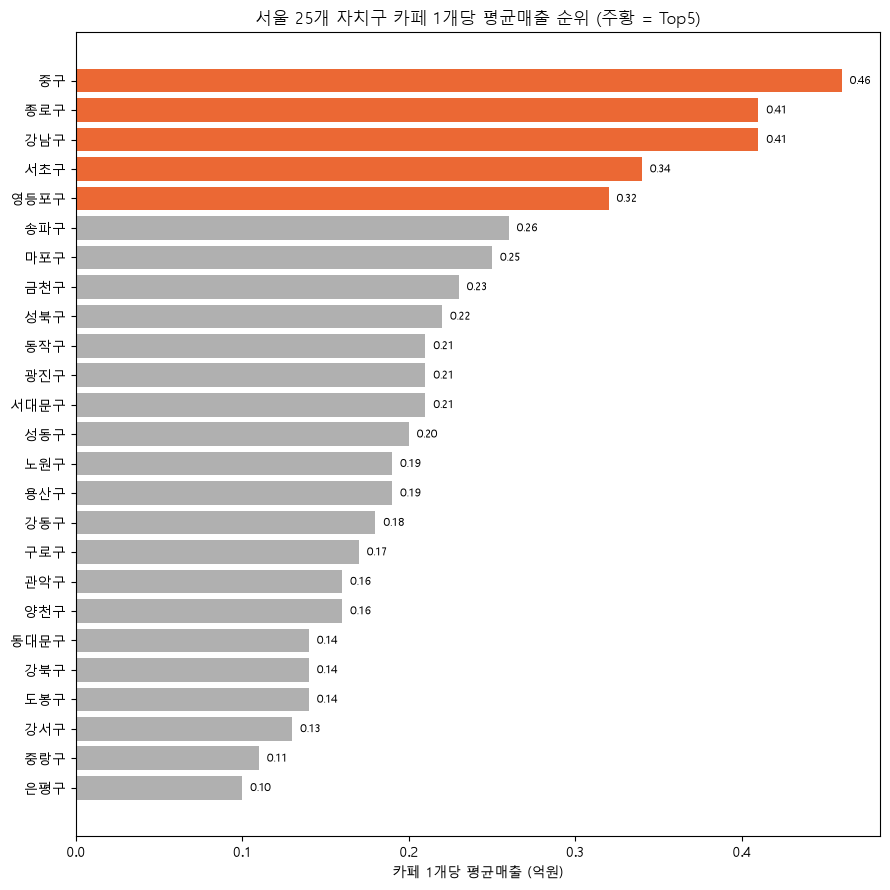

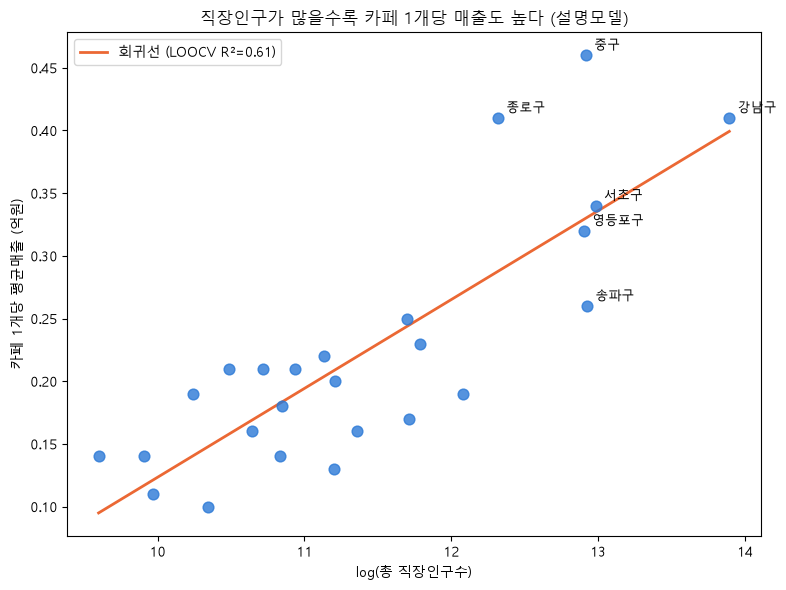

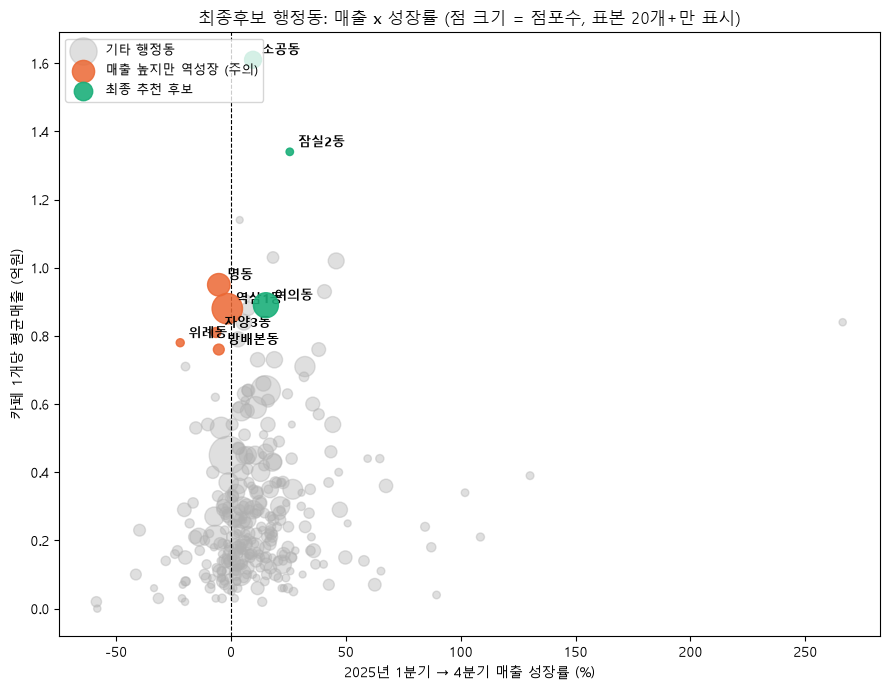

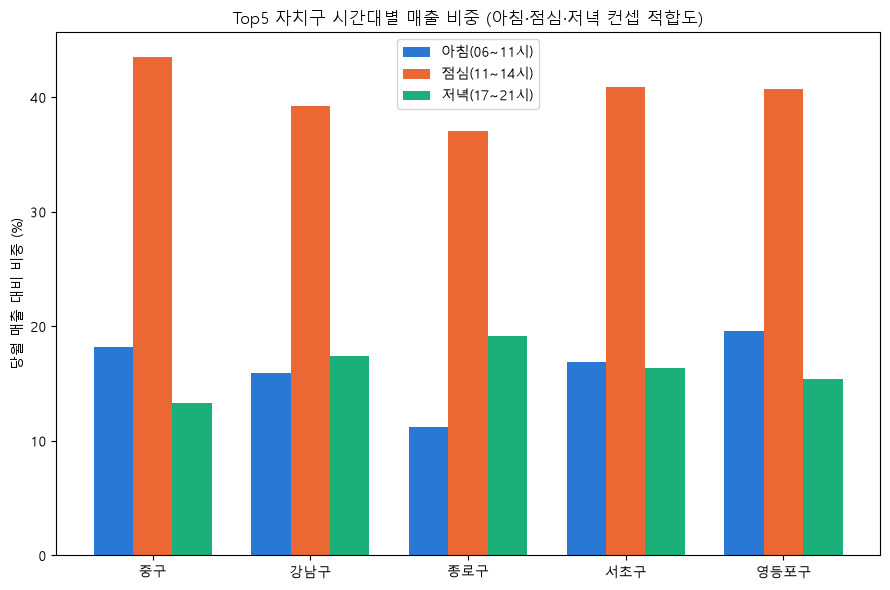

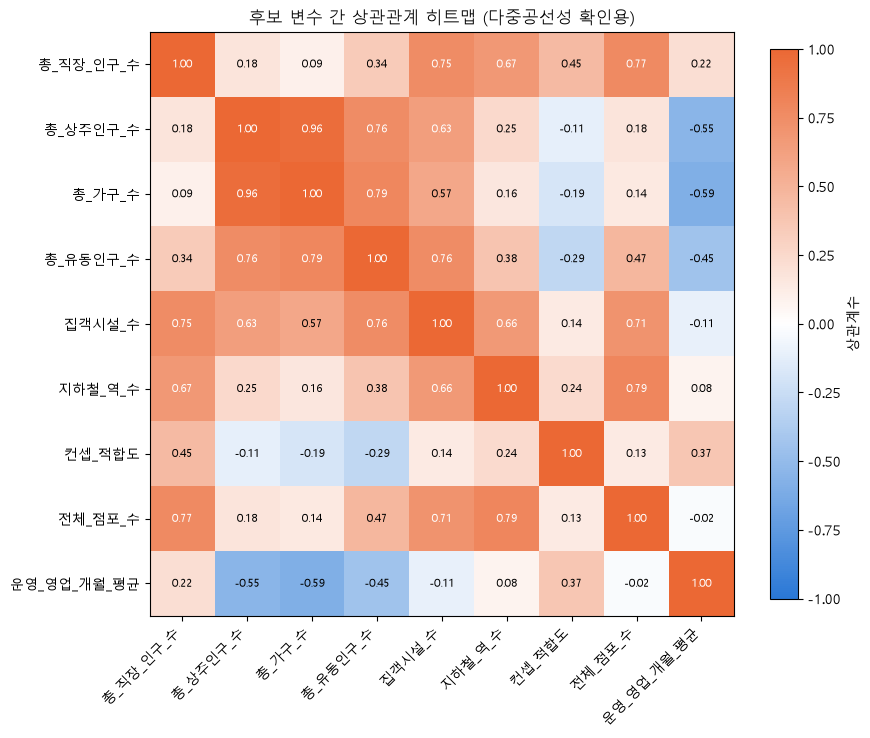

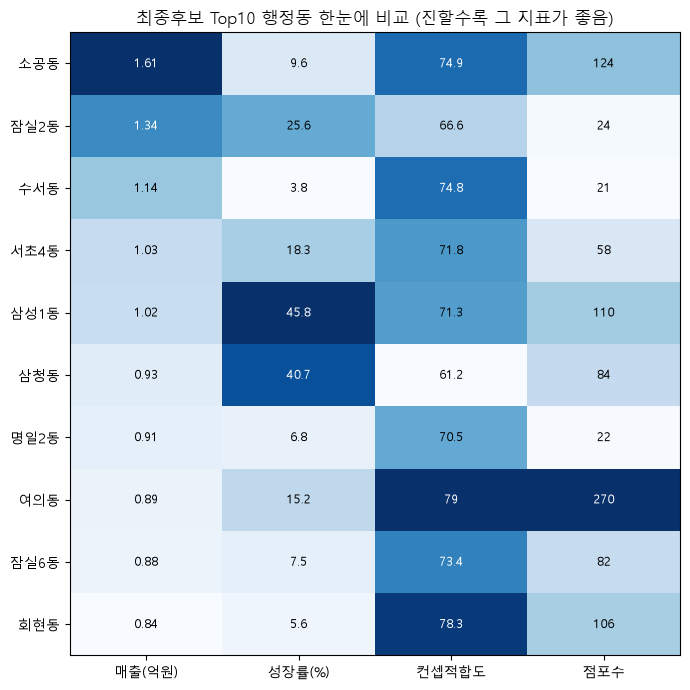

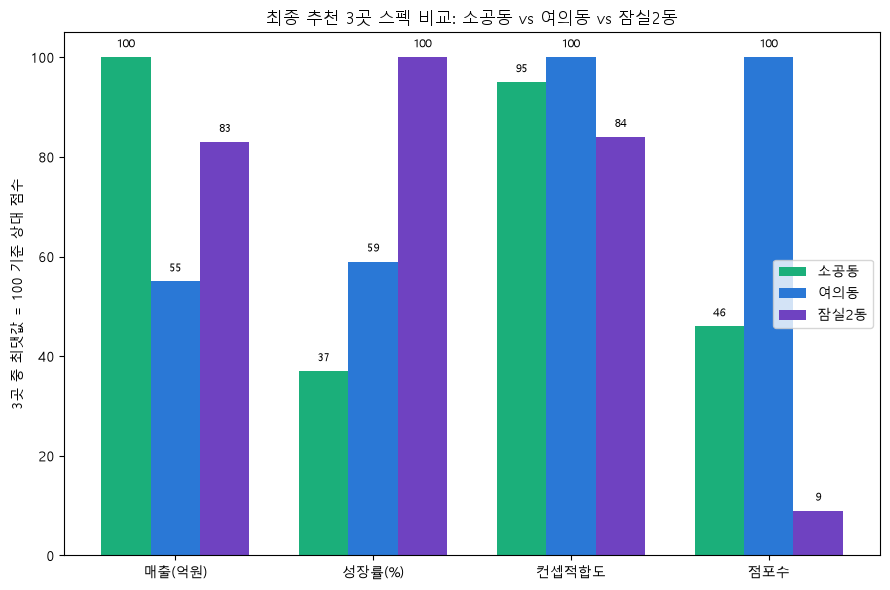

In [9]:
# ============================================================
# STEP 30. 서울 분석 결과 시각화
# ------------------------------------------------------------
# 지금까지 표(숫자)로만 봤던 4가지 핵심 결과를 그래프로 그립니다.
#   ① 자치구 25개 카페1개당 평균매출 순위 (Top5 강조)
#   ② 설명모델: log(직장인구) vs 카페1개당매출 (회귀선 포함)
#   ③ 최종후보 행정동: 성장률 x 매출 산점도 (추천 후보 강조)
#   ④ Top5 자치구 시간대별 매출 비중 (컨셉 적합도 근거)
#
# 27, 28, 29번에서 저장해둔 CSV들을 그대로 불러와서 그립니다.
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 0. 한글이 그래프에서 깨지지 않도록 폰트를 설정합니다. (윈도우는 보통 '맑은 고딕'이 있습니다)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False  # 마이너스(-) 기호가 깨지는 것도 방지

프로젝트_루트 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정"
그림_폴더 = 프로젝트_루트 + r"\reports\figures"
os.makedirs(그림_폴더, exist_ok=True)

# 색상 팔레트 (파랑=기본, 주황=강조, 아쿠아=보조, 회색=비강조)
파랑 = "#2a78d6"
주황 = "#eb6834"
아쿠아 = "#1baf7a"
회색 = "#b0b0b0"


# ============================================================
# ① 자치구 25개 카페1개당 평균매출 순위 (Top5 강조)
# ============================================================
최종순위표 = pd.read_csv(
    프로젝트_루트 + r"\data\processed\서울_최종순위표.csv", encoding="utf-8-sig"
)
순위정렬 = 최종순위표.sort_values("카페1개당_평균매출_억원", ascending=True)

Top5_자치구명 = {"중구", "강남구", "종로구", "서초구", "영등포구"}
막대색 = [주황 if 이름 in Top5_자치구명 else 회색 for 이름 in 순위정렬["자치구_코드_명"]]

fig1, ax1 = plt.subplots(figsize=(9, 9))
ax1.barh(순위정렬["자치구_코드_명"], 순위정렬["카페1개당_평균매출_억원"], color=막대색)
ax1.set_xlabel("카페 1개당 평균매출 (억원)")
ax1.set_title("서울 25개 자치구 카페 1개당 평균매출 순위 (주황 = Top5)")
for y, v in enumerate(순위정렬["카페1개당_평균매출_억원"]):
    ax1.text(v + 0.005, y, f"{v:.2f}", va="center", fontsize=8)
fig1.tight_layout()
fig1.savefig(그림_폴더 + r"\그림1_자치구_매출순위.png", dpi=150)
print("[그림1] 저장 완료 -> 자치구별 카페1개당 평균매출 순위")


# ============================================================
# ② 설명모델: log(직장인구) vs 카페1개당매출 (회귀선 포함)
# ============================================================
df = 최종순위표.copy()

fig2, ax2 = plt.subplots(figsize=(8, 6))
ax2.scatter(df["log_직장인구"], df["카페1개당_평균매출_억원"], color=파랑, s=60, alpha=0.8, zorder=3)

# 회귀선: 27번에서 만든 model 계수를 다시 이용 (여기서는 직접 재적합)
계수 = np.polyfit(df["log_직장인구"], df["카페1개당_평균매출_억원"], 1)
x선 = np.linspace(df["log_직장인구"].min(), df["log_직장인구"].max(), 100)
y선 = 계수[0] * x선 + 계수[1]
ax2.plot(x선, y선, color=주황, linewidth=2, label="회귀선 (LOOCV R²=0.61)", zorder=2)

# 라벨을 붙이면 25개 전부는 너무 복잡하니, 매출 상위 6곳만 이름 표시
라벨_대상 = df.sort_values("카페1개당_평균매출_억원", ascending=False).head(6)
for _, row in 라벨_대상.iterrows():
    ax2.annotate(
        row["자치구_코드_명"],
        (row["log_직장인구"], row["카페1개당_평균매출_억원"]),
        textcoords="offset points", xytext=(6, 4), fontsize=9,
    )

ax2.set_xlabel("log(총 직장인구수)")
ax2.set_ylabel("카페 1개당 평균매출 (억원)")
ax2.set_title("직장인구가 많을수록 카페 1개당 매출도 높다 (설명모델)")
ax2.legend()
fig2.tight_layout()
fig2.savefig(그림_폴더 + r"\그림2_직장인구_회귀모델.png", dpi=150)
print("[그림2] 저장 완료 -> log(직장인구) vs 카페1개당매출 회귀모델")


# ============================================================
# ③ 최종후보 행정동: 성장률 x 매출 산점도 (추천 후보 강조)
# ============================================================
최종후보 = pd.read_csv(
    프로젝트_루트 + r"\data\processed\서울_최종후보_행정동.csv", encoding="utf-8-sig"
)
안정_표본 = 최종후보[최종후보["점포_수"] >= 20].copy()

추천_후보 = ["소공동", "여의동", "잠실2동"]
주의_지역 = ["명동", "역삼1동", "대치1동", "자양3동", "위례동", "방배본동"]

기타 = 안정_표본[~안정_표본["행정동_코드_명"].isin(추천_후보 + 주의_지역)]
주의 = 안정_표본[안정_표본["행정동_코드_명"].isin(주의_지역)]
추천 = 안정_표본[안정_표본["행정동_코드_명"].isin(추천_후보)]

fig3, ax3 = plt.subplots(figsize=(9, 7))
ax3.scatter(
    기타["성장률"], 기타["카페1개당_평균매출_억원"],
    s=기타["점포_수"] * 1.2, color=회색, alpha=0.4, label="기타 행정동", zorder=2,
)
ax3.scatter(
    주의["성장률"], 주의["카페1개당_평균매출_억원"],
    s=주의["점포_수"] * 1.2, color=주황, alpha=0.85, label="매출 높지만 역성장 (주의)", zorder=3,
)
ax3.scatter(
    추천["성장률"], 추천["카페1개당_평균매출_억원"],
    s=추천["점포_수"] * 1.2, color=아쿠아, alpha=0.9, label="최종 추천 후보", zorder=4,
)

for _, row in pd.concat([추천, 주의]).iterrows():
    ax3.annotate(
        row["행정동_코드_명"],
        (row["성장률"], row["카페1개당_평균매출_억원"]),
        textcoords="offset points", xytext=(6, 4), fontsize=9, fontweight="bold",
    )

ax3.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax3.set_xlabel("2025년 1분기 → 4분기 매출 성장률 (%)")
ax3.set_ylabel("카페 1개당 평균매출 (억원)")
ax3.set_title("최종후보 행정동: 매출 x 성장률 (점 크기 = 점포수, 표본 20개+만 표시)")
ax3.legend(loc="upper left", fontsize=9)
fig3.tight_layout()
fig3.savefig(그림_폴더 + r"\그림3_최종후보_행정동.png", dpi=150)
print("[그림3] 저장 완료 -> 최종후보 행정동 성장률x매출 산점도")


# ============================================================
# ④ Top5 자치구 시간대별 매출 비중 (컨셉 적합도 근거)
# ============================================================
종합표 = pd.read_csv(
    프로젝트_루트 + r"\data\processed\서울_자치구_카페_종합표.csv", encoding="utf-8-sig"
)
Top5_순서 = ["중구", "강남구", "종로구", "서초구", "영등포구"]
Top5_df = 종합표[종합표["자치구_코드_명"].isin(Top5_순서)].set_index("자치구_코드_명").loc[Top5_순서]

x = np.arange(len(Top5_순서))
너비 = 0.25

fig4, ax4 = plt.subplots(figsize=(9, 6))
ax4.bar(x - 너비, Top5_df["아침_매출_비중"], 너비, label="아침(06~11시)", color=파랑)
ax4.bar(x, Top5_df["점심_매출_비중"], 너비, label="점심(11~14시)", color=주황)
ax4.bar(x + 너비, Top5_df["저녁_매출_비중"], 너비, label="저녁(17~21시)", color=아쿠아)

ax4.set_xticks(x)
ax4.set_xticklabels(Top5_순서)
ax4.set_ylabel("당월 매출 대비 비중 (%)")
ax4.set_title("Top5 자치구 시간대별 매출 비중 (아침·점심·저녁 컨셉 적합도)")
ax4.legend()
fig4.tight_layout()
fig4.savefig(그림_폴더 + r"\그림4_Top5_시간대별_매출비중.png", dpi=150)
print("[그림4] 저장 완료 -> Top5 자치구 시간대별 매출 비중")

# ============================================================
# ⑤ 후보 변수 간 상관관계 히트맵 (다중공선성 확인)
# ============================================================
# 파랑(음의 상관) - 흰색(무관) - 주황(양의 상관) 두 색상 그라데이션을 직접 만듭니다.
from matplotlib.colors import LinearSegmentedColormap
파랑주황_diverging = LinearSegmentedColormap.from_list(
    "파랑주황", [파랑, "#ffffff", 주황]
)

후보_변수 = [
    "총_직장_인구_수", "총_상주인구_수", "총_가구_수", "총_유동인구_수",
    "집객시설_수", "지하철_역_수", "컨셉_적합도", "전체_점포_수", "운영_영업_개월_평균",
]
상관행렬 = 종합표[후보_변수].corr()

fig5, ax5 = plt.subplots(figsize=(9, 8))
im = ax5.imshow(상관행렬.values, cmap=파랑주황_diverging, vmin=-1, vmax=1)
ax5.set_xticks(range(len(후보_변수)))
ax5.set_yticks(range(len(후보_변수)))
ax5.set_xticklabels(후보_변수, rotation=45, ha="right")
ax5.set_yticklabels(후보_변수)
for i in range(len(후보_변수)):
    for j in range(len(후보_변수)):
        값 = 상관행렬.values[i, j]
        글자색 = "white" if abs(값) > 0.6 else "black"
        ax5.text(j, i, f"{값:.2f}", ha="center", va="center", fontsize=8, color=글자색)
ax5.set_title("후보 변수 간 상관관계 히트맵 (다중공선성 확인용)")
fig5.colorbar(im, ax=ax5, shrink=0.8, label="상관계수")
fig5.tight_layout()
fig5.savefig(그림_폴더 + r"\그림5_변수_상관관계_히트맵.png", dpi=150)
print("[그림5] 저장 완료 -> 후보 변수 간 상관관계 히트맵")


# ============================================================
# ⑥ 최종후보 Top10 행정동 히트맵 테이블 (한눈에 비교)
# ============================================================
# ③에서 이미 만들어 둔 안정_표본(점포수 20개+)을 그대로 재사용합니다.
Top20 = 안정_표본.sort_values("카페1개당_평균매출_억원", ascending=False).head(20)
최종후보_역성장제외 = Top20[Top20["성장률"] >= 0].sort_values("카페1개당_평균매출_억원", ascending=False)
Top10_표 = 최종후보_역성장제외.head(10).set_index("행정동_코드_명")

지표들 = ["카페1개당_평균매출_억원", "성장률", "컨셉_적합도", "점포_수"]
지표_한글 = ["매출(억원)", "성장률(%)", "컨셉적합도", "점포수"]

# 열(지표)마다 따로 0~1로 정규화해서 색으로 표현 (실제 값은 숫자로 함께 표시)
정규화행렬 = Top10_표[지표들].apply(lambda col: (col - col.min()) / (col.max() - col.min() + 1e-9))

fig6, ax6 = plt.subplots(figsize=(7, 7))
im6 = ax6.imshow(정규화행렬.values, cmap="Blues", vmin=0, vmax=1, aspect="auto")
ax6.set_xticks(range(len(지표들)))
ax6.set_xticklabels(지표_한글)
ax6.set_yticks(range(len(Top10_표)))
ax6.set_yticklabels(Top10_표.index)
for i in range(len(Top10_표)):
    for j, col in enumerate(지표들):
        값 = Top10_표[col].iloc[i]
        정규값 = 정규화행렬[col].iloc[i]
        글자색 = "white" if 정규값 > 0.6 else "black"
        ax6.text(j, i, f"{값:g}", ha="center", va="center", fontsize=9, color=글자색)
ax6.set_title("최종후보 Top10 행정동 한눈에 비교 (진할수록 그 지표가 좋음)")
fig6.tight_layout()
fig6.savefig(그림_폴더 + r"\그림6_Top10후보_히트맵테이블.png", dpi=150)
print("[그림6] 저장 완료 -> 최종후보 Top10 행정동 히트맵 테이블")


# ============================================================
# ⑦ 최종 추천 3곳 스펙 비교 (소공동 vs 여의동 vs 잠실2동)
# ============================================================
비교_대상 = ["소공동", "여의동", "잠실2동"]
비교_df = 안정_표본[안정_표본["행정동_코드_명"].isin(비교_대상)].set_index("행정동_코드_명").loc[비교_대상]

지표들2 = ["카페1개당_평균매출_억원", "성장률", "컨셉_적합도", "점포_수"]
지표_한글2 = ["매출(억원)", "성장률(%)", "컨셉적합도", "점포수"]

# 지표마다 스케일이 달라서, 3곳 중 최댓값을 100으로 맞춰 비교합니다 (레이더 대신 막대로 표현).
비교_정규화 = 비교_df[지표들2].apply(lambda col: (col / col.max() * 100).round(0))

x = np.arange(len(지표들2))
너비 = 0.25
색상_3곳 = [아쿠아, 파랑, "#6f42c1"]  # 소공동, 여의동, 잠실2동

fig7, ax7 = plt.subplots(figsize=(9, 6))
for i, 지역 in enumerate(비교_대상):
    ax7.bar(x + (i - 1) * 너비, 비교_정규화.loc[지역], 너비, label=지역, color=색상_3곳[i])
    for xi, 값 in zip(x + (i - 1) * 너비, 비교_정규화.loc[지역]):
        ax7.text(xi, 값 + 2, f"{값:.0f}", ha="center", fontsize=8)

ax7.set_xticks(x)
ax7.set_xticklabels(지표_한글2)
ax7.set_ylabel("3곳 중 최댓값 = 100 기준 상대 점수")
ax7.set_title("최종 추천 3곳 스펙 비교: 소공동 vs 여의동 vs 잠실2동")
ax7.legend()
fig7.tight_layout()
fig7.savefig(그림_폴더 + r"\그림7_추천3곳_스펙비교.png", dpi=150)
print("[그림7] 저장 완료 -> 최종 추천 3곳 스펙 비교")


print("\n그림 7개 모두 저장 완료 ->", 그림_폴더)
plt.show()

=== 데이터 품질 체크 (서울_자치구_카페_종합표, 25개 자치구) ===
결측치 없음 (25개 자치구 전부 데이터 완비)

=== 핵심 변수 기초통계 ===
       카페1개당_평균매출_억원  총_직장_인구_수  총_상주인구_수     총_유동인구_수  전체_점포_수  컨셉_적합도
count           25.0       25.0      25.0         25.0     25.0    25.0
mean             0.2   168103.3  374416.8   91754403.3   1093.3    69.6
std              0.1   233512.0  126842.4   25493159.9    522.0     3.8
min              0.1    14740.0  120961.0   34978174.0    432.0    63.0
25%              0.2    41999.0  305725.0   75372551.0    750.0    66.8
50%              0.2    73335.0  377821.0   93507216.0    931.0    69.4
75%              0.2   176024.0  456800.0  107551419.0   1367.0    71.9
max              0.5  1079924.0  653369.0  145387600.0   2561.0    78.3

[그림8] 저장 완료 -> 주요 변수 6개 분포 히스토그램
[그림9] 저장 완료 -> 서울시 전체 카페 매출 시계열 (21개 분기)
[그림10] 저장 완료 -> Top5 자치구별 매출 시계열 비교
[그림11] 저장 완료 -> 카페1개당 평균매출 박스플롯

EDA 그림 4개 모두 저장 완료 -> C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\reports\figures


C:\Users\seokho\AppData\Local\Temp\ipykernel_13924\2076837599.py:139: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax4.boxplot(


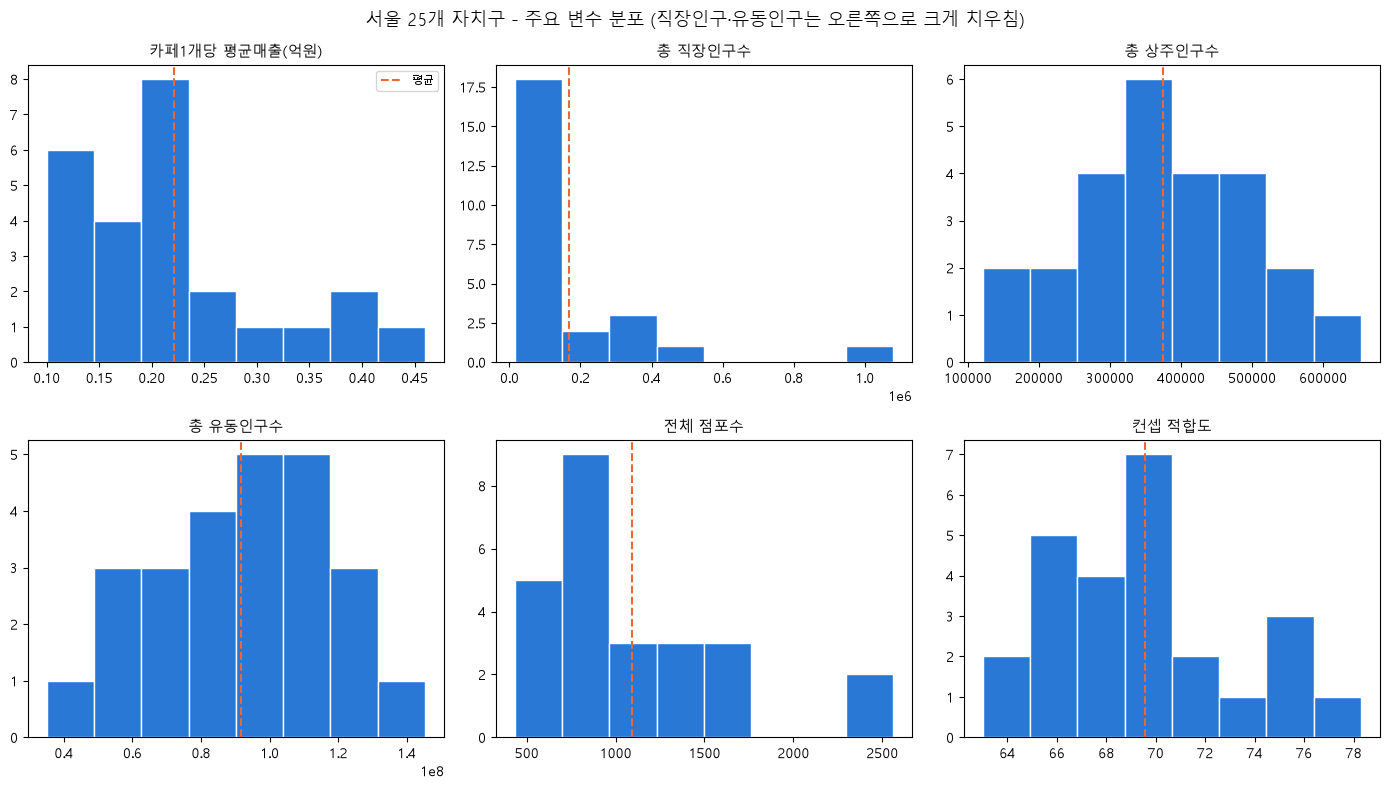

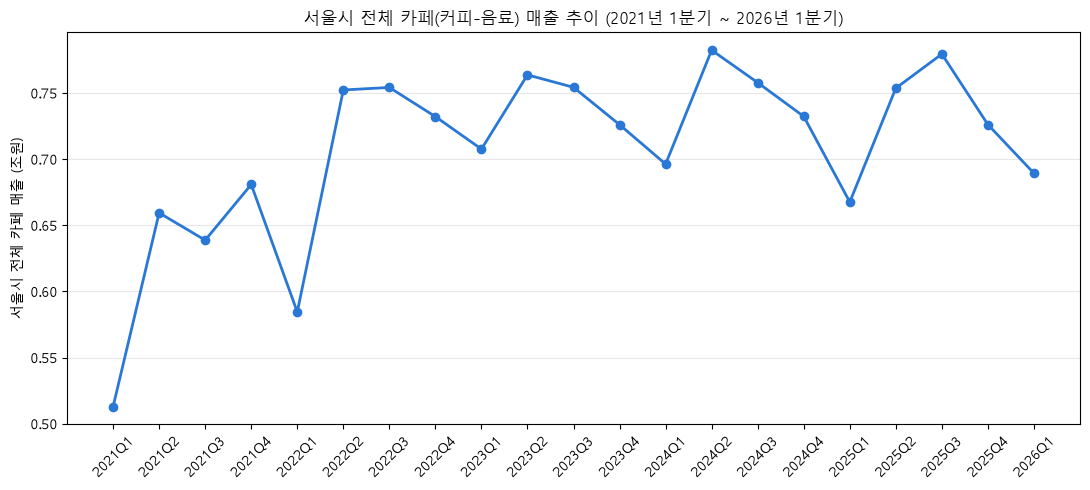

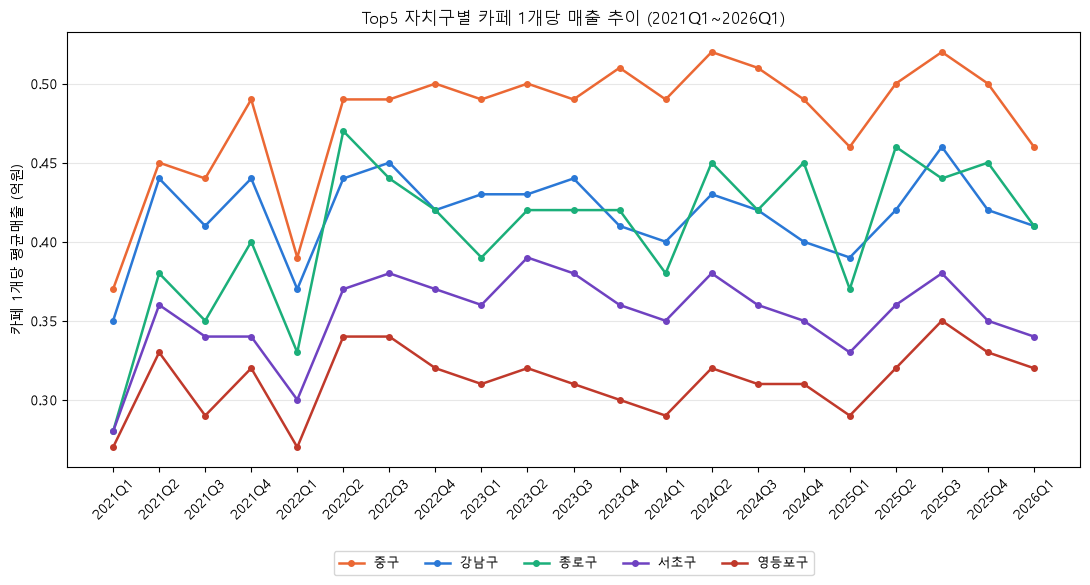

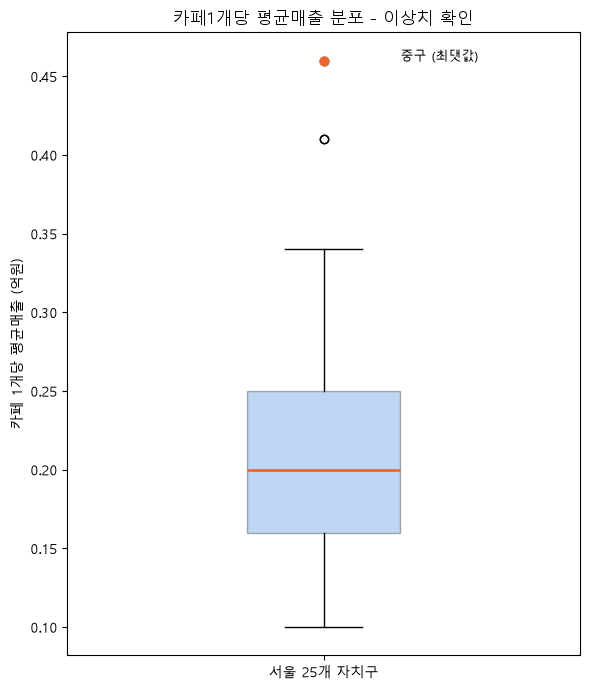

In [10]:
# ============================================================
# STEP 31. 서울 원본 데이터 탐색(EDA) 시각화
# ------------------------------------------------------------
# 30번은 "결과·모델링" 시각화(순위, 회귀선, 최종후보)였다면,
# 이 스크립트는 모델링 이전 단계 - 원본 데이터 자체를 탐색하는 EDA입니다.
#   ① 데이터 품질 체크 (결측치·기초통계, 콘솔 출력)
#   ② 주요 변수 6개 분포 히스토그램 (왜 로그 변환이 필요했는지 시각적 근거)
#   ③ 서울시 전체 카페 매출 시계열 (2021Q1~2026Q1, 21개 분기)
#   ④ Top5 자치구별 매출 시계열 비교
#   ⑤ 카페1개당 평균매출 박스플롯 (이상치 확인)
# ============================================================

import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

프로젝트_루트 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정"
데이터_폴더 = 프로젝트_루트 + r"\[유통] 서울시 골목상권분석정보"
그림_폴더 = 프로젝트_루트 + r"\reports\figures"
os.makedirs(그림_폴더, exist_ok=True)
카페_코드 = "CS100010"

파랑 = "#2a78d6"
주황 = "#eb6834"
아쿠아 = "#1baf7a"
회색 = "#b0b0b0"


def zip_csv_읽기(zip_파일명, csv_파일명):
    경로 = 데이터_폴더 + "\\" + zip_파일명
    with zipfile.ZipFile(경로) as zf:
        with zf.open(csv_파일명) as f:
            return pd.read_csv(f, encoding="cp949")


# ============================================================
# ① 데이터 품질 체크 - 결측치, 기초통계 (콘솔 출력)
# ============================================================
종합표 = pd.read_csv(
    프로젝트_루트 + r"\data\processed\서울_자치구_카페_종합표.csv", encoding="utf-8-sig"
)

print("=== 데이터 품질 체크 (서울_자치구_카페_종합표, 25개 자치구) ===")
결측치_수 = 종합표.isna().sum()
결측치_있는_컬럼 = 결측치_수[결측치_수 > 0]
if len(결측치_있는_컬럼) == 0:
    print("결측치 없음 (25개 자치구 전부 데이터 완비)")
else:
    print("결측치 발견:\n", 결측치_있는_컬럼)

핵심_변수 = ["카페1개당_평균매출_억원", "총_직장_인구_수", "총_상주인구_수", "총_유동인구_수", "전체_점포_수", "컨셉_적합도"]
print("\n=== 핵심 변수 기초통계 ===")
print(종합표[핵심_변수].describe().round(1))


# ============================================================
# ② 주요 변수 6개 분포 히스토그램
# ============================================================
fig1, axes = plt.subplots(2, 3, figsize=(14, 8))
제목_목록 = ["카페1개당 평균매출(억원)", "총 직장인구수", "총 상주인구수", "총 유동인구수", "전체 점포수", "컨셉 적합도"]

for ax, 변수, 제목 in zip(axes.flat, 핵심_변수, 제목_목록):
    ax.hist(종합표[변수], bins=8, color=파랑, edgecolor="white")
    ax.set_title(제목, fontsize=11)
    ax.axvline(종합표[변수].mean(), color=주황, linestyle="--", linewidth=1.5, label="평균")

axes.flat[0].legend(fontsize=8)
fig1.suptitle("서울 25개 자치구 - 주요 변수 분포 (직장인구·유동인구는 오른쪽으로 크게 치우침)", fontsize=13)
fig1.tight_layout()
fig1.savefig(그림_폴더 + r"\그림8_주요변수_분포히스토그램.png", dpi=150)
print("\n[그림8] 저장 완료 -> 주요 변수 6개 분포 히스토그램")


# ============================================================
# ③ 서울시 전체 카페 매출 시계열 (2021Q1~2026Q1)
# ============================================================
서울시매출 = pd.read_csv(데이터_폴더 + r"\서울시 상권분석서비스(추정매출-서울시).csv", encoding="cp949")
서울시카페 = 서울시매출[서울시매출["서비스_업종_코드"] == 카페_코드].sort_values("기준_년분기_코드")
분기_라벨 = 서울시카페["기준_년분기_코드"].astype(str).str[:4] + "Q" + 서울시카페["기준_년분기_코드"].astype(str).str[4:]
매출_조원 = 서울시카페["당월_매출_금액"] / 1_0000_0000_0000  # 조원 단위

fig2, ax2 = plt.subplots(figsize=(11, 5))
ax2.plot(분기_라벨, 매출_조원, marker="o", color=파랑, linewidth=2)
ax2.set_ylabel("서울시 전체 카페 매출 (조원)")
ax2.set_title("서울시 전체 카페(커피-음료) 매출 추이 (2021년 1분기 ~ 2026년 1분기)")
ax2.tick_params(axis="x", rotation=45)
ax2.grid(axis="y", color=회색, alpha=0.3)
fig2.tight_layout()
fig2.savefig(그림_폴더 + r"\그림9_서울시_전체매출_시계열.png", dpi=150)
print("[그림9] 저장 완료 -> 서울시 전체 카페 매출 시계열 (21개 분기)")


# ============================================================
# ④ Top5 자치구별 매출 시계열 비교
# ============================================================
Top5_순서 = ["중구", "강남구", "종로구", "서초구", "영등포구"]
Top5_색상 = [주황, 파랑, 아쿠아, "#6f42c1", "#c0392b"]

자치구매출_전체 = pd.read_csv(데이터_폴더 + r"\서울시 상권분석서비스(추정매출-자치구).csv", encoding="cp949")
자치구점포_전체 = pd.read_csv(데이터_폴더 + r"\서울시 상권분석서비스(점포-자치구).csv", encoding="cp949")

자치구카페매출 = 자치구매출_전체[
    (자치구매출_전체["서비스_업종_코드"] == 카페_코드) & (자치구매출_전체["자치구_코드_명"].isin(Top5_순서))
]
자치구카페점포 = 자치구점포_전체[
    (자치구점포_전체["서비스_업종_코드"] == 카페_코드) & (자치구점포_전체["자치구_코드_명"].isin(Top5_순서))
][["자치구_코드", "기준_년분기_코드", "전체_점포_수"]]

병합 = 자치구카페매출.merge(자치구카페점포, on=["자치구_코드", "기준_년분기_코드"])
병합["카페1개당매출_억원"] = (병합["당월_매출_금액"] / 병합["전체_점포_수"] / 1_0000_0000).round(2)

fig3, ax3 = plt.subplots(figsize=(11, 6))
분기_전체 = sorted(병합["기준_년분기_코드"].unique())
분기_라벨_전체 = [str(q)[:4] + "Q" + str(q)[4:] for q in 분기_전체]

for 자치구, 색 in zip(Top5_순서, Top5_색상):
    sub = 병합[병합["자치구_코드_명"] == 자치구].sort_values("기준_년분기_코드")
    ax3.plot(분기_라벨_전체, sub["카페1개당매출_억원"], marker="o", markersize=4, label=자치구, color=색, linewidth=1.8)

ax3.set_ylabel("카페 1개당 평균매출 (억원)")
ax3.set_title("Top5 자치구별 카페 1개당 매출 추이 (2021Q1~2026Q1)")
ax3.tick_params(axis="x", rotation=45)
ax3.legend(ncol=5, fontsize=9, loc="upper center", bbox_to_anchor=(0.5, -0.18))
ax3.grid(axis="y", color=회색, alpha=0.3)
fig3.tight_layout()
fig3.savefig(그림_폴더 + r"\그림10_Top5_자치구_매출추이비교.png", dpi=150)
print("[그림10] 저장 완료 -> Top5 자치구별 매출 시계열 비교")


# ============================================================
# ⑤ 카페1개당 평균매출 박스플롯 (이상치 확인)
# ============================================================
fig4, ax4 = plt.subplots(figsize=(6, 7))
bp = ax4.boxplot(
    종합표["카페1개당_평균매출_억원"], vert=True, widths=0.3,
    patch_artist=True, boxprops=dict(facecolor=파랑, alpha=0.3),
    medianprops=dict(color=주황, linewidth=2),
)

# 중구(최댓값)를 이상치 여부와 무관하게 참고용으로 라벨 표시
중구_값 = 종합표.loc[종합표["자치구_코드_명"] == "중구", "카페1개당_평균매출_억원"].values[0]
ax4.annotate("중구 (최댓값)", xy=(1, 중구_값), xytext=(1.15, 중구_값), fontsize=9)
ax4.scatter([1], [중구_값], color=주황, zorder=5, s=40)

ax4.set_ylabel("카페 1개당 평균매출 (억원)")
ax4.set_xticks([1])
ax4.set_xticklabels(["서울 25개 자치구"])
ax4.set_title("카페1개당 평균매출 분포 - 이상치 확인")
fig4.tight_layout()
fig4.savefig(그림_폴더 + r"\그림11_매출_박스플롯_이상치확인.png", dpi=150)
print("[그림11] 저장 완료 -> 카페1개당 평균매출 박스플롯")

print("\nEDA 그림 4개 모두 저장 완료 ->", 그림_폴더)
plt.show()

In [12]:
# ============================================================
# STEP 32. 지금 쓰고 있는 데이터들의 전체 컬럼 확인하기
# ------------------------------------------------------------
# 원본 데이터(서울시 골목상권분석정보) 7종 + 우리가 만든 가공 테이블 5개의
# 컬럼을 전부 직접 불러와서 눈으로 확인합니다.
# ============================================================

import zipfile
import pandas as pd

프로젝트_루트 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정"
데이터_폴더 = 프로젝트_루트 + r"\[유통] 서울시 골목상권분석정보"


def 컬럼_확인(제목, df):
    print(f"=== {제목} ({len(df.columns)}개 컬럼) ===")
    print(list(df.columns))
    print()


def zip_csv_읽기(zip_파일명, csv_파일명):
    경로 = 데이터_폴더 + "\\" + zip_파일명
    with zipfile.ZipFile(경로) as zf:
        with zf.open(csv_파일명) as f:
            return pd.read_csv(f, encoding="cp949", nrows=5)


# ============================================================
# 1. 원본 데이터 (자치구 단위) - cp949 인코딩
# ============================================================
원본_자치구_파일들 = {
    "추정매출-자치구": "서울시 상권분석서비스(추정매출-자치구).csv",
    "점포-자치구": "서울시 상권분석서비스(점포-자치구).csv",
    "상권변화지표-자치구": "서울시 상권분석서비스(상권변화지표-자치구).csv",
    "직장인구-자치구": "서울시 상권분석서비스(직장인구-자치구).csv",
    "상주인구-자치구": "서울시 상권분석서비스(상주인구-자치구).csv",
    "길단위인구-자치구": "서울시 상권분석서비스(길단위인구-자치구).csv",
    "집객시설-자치구": "서울시 상권분석서비스(집객시설-자치구).csv",
}

print("########## 1. 원본 데이터 (자치구 단위) ##########\n")
for 이름, 파일명 in 원본_자치구_파일들.items():
    df = pd.read_csv(데이터_폴더 + "\\" + 파일명, encoding="cp949", nrows=5)
    컬럼_확인(이름, df)


# ============================================================
# 2. 원본 데이터 (행정동 단위, zip 압축) - 컬럼명이 자치구 단위와
#    다른 곳이 있어서(점포_수 vs 전체_점포_수) 꼭 따로 확인해야 함
# ============================================================
print("########## 2. 원본 데이터 (행정동 단위) ##########\n")

컬럼_확인(
    "추정매출-행정동",
    zip_csv_읽기(
        "서울시 상권분석서비스(추정매출-행정동)_2025년.zip",
        "서울시 상권분석서비스(추정매출-행정동)_2025년.csv",
    ),
)
컬럼_확인(
    "점포-행정동",
    zip_csv_읽기(
        "서울시 상권분석서비스(점포-행정동)_2025년.zip",
        "서울시 상권분석서비스(점포-행정동)_2025년.csv",
    ),
)


# ============================================================
# 3. 우리가 24~29번에서 만든 가공 테이블
# ============================================================
print("########## 3. 가공 테이블 (data/interim, data/processed) ##########\n")

가공_테이블_파일들 = {
    "서울_자치구_카페매출표 (24번 결과)": r"\data\interim\서울_자치구_카페매출표.csv",
    "서울_자치구_카페_종합표 (25번 결과)": r"\data\processed\서울_자치구_카페_종합표.csv",
    "서울_최종순위표 (27번 결과)": r"\data\processed\서울_최종순위표.csv",
    "서울_Top5자치구_행정동드릴다운 (28번 결과)": r"\data\processed\서울_Top5자치구_행정동드릴다운.csv",
    "서울_최종후보_행정동 (29번 결과)": r"\data\processed\서울_최종후보_행정동.csv",
}

for 이름, 상대경로 in 가공_테이블_파일들.items():
    df = pd.read_csv(프로젝트_루트 + 상대경로, encoding="utf-8-sig", nrows=5)
    컬럼_확인(이름, df)

print("컬럼 확인 끝!")

########## 1. 원본 데이터 (자치구 단위) ##########

=== 추정매출-자치구 (53개 컬럼) ===
['기준_년분기_코드', '자치구_코드', '자치구_코드_명', '서비스_업종_코드', '서비스_업종_코드_명', '당월_매출_금액', '당월_매출_건수', '주중_매출_금액', '주말_매출_금액', '월요일_매출_금액', '화요일_매출_금액', '수요일_매출_금액', '목요일_매출_금액', '금요일_매출_금액', '토요일_매출_금액', '일요일_매출_금액', '시간대_00~06_매출_금액', '시간대_06~11_매출_금액', '시간대_11~14_매출_금액', '시간대_14~17_매출_금액', '시간대_17~21_매출_금액', '시간대_21~24_매출_금액', '남성_매출_금액', '여성_매출_금액', '연령대_10_매출_금액', '연령대_20_매출_금액', '연령대_30_매출_금액', '연령대_40_매출_금액', '연령대_50_매출_금액', '연령대_60_이상_매출_금액', '주중_매출_건수', '주말_매출_건수', '월요일_매출_건수', '화요일_매출_건수', '수요일_매출_건수', '목요일_매출_건수', '금요일_매출_건수', '토요일_매출_건수', '일요일_매출_건수', '시간대_건수~06_매출_건수', '시간대_건수~11_매출_건수', '시간대_건수~14_매출_건수', '시간대_건수~17_매출_건수', '시간대_건수~21_매출_건수', '시간대_건수~24_매출_건수', '남성_매출_건수', '여성_매출_건수', '연령대_10_매출_건수', '연령대_20_매출_건수', '연령대_30_매출_건수', '연령대_40_매출_건수', '연령대_50_매출_건수', '연령대_60_이상_매출_건수']

=== 점포-자치구 (12개 컬럼) ===
['기준_년분기_코드', '자치구_코드', '자치구_코드_명', '서비스_업종_코드', '서비스_업종_코드_명', '전체_점포_수', '일반_점포_수', '프랜차이즈_점포_수', '개업_율', '개업_점포_

In [14]:
# ============================================================
# STEP 33. 실제로 "사용한" 컬럼 + "병합한" 관계 확인하기
# ------------------------------------------------------------
# 32번에서는 원본 파일 전체 컬럼을 다 봤는데, 그중 실제로 분석에
# 쓴 건 일부입니다. 24~29번 코드를 그대로 다시 돌리면서, 각 단계마다
# "어느 파일에서 어떤 컬럼을 가져와서, 무슨 기준으로 병합했는지"를
# 출력합니다.
# ============================================================

import zipfile
import pandas as pd

프로젝트_루트 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정"
데이터_폴더 = 프로젝트_루트 + r"\[유통] 서울시 골목상권분석정보"
카페_코드 = "CS100010"


def zip_csv_읽기(zip_파일명, csv_파일명):
    경로 = 데이터_폴더 + "\\" + zip_파일명
    with zipfile.ZipFile(경로) as zf:
        with zf.open(csv_파일명) as f:
            return pd.read_csv(f, encoding="cp949")


def 단계(제목):
    print("\n" + "=" * 60)
    print(제목)
    print("=" * 60)


def 사용컬럼(파일명, 컬럼목록):
    print(f"  [{파일명}] 에서 사용한 컬럼 -> {컬럼목록}")


# ============================================================
# [자치구 단위 파이프라인 : 24 -> 25 -> 27번]
# ============================================================
단계("1단계 (24번) : 추정매출-자치구 + 점포-자치구  ->  자치구_코드 기준 병합  ->  서울_자치구_카페매출표")

매출_자치구 = pd.read_csv(데이터_폴더 + r"\서울시 상권분석서비스(추정매출-자치구).csv", encoding="cp949")
점포_자치구 = pd.read_csv(데이터_폴더 + r"\서울시 상권분석서비스(점포-자치구).csv", encoding="cp949")
최신_분기 = 매출_자치구["기준_년분기_코드"].max()

사용컬럼("추정매출-자치구", ["자치구_코드", "자치구_코드_명", "당월_매출_금액", "당월_매출_건수"])
사용컬럼("점포-자치구", ["자치구_코드", "전체_점포_수", "개업_점포_수", "폐업_점포_수"])
print(f"  (둘 다 서비스_업종_코드=={카페_코드!r}, 기준_년분기_코드=={최신_분기} 로 필터링 후 병합)")

카페매출 = 매출_자치구[(매출_자치구["서비스_업종_코드"] == 카페_코드) & (매출_자치구["기준_년분기_코드"] == 최신_분기)][
    ["자치구_코드", "자치구_코드_명", "당월_매출_금액", "당월_매출_건수"]
]
카페점포 = 점포_자치구[(점포_자치구["서비스_업종_코드"] == 카페_코드) & (점포_자치구["기준_년분기_코드"] == 최신_분기)][
    ["자치구_코드", "전체_점포_수", "개업_점포_수", "폐업_점포_수"]
]
카페매출표 = 카페매출.merge(카페점포, on="자치구_코드")
카페매출표["카페1개당_평균매출"] = 카페매출표["당월_매출_금액"] / 카페매출표["전체_점포_수"]
카페매출표["카페1개당_평균매출_억원"] = (카페매출표["카페1개당_평균매출"] / 1_0000_0000).round(2)
print(f"  -> 결과: {카페매출표.shape[0]}개 자치구 x {카페매출표.shape[1]}개 컬럼")


단계("2단계 (25번) : 위 결과 + 배후수요 지표 5개 파일  ->  전부 자치구_코드 기준 병합  ->  서울_자치구_카페_종합표")

사용컬럼("추정매출-자치구 (컨셉_적합도용)", ["시간대_06~11_매출_금액", "시간대_11~14_매출_금액", "시간대_17~21_매출_금액"])

매출_카페_전체 = 매출_자치구[(매출_자치구["서비스_업종_코드"] == 카페_코드) & (매출_자치구["기준_년분기_코드"] == 최신_분기)].copy()
매출_카페_전체["아침_매출_비중"] = (매출_카페_전체["시간대_06~11_매출_금액"] / 매출_카페_전체["당월_매출_금액"] * 100).round(1)
매출_카페_전체["점심_매출_비중"] = (매출_카페_전체["시간대_11~14_매출_금액"] / 매출_카페_전체["당월_매출_금액"] * 100).round(1)
매출_카페_전체["저녁_매출_비중"] = (매출_카페_전체["시간대_17~21_매출_금액"] / 매출_카페_전체["당월_매출_금액"] * 100).round(1)
매출_카페_전체["컨셉_적합도"] = (매출_카페_전체["아침_매출_비중"] + 매출_카페_전체["점심_매출_비중"] + 매출_카페_전체["저녁_매출_비중"]).round(1)
컨셉_적합도_표 = 매출_카페_전체[["자치구_코드", "아침_매출_비중", "점심_매출_비중", "저녁_매출_비중", "컨셉_적합도"]]

사용컬럼("직장인구-자치구", ["자치구_코드", "총_직장_인구_수"])
사용컬럼("상주인구-자치구", ["자치구_코드", "총_상주인구_수", "총_가구_수"])
사용컬럼("길단위인구-자치구", ["자치구_코드", "총_유동인구_수"])
사용컬럼("집객시설-자치구", ["자치구_코드", "집객시설_수", "지하철_역_수"])
사용컬럼("상권변화지표-자치구", ["자치구_코드", "상권_변화_지표_명", "운영_영업_개월_평균", "폐업_영업_개월_평균"])

직장인구_df = pd.read_csv(데이터_폴더 + r"\서울시 상권분석서비스(직장인구-자치구).csv", encoding="cp949")
직장인구_df = 직장인구_df[직장인구_df["기준_년분기_코드"] == 최신_분기][["자치구_코드", "총_직장_인구_수"]]

상주인구_df = pd.read_csv(데이터_폴더 + r"\서울시 상권분석서비스(상주인구-자치구).csv", encoding="cp949")
상주인구_df = 상주인구_df[상주인구_df["기준_년분기_코드"] == 최신_분기][["자치구_코드", "총_상주인구_수", "총_가구_수"]]

유동인구_df = pd.read_csv(데이터_폴더 + r"\서울시 상권분석서비스(길단위인구-자치구).csv", encoding="cp949")
유동인구_df = 유동인구_df[유동인구_df["기준_년분기_코드"] == 최신_분기][["자치구_코드", "총_유동인구_수"]]

집객시설_df = pd.read_csv(데이터_폴더 + r"\서울시 상권분석서비스(집객시설-자치구).csv", encoding="cp949")
집객시설_df = 집객시설_df[집객시설_df["기준_년분기_코드"] == 최신_분기][["자치구_코드", "집객시설_수", "지하철_역_수"]]

상권변화_df = pd.read_csv(데이터_폴더 + r"\서울시 상권분석서비스(상권변화지표-자치구).csv", encoding="cp949")
상권변화_df = 상권변화_df[상권변화_df["기준_년분기_코드"] == 최신_분기][
    ["자치구_코드", "상권_변화_지표_명", "운영_영업_개월_평균", "폐업_영업_개월_평균"]
]

종합_df = 카페매출표.merge(컨셉_적합도_표, on="자치구_코드", how="left")
for 표 in [직장인구_df, 상주인구_df, 유동인구_df, 집객시설_df, 상권변화_df]:
    종합_df = 종합_df.merge(표, on="자치구_코드", how="left")
print(f"  -> 결과: {종합_df.shape[0]}개 자치구 x {종합_df.shape[1]}개 컬럼 (서울_자치구_카페_종합표)")


단계("3단계 (27번) : 종합표 자체에서 log_직장인구/예측값/잔차만 파생  ->  새 파일 병합 없음  ->  서울_최종순위표")
print("  (2단계 결과를 그대로 쓰고, log(총_직장_인구_수)로 회귀모델을 만들어 예측값·잔차 컬럼만 추가)")


# ============================================================
# [행정동 단위 파이프라인 : 28 -> 29번]
# ============================================================
단계("4단계 (28번) : 추정매출-행정동 + 점포-행정동  ->  행정동_코드 기준 병합  ->  Top5자치구드릴다운")

매출_행정동 = zip_csv_읽기(
    "서울시 상권분석서비스(추정매출-행정동)_2025년.zip", "서울시 상권분석서비스(추정매출-행정동)_2025년.csv"
)
점포_행정동 = zip_csv_읽기(
    "서울시 상권분석서비스(점포-행정동)_2025년.zip", "서울시 상권분석서비스(점포-행정동)_2025년.csv"
)

사용컬럼("추정매출-행정동", ["행정동_코드", "행정동_코드_명", "당월_매출_금액"])
사용컬럼("점포-행정동", ["행정동_코드", "점포_수 (⚠자치구 파일의 전체_점포_수와 다른 이름)"])
print("  (행정동_코드 // 1000 = 자치구_코드 로 파생 -> Top5 자치구만 필터링)")


단계("5단계 (29번) : 추정매출-행정동(분기 2개: 최초+최신) + 점포-행정동  ->  서울_최종후보_행정동")
사용컬럼(
    "추정매출-행정동",
    ["행정동_코드", "당월_매출_금액(최신분기)", "분기초_매출(최초분기)", "시간대_06~11/11~14/17~21_매출_금액"],
)
사용컬럼("점포-행정동", ["행정동_코드", "점포_수"])
print("  (최신분기 매출 대비 최초분기 매출로 성장률 계산 -> 서울 전체 420개 행정동 대상)")


# ============================================================
# [전혀 사용하지 않은 원본 컬럼 - 참고용]
# ============================================================
단계("참고: 32번에서 확인한 원본 컬럼 중, 이번 분석에서 전혀 안 쓴 것들")
print("  - 추정매출 파일의 요일별(월~일)/성별/연령대별 매출 세부 항목 (시간대 3개만 사용)")
print("  - 점포 파일의 일반_점포_수, 프랜차이즈_점포_수, 개업_율, 폐업_률")
print("  - 직장인구·상주인구·유동인구 파일의 성별/연령대별 세부 항목 (총량만 사용)")
print("  - 집객시설 파일의 관공서·은행·병원·학교·백화점 등 개별 항목 (집객시설_수 총합, 지하철_역_수만 사용)")
print("  - 상주인구 파일의 아파트_가구_수, 비_아파트_가구_수 (총_가구_수만 사용)")

print("\n확인 끝!")


1단계 (24번) : 추정매출-자치구 + 점포-자치구  ->  자치구_코드 기준 병합  ->  서울_자치구_카페매출표
  [추정매출-자치구] 에서 사용한 컬럼 -> ['자치구_코드', '자치구_코드_명', '당월_매출_금액', '당월_매출_건수']
  [점포-자치구] 에서 사용한 컬럼 -> ['자치구_코드', '전체_점포_수', '개업_점포_수', '폐업_점포_수']
  (둘 다 서비스_업종_코드=='CS100010', 기준_년분기_코드==20261 로 필터링 후 병합)
  -> 결과: 25개 자치구 x 9개 컬럼

2단계 (25번) : 위 결과 + 배후수요 지표 5개 파일  ->  전부 자치구_코드 기준 병합  ->  서울_자치구_카페_종합표
  [추정매출-자치구 (컨셉_적합도용)] 에서 사용한 컬럼 -> ['시간대_06~11_매출_금액', '시간대_11~14_매출_금액', '시간대_17~21_매출_금액']
  [직장인구-자치구] 에서 사용한 컬럼 -> ['자치구_코드', '총_직장_인구_수']
  [상주인구-자치구] 에서 사용한 컬럼 -> ['자치구_코드', '총_상주인구_수', '총_가구_수']
  [길단위인구-자치구] 에서 사용한 컬럼 -> ['자치구_코드', '총_유동인구_수']
  [집객시설-자치구] 에서 사용한 컬럼 -> ['자치구_코드', '집객시설_수', '지하철_역_수']
  [상권변화지표-자치구] 에서 사용한 컬럼 -> ['자치구_코드', '상권_변화_지표_명', '운영_영업_개월_평균', '폐업_영업_개월_평균']
  -> 결과: 25개 자치구 x 22개 컬럼 (서울_자치구_카페_종합표)

3단계 (27번) : 종합표 자체에서 log_직장인구/예측값/잔차만 파생  ->  새 파일 병합 없음  ->  서울_최종순위표
  (2단계 결과를 그대로 쓰고, log(총_직장_인구_수)로 회귀모델을 만들어 예측값·잔차 컬럼만 추가)

4단계 (28번) : 추정매출-행정동 + 점포-행정동  ->  행정동_코드 기준 병합  ->  Top5자치구드릴다운


In [15]:
# ============================================================
# STEP 34. 카페 이용 인구통계 상세 분석
# ------------------------------------------------------------
# 지금까지는 "어디에 차릴까"에 집중해서 컬럼을 최소한으로 썼는데,
# 원본 데이터에는 아래 질문에 답할 수 있는 컬럼이 더 있습니다.
#   ① 직장인이 카페를 얼마나 이용하는지
#   ② 유동인구는 얼마나 있고, 어느 연령대가 많은지
#   ③ 평일 매출 vs 주말 매출 비교
#   ④ 카페 이용 연령대/성별, 유동인구 연령대/성별
# 25개 자치구 전체를 대상으로 계산합니다.
# ============================================================

import pandas as pd

프로젝트_루트 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정"
데이터_폴더 = 프로젝트_루트 + r"\[유통] 서울시 골목상권분석정보"
카페_코드 = "CS100010"

매출_자치구 = pd.read_csv(데이터_폴더 + r"\서울시 상권분석서비스(추정매출-자치구).csv", encoding="cp949")
최신_분기 = 매출_자치구["기준_년분기_코드"].max()
카페매출 = 매출_자치구[(매출_자치구["서비스_업종_코드"] == 카페_코드) & (매출_자치구["기준_년분기_코드"] == 최신_분기)].copy()


# ============================================================
# ① 카페 매출 - 성별/연령대별 비중
# ============================================================
카페매출["남성_비중"] = (카페매출["남성_매출_금액"] / 카페매출["당월_매출_금액"] * 100).round(1)
카페매출["여성_비중"] = (카페매출["여성_매출_금액"] / 카페매출["당월_매출_금액"] * 100).round(1)
for 연령 in ["10", "20", "30", "40", "50", "60_이상"]:
    카페매출[f"{연령}대_매출비중"] = (카페매출[f"연령대_{연령}_매출_금액"] / 카페매출["당월_매출_금액"] * 100).round(1)
카페매출["20_30대_매출비중"] = 카페매출["20대_매출비중"] + 카페매출["30대_매출비중"]

print("=== ① 카페 매출 성별/연령대 비중 (25개 자치구, 매출액 순) ===")
성별연령_컬럼 = ["자치구_코드_명", "남성_비중", "여성_비중", "20_30대_매출비중", "40대_매출비중", "50대_매출비중", "60_이상대_매출비중"]
print(카페매출.sort_values("당월_매출_금액", ascending=False)[성별연령_컬럼].to_string(index=False))


# ============================================================
# ② 평일 vs 주말 매출 비중
# ============================================================
카페매출["평일_매출비중"] = (카페매출["주중_매출_금액"] / 카페매출["당월_매출_금액"] * 100).round(1)
카페매출["주말_매출비중"] = (카페매출["주말_매출_금액"] / 카페매출["당월_매출_금액"] * 100).round(1)

print("\n=== ② 평일 vs 주말 매출 비중 (25개 자치구, 매출액 순) ===")
print(카페매출.sort_values("당월_매출_금액", ascending=False)[["자치구_코드_명", "평일_매출비중", "주말_매출비중"]].to_string(index=False))
서울_평일비중 = (카페매출["주중_매출_금액"].sum() / 카페매출["당월_매출_금액"].sum() * 100).round(1)
print(f"\n(참고) 서울시 전체 평균 평일 매출비중: {서울_평일비중}%")
print("-> 평일비중이 서울 평균보다 높은 자치구는 '직장인 수요' 성격이 강하고, 낮은 자치구는 '주거/관광 수요' 성격이 강하다고 해석할 수 있음")


# ============================================================
# ③ 유동인구 - 연령대/성별 분포
# ============================================================
유동_자치구 = pd.read_csv(데이터_폴더 + r"\서울시 상권분석서비스(길단위인구-자치구).csv", encoding="cp949")
유동최신 = 유동_자치구[유동_자치구["기준_년분기_코드"] == 최신_분기].copy()

for 연령 in ["10", "20", "30", "40", "50", "60_이상"]:
    유동최신[f"{연령}대_유동비중"] = (유동최신[f"연령대_{연령}_유동인구_수"] / 유동최신["총_유동인구_수"] * 100).round(1)
유동최신["남성_유동비중"] = (유동최신["남성_유동인구_수"] / 유동최신["총_유동인구_수"] * 100).round(1)
유동최신["여성_유동비중"] = (유동최신["여성_유동인구_수"] / 유동최신["총_유동인구_수"] * 100).round(1)
유동최신["20_30대_유동비중"] = 유동최신["20대_유동비중"] + 유동최신["30대_유동비중"]

print("\n=== ③ 유동인구 규모 + 연령대/성별 분포 (25개 자치구, 유동인구 많은 순) ===")
유동_컬럼 = ["자치구_코드_명", "총_유동인구_수", "20_30대_유동비중", "40대_유동비중", "50대_유동비중", "60_이상대_유동비중", "남성_유동비중", "여성_유동비중"]
print(유동최신.sort_values("총_유동인구_수", ascending=False)[유동_컬럼].to_string(index=False))


# ============================================================
# ④ 직장인 1인당 카페 이용 건수 (직장인이 카페를 얼마나 쓰는지 근사치)
# ============================================================
직장_자치구 = pd.read_csv(데이터_폴더 + r"\서울시 상권분석서비스(직장인구-자치구).csv", encoding="cp949")
직장최신 = 직장_자치구[직장_자치구["기준_년분기_코드"] == 최신_분기][["자치구_코드", "총_직장_인구_수"]]

이용도 = 카페매출[["자치구_코드", "자치구_코드_명", "당월_매출_건수"]].merge(직장최신, on="자치구_코드")
이용도["직장인1인당_카페이용건수"] = (이용도["당월_매출_건수"] / 이용도["총_직장_인구_수"]).round(2)

print("\n=== ④ 직장인 1인당 카페 이용 건수 (분기 기준, 상위 10곳) ===")
print(이용도.sort_values("직장인1인당_카페이용건수", ascending=False).head(10)[
    ["자치구_코드_명", "당월_매출_건수", "총_직장_인구_수", "직장인1인당_카페이용건수"]
].to_string(index=False))
print("\n⚠ 주의: 이 수치는 '카페 매출건수 ÷ 직장인구'일 뿐, 실제 구매자가 직장인인지는 데이터에 없어 알 수 없습니다.")
print("   주거지 성격이 강한 자치구는 직장인구 자체가 적어서 이 비율이 인위적으로 높게 나올 수 있어 참고용으로만 보는 게 안전합니다.")
print("   (실제 위 상위 10곳은 매출 Top5 자치구와 거의 겹치지 않음 — 노원구·강북구·서대문구 등 주거 중심 지역)")


# ============================================================
# 저장
# ============================================================
저장_경로 = 프로젝트_루트 + r"\data\processed\서울_인구통계_상세.csv"
카페매출.merge(유동최신[["자치구_코드"] + [c for c in 유동최신.columns if "비중" in c or c == "총_유동인구_수"]], on="자치구_코드").to_csv(
    저장_경로, index=False, encoding="utf-8-sig"
)
print("\n저장 완료 ->", 저장_경로)

=== ① 카페 매출 성별/연령대 비중 (25개 자치구, 매출액 순) ===
자치구_코드_명  남성_비중  여성_비중  20_30대_매출비중  40대_매출비중  50대_매출비중  60_이상대_매출비중
     강남구   38.0   42.6         40.7      18.2      13.4          7.4
     종로구   35.4   53.2         43.5      17.4      16.2         11.0
      중구   41.5   40.7         35.5      22.6      15.7          8.2
     마포구   34.9   54.9         57.0      14.0      11.5          5.6
     서초구   38.7   42.9         34.7      18.9      15.7         11.8
    영등포구   36.8   37.7         36.0      17.2      13.3          7.7
     송파구   42.0   48.4         38.7      21.9      16.6         12.5
     용산구   34.7   49.9         48.6      16.5      12.7          6.3
     성북구   38.7   57.0         48.8      16.5      18.8          9.7
     광진구   39.1   54.2         47.9      16.3      16.7         11.2
     성동구   38.0   49.6         49.8      16.6      13.0          7.6
    서대문구   34.5   59.3         55.4      14.2      15.0          8.0
     강서구   42.2   49.0         40.9      20.7      17.0     

In [16]:
# ============================================================
# STEP 34. 카페 이용 인구통계 상세 분석
# ------------------------------------------------------------
# 지금까지는 "어디에 차릴까"에 집중해서 컬럼을 최소한으로 썼는데,
# 원본 데이터에는 아래 질문에 답할 수 있는 컬럼이 더 있습니다.
#   ① 직장인이 카페를 얼마나 이용하는지
#   ② 유동인구는 얼마나 있고, 어느 연령대가 많은지
#   ③ 평일 매출 vs 주말 매출 비교
#   ④ 카페 이용 연령대/성별, 유동인구 연령대/성별
# 25개 자치구 전체를 대상으로 계산합니다.
# ============================================================

import pandas as pd

프로젝트_루트 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정"
데이터_폴더 = 프로젝트_루트 + r"\[유통] 서울시 골목상권분석정보"
카페_코드 = "CS100010"

매출_자치구 = pd.read_csv(데이터_폴더 + r"\서울시 상권분석서비스(추정매출-자치구).csv", encoding="cp949")
최신_분기 = 매출_자치구["기준_년분기_코드"].max()
카페매출 = 매출_자치구[(매출_자치구["서비스_업종_코드"] == 카페_코드) & (매출_자치구["기준_년분기_코드"] == 최신_분기)].copy()


# ============================================================
# ① 카페 매출 - 성별/연령대별 비중
# ============================================================
카페매출["남성_비중"] = (카페매출["남성_매출_금액"] / 카페매출["당월_매출_금액"] * 100).round(1)
카페매출["여성_비중"] = (카페매출["여성_매출_금액"] / 카페매출["당월_매출_금액"] * 100).round(1)
for 연령 in ["10", "20", "30", "40", "50", "60_이상"]:
    카페매출[f"{연령}대_매출비중"] = (카페매출[f"연령대_{연령}_매출_금액"] / 카페매출["당월_매출_금액"] * 100).round(1)
카페매출["20_30대_매출비중"] = 카페매출["20대_매출비중"] + 카페매출["30대_매출비중"]

print("=== ① 카페 매출 성별/연령대 비중 (25개 자치구, 매출액 순) ===")
성별연령_컬럼 = ["자치구_코드_명", "남성_비중", "여성_비중", "20_30대_매출비중", "40대_매출비중", "50대_매출비중", "60_이상대_매출비중"]
print(카페매출.sort_values("당월_매출_금액", ascending=False)[성별연령_컬럼].to_string(index=False))


# ============================================================
# ② 평일 vs 주말 매출 비중
# ============================================================
카페매출["평일_매출비중"] = (카페매출["주중_매출_금액"] / 카페매출["당월_매출_금액"] * 100).round(1)
카페매출["주말_매출비중"] = (카페매출["주말_매출_금액"] / 카페매출["당월_매출_금액"] * 100).round(1)

print("\n=== ② 평일 vs 주말 매출 비중 (25개 자치구, 매출액 순) ===")
print(카페매출.sort_values("당월_매출_금액", ascending=False)[["자치구_코드_명", "평일_매출비중", "주말_매출비중"]].to_string(index=False))
서울_평일비중 = (카페매출["주중_매출_금액"].sum() / 카페매출["당월_매출_금액"].sum() * 100).round(1)
print(f"\n(참고) 서울시 전체 평균 평일 매출비중: {서울_평일비중}%")
print("-> 평일비중이 서울 평균보다 높은 자치구는 '직장인 수요' 성격이 강하고, 낮은 자치구는 '주거/관광 수요' 성격이 강하다고 해석할 수 있음")


# ============================================================
# ③ 유동인구 - 연령대/성별 분포
# ============================================================
유동_자치구 = pd.read_csv(데이터_폴더 + r"\서울시 상권분석서비스(길단위인구-자치구).csv", encoding="cp949")
유동최신 = 유동_자치구[유동_자치구["기준_년분기_코드"] == 최신_분기].copy()

for 연령 in ["10", "20", "30", "40", "50", "60_이상"]:
    유동최신[f"{연령}대_유동비중"] = (유동최신[f"연령대_{연령}_유동인구_수"] / 유동최신["총_유동인구_수"] * 100).round(1)
유동최신["남성_유동비중"] = (유동최신["남성_유동인구_수"] / 유동최신["총_유동인구_수"] * 100).round(1)
유동최신["여성_유동비중"] = (유동최신["여성_유동인구_수"] / 유동최신["총_유동인구_수"] * 100).round(1)
유동최신["20_30대_유동비중"] = 유동최신["20대_유동비중"] + 유동최신["30대_유동비중"]

print("\n=== ③ 유동인구 규모 + 연령대/성별 분포 (25개 자치구, 유동인구 많은 순) ===")
유동_컬럼 = ["자치구_코드_명", "총_유동인구_수", "20_30대_유동비중", "40대_유동비중", "50대_유동비중", "60_이상대_유동비중", "남성_유동비중", "여성_유동비중"]
print(유동최신.sort_values("총_유동인구_수", ascending=False)[유동_컬럼].to_string(index=False))


# ============================================================
# ④ 직장인 1인당 카페 이용 건수 (직장인이 카페를 얼마나 쓰는지 근사치)
# ============================================================
직장_자치구 = pd.read_csv(데이터_폴더 + r"\서울시 상권분석서비스(직장인구-자치구).csv", encoding="cp949")
직장최신 = 직장_자치구[직장_자치구["기준_년분기_코드"] == 최신_분기][["자치구_코드", "총_직장_인구_수"]]

이용도 = 카페매출[["자치구_코드", "자치구_코드_명", "당월_매출_건수"]].merge(직장최신, on="자치구_코드")
이용도["직장인1인당_카페이용건수"] = (이용도["당월_매출_건수"] / 이용도["총_직장_인구_수"]).round(2)

print("\n=== ④ 직장인 1인당 카페 이용 건수 (분기 기준, 상위 10곳) ===")
print(이용도.sort_values("직장인1인당_카페이용건수", ascending=False).head(10)[
    ["자치구_코드_명", "당월_매출_건수", "총_직장_인구_수", "직장인1인당_카페이용건수"]
].to_string(index=False))
print("\n⚠ 주의: 이 수치는 '카페 매출건수 ÷ 직장인구'일 뿐, 실제 구매자가 직장인인지는 데이터에 없어 알 수 없습니다.")
print("   주거지 성격이 강한 자치구는 직장인구 자체가 적어서 이 비율이 인위적으로 높게 나올 수 있어 참고용으로만 보는 게 안전합니다.")
print("   (실제 위 상위 10곳은 매출 Top5 자치구와 거의 겹치지 않음 — 노원구·강북구·서대문구 등 주거 중심 지역)")


# ============================================================
# ⑤ 직장인 비중 (주간인구지수) - 그 지역이 "직장촌"인지 "주거지"인지
# ============================================================
상주_자치구 = pd.read_csv(데이터_폴더 + r"\서울시 상권분석서비스(상주인구-자치구).csv", encoding="cp949")
상주최신 = 상주_자치구[상주_자치구["기준_년분기_코드"] == 최신_분기][["자치구_코드", "총_상주인구_수"]]

직장비중 = 카페매출[["자치구_코드", "자치구_코드_명"]].merge(직장최신, on="자치구_코드").merge(상주최신, on="자치구_코드")
# 주간인구지수: 통계청·서울시가 실제로 쓰는 지표. 100을 넘으면 "낮에 일하러 오는 사람 수 > 실제 거주자 수"라는 뜻으로,
# 전형적인 업무지구(직장촌) 성격을 나타냄. 100 미만이면 주거지 성격이 강함.
직장비중["주간인구지수"] = (직장비중["총_직장_인구_수"] / 직장비중["총_상주인구_수"] * 100).round(1)
직장비중["직장인_비중(직장+상주_대비)"] = (
    직장비중["총_직장_인구_수"] / (직장비중["총_직장_인구_수"] + 직장비중["총_상주인구_수"]) * 100
).round(1)

print("\n=== ⑤ 직장인 비중 - 주간인구지수 (25개 자치구, 지수 높은 순) ===")
print(직장비중.sort_values("주간인구지수", ascending=False)[
    ["자치구_코드_명", "총_직장_인구_수", "총_상주인구_수", "주간인구지수", "직장인_비중(직장+상주_대비)"]
].to_string(index=False))
print("\n주간인구지수 = 직장인구 ÷ 상주인구 × 100. 100을 넘으면 '거주자보다 출근하는 사람이 더 많은' 전형적 업무지구.")
print("-> 중구(336.0)·강남구(200.2)·종로구(161.0)가 압도적으로 높아, 7장에서 채택한 log(직장인구) 변수가 왜 매출과")
print("   강하게 연관되는지에 대한 배경 설명이 됨 — 이 세 곳은 매출 Top5에도 그대로 포함된 지역들임.")


# ============================================================
# 저장
# ============================================================
저장_경로 = 프로젝트_루트 + r"\data\processed\서울_인구통계_상세.csv"
최종_저장표 = (
    카페매출.merge(유동최신[["자치구_코드"] + [c for c in 유동최신.columns if "비중" in c or c == "총_유동인구_수"]], on="자치구_코드")
    .merge(이용도[["자치구_코드", "직장인1인당_카페이용건수"]], on="자치구_코드")
    .merge(직장비중[["자치구_코드", "주간인구지수", "직장인_비중(직장+상주_대비)"]], on="자치구_코드")
)
최종_저장표.to_csv(저장_경로, index=False, encoding="utf-8-sig")
print("\n저장 완료 ->", 저장_경로)

=== ① 카페 매출 성별/연령대 비중 (25개 자치구, 매출액 순) ===
자치구_코드_명  남성_비중  여성_비중  20_30대_매출비중  40대_매출비중  50대_매출비중  60_이상대_매출비중
     강남구   38.0   42.6         40.7      18.2      13.4          7.4
     종로구   35.4   53.2         43.5      17.4      16.2         11.0
      중구   41.5   40.7         35.5      22.6      15.7          8.2
     마포구   34.9   54.9         57.0      14.0      11.5          5.6
     서초구   38.7   42.9         34.7      18.9      15.7         11.8
    영등포구   36.8   37.7         36.0      17.2      13.3          7.7
     송파구   42.0   48.4         38.7      21.9      16.6         12.5
     용산구   34.7   49.9         48.6      16.5      12.7          6.3
     성북구   38.7   57.0         48.8      16.5      18.8          9.7
     광진구   39.1   54.2         47.9      16.3      16.7         11.2
     성동구   38.0   49.6         49.8      16.6      13.0          7.6
    서대문구   34.5   59.3         55.4      14.2      15.0          8.0
     강서구   42.2   49.0         40.9      20.7      17.0     

In [18]:
# ============================================================
# STEP 34. 카페 이용 인구통계 상세 분석
# ------------------------------------------------------------
# 지금까지는 "어디에 차릴까"에 집중해서 컬럼을 최소한으로 썼는데,
# 원본 데이터에는 아래 질문에 답할 수 있는 컬럼이 더 있습니다.
#   ① 카페 이용 연령대/성별
#   ② 평일 매출 vs 주말 매출 비교
#   ③ 유동인구는 얼마나 있고, 어느 연령대가 많은지
#   ④ 직장인구 자체의 연령대/성별 구성
#   ⑤ 직장인이 카페를 얼마나 이용하는지 (근사치)
#   ⑥ 직장인 비중 (주간인구지수)
# 25개 자치구 전체를 대상으로 계산합니다.
# ============================================================

import pandas as pd

프로젝트_루트 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정"
데이터_폴더 = 프로젝트_루트 + r"\[유통] 서울시 골목상권분석정보"
카페_코드 = "CS100010"

매출_자치구 = pd.read_csv(데이터_폴더 + r"\서울시 상권분석서비스(추정매출-자치구).csv", encoding="cp949")
최신_분기 = 매출_자치구["기준_년분기_코드"].max()
카페매출 = 매출_자치구[(매출_자치구["서비스_업종_코드"] == 카페_코드) & (매출_자치구["기준_년분기_코드"] == 최신_분기)].copy()


# ============================================================
# ① 카페 매출 - 성별/연령대별 비중
# ============================================================
카페매출["남성_비중"] = (카페매출["남성_매출_금액"] / 카페매출["당월_매출_금액"] * 100).round(1)
카페매출["여성_비중"] = (카페매출["여성_매출_금액"] / 카페매출["당월_매출_금액"] * 100).round(1)
for 연령 in ["10", "20", "30", "40", "50", "60_이상"]:
    카페매출[f"{연령}대_매출비중"] = (카페매출[f"연령대_{연령}_매출_금액"] / 카페매출["당월_매출_금액"] * 100).round(1)
카페매출["20_30대_매출비중"] = 카페매출["20대_매출비중"] + 카페매출["30대_매출비중"]

print("=== ① 카페 매출 성별/연령대 비중 (25개 자치구, 매출액 순) ===")
성별연령_컬럼 = ["자치구_코드_명", "남성_비중", "여성_비중", "20_30대_매출비중", "40대_매출비중", "50대_매출비중", "60_이상대_매출비중"]
print(카페매출.sort_values("당월_매출_금액", ascending=False)[성별연령_컬럼].to_string(index=False))


# ============================================================
# ② 평일 vs 주말 매출 비중
# ============================================================
카페매출["평일_매출비중"] = (카페매출["주중_매출_금액"] / 카페매출["당월_매출_금액"] * 100).round(1)
카페매출["주말_매출비중"] = (카페매출["주말_매출_금액"] / 카페매출["당월_매출_금액"] * 100).round(1)

print("\n=== ② 평일 vs 주말 매출 비중 (25개 자치구, 매출액 순) ===")
print(카페매출.sort_values("당월_매출_금액", ascending=False)[["자치구_코드_명", "평일_매출비중", "주말_매출비중"]].to_string(index=False))
서울_평일비중 = (카페매출["주중_매출_금액"].sum() / 카페매출["당월_매출_금액"].sum() * 100).round(1)
print(f"\n(참고) 서울시 전체 평균 평일 매출비중: {서울_평일비중}%")
print("-> 평일비중이 서울 평균보다 높은 자치구는 '직장인 수요' 성격이 강하고, 낮은 자치구는 '주거/관광 수요' 성격이 강하다고 해석할 수 있음")


# ============================================================
# ③ 유동인구 - 연령대/성별 분포
# ============================================================
유동_자치구 = pd.read_csv(데이터_폴더 + r"\서울시 상권분석서비스(길단위인구-자치구).csv", encoding="cp949")
유동최신 = 유동_자치구[유동_자치구["기준_년분기_코드"] == 최신_분기].copy()

for 연령 in ["10", "20", "30", "40", "50", "60_이상"]:
    유동최신[f"{연령}대_유동비중"] = (유동최신[f"연령대_{연령}_유동인구_수"] / 유동최신["총_유동인구_수"] * 100).round(1)
유동최신["남성_유동비중"] = (유동최신["남성_유동인구_수"] / 유동최신["총_유동인구_수"] * 100).round(1)
유동최신["여성_유동비중"] = (유동최신["여성_유동인구_수"] / 유동최신["총_유동인구_수"] * 100).round(1)
유동최신["20_30대_유동비중"] = 유동최신["20대_유동비중"] + 유동최신["30대_유동비중"]

print("\n=== ③ 유동인구 규모 + 연령대/성별 분포 (25개 자치구, 유동인구 많은 순) ===")
유동_컬럼 = ["자치구_코드_명", "총_유동인구_수", "20_30대_유동비중", "40대_유동비중", "50대_유동비중", "60_이상대_유동비중", "남성_유동비중", "여성_유동비중"]
print(유동최신.sort_values("총_유동인구_수", ascending=False)[유동_컬럼].to_string(index=False))


# ============================================================
# ④ 직장인구 자체의 연령대/성별 구성 (원본에 있는데 안 썼던 부분)
# ------------------------------------------------------------
# ①~③은 "카페 손님"이나 "거리를 지나는 사람"의 나이대였고, 이건 그 지역에
# "출근하는 직장인 자체"가 몇 살대로 구성돼 있는지를 직장인구-자치구 파일의
# 연령대_10~60이상_직장_인구_수 컬럼으로 직접 계산한 것입니다.
# ============================================================
직장_자치구 = pd.read_csv(데이터_폴더 + r"\서울시 상권분석서비스(직장인구-자치구).csv", encoding="cp949")
직장최신_전체 = 직장_자치구[직장_자치구["기준_년분기_코드"] == 최신_분기].copy()

for 연령 in ["10", "20", "30", "40", "50", "60_이상"]:
    직장최신_전체[f"{연령}대_직장인비중"] = (직장최신_전체[f"연령대_{연령}_직장_인구_수"] / 직장최신_전체["총_직장_인구_수"] * 100).round(1)
직장최신_전체["남성_직장비중"] = (직장최신_전체["남성_직장_인구_수"] / 직장최신_전체["총_직장_인구_수"] * 100).round(1)
직장최신_전체["여성_직장비중"] = (직장최신_전체["여성_직장_인구_수"] / 직장최신_전체["총_직장_인구_수"] * 100).round(1)
직장최신_전체["20_30대_직장인비중"] = 직장최신_전체["20대_직장인비중"] + 직장최신_전체["30대_직장인비중"]

print("\n=== ④ 직장인구 자체의 연령대/성별 구성 (25개 자치구, 직장인구 많은 순) ===")
직장인구_컬럼 = [
    "자치구_코드_명", "총_직장_인구_수", "20_30대_직장인비중", "40대_직장인비중",
    "50대_직장인비중", "60_이상대_직장인비중", "남성_직장비중", "여성_직장비중",
]
print(직장최신_전체.sort_values("총_직장_인구_수", ascending=False)[직장인구_컬럼].to_string(index=False))
print("\n-> 강남구·중구·영등포구는 20~30대 직장인 비중이 50% 안팎으로 특히 높고, 강북구·도봉구·노원구는")
print("   60대 이상 직장인 비중이 18~24%로 높아 같은 '직장인구'라도 자치구마다 연령 구성이 꽤 다름.")
print("   (컨셉이 겨냥하는 20~30대 직장인 수요를 볼 때는 총_직장_인구_수뿐 아니라 이 비중도 같이 봐야 함)")


# ============================================================
# ⑤ 직장인 1인당 카페 이용 건수 (직장인이 카페를 얼마나 쓰는지 근사치)
# ============================================================
직장최신 = 직장최신_전체[["자치구_코드", "총_직장_인구_수"]]

이용도 = 카페매출[["자치구_코드", "자치구_코드_명", "당월_매출_건수"]].merge(직장최신, on="자치구_코드")
이용도["직장인1인당_카페이용건수"] = (이용도["당월_매출_건수"] / 이용도["총_직장_인구_수"]).round(2)

print("\n=== ⑤ 직장인 1인당 카페 이용 건수 (분기 기준, 상위 10곳) ===")
print(이용도.sort_values("직장인1인당_카페이용건수", ascending=False).head(10)[
    ["자치구_코드_명", "당월_매출_건수", "총_직장_인구_수", "직장인1인당_카페이용건수"]
].to_string(index=False))
print("\n⚠ 주의: 이 수치는 '카페 매출건수 ÷ 직장인구'일 뿐, 실제 구매자가 직장인인지는 데이터에 없어 알 수 없습니다.")
print("   주거지 성격이 강한 자치구는 직장인구 자체가 적어서 이 비율이 인위적으로 높게 나올 수 있어 참고용으로만 보는 게 안전합니다.")
print("   (실제 위 상위 10곳은 매출 Top5 자치구와 거의 겹치지 않음 — 노원구·강북구·서대문구 등 주거 중심 지역)")


# ============================================================
# ⑥ 직장인 비중 (주간인구지수) - 그 지역이 "직장촌"인지 "주거지"인지
# ============================================================
상주_자치구 = pd.read_csv(데이터_폴더 + r"\서울시 상권분석서비스(상주인구-자치구).csv", encoding="cp949")
상주최신 = 상주_자치구[상주_자치구["기준_년분기_코드"] == 최신_분기][["자치구_코드", "총_상주인구_수"]]

직장비중 = 카페매출[["자치구_코드", "자치구_코드_명"]].merge(직장최신, on="자치구_코드").merge(상주최신, on="자치구_코드")
# 주간인구지수: 통계청·서울시가 실제로 쓰는 지표. 100을 넘으면 "낮에 일하러 오는 사람 수 > 실제 거주자 수"라는 뜻으로,
# 전형적인 업무지구(직장촌) 성격을 나타냄. 100 미만이면 주거지 성격이 강함.
직장비중["주간인구지수"] = (직장비중["총_직장_인구_수"] / 직장비중["총_상주인구_수"] * 100).round(1)
직장비중["직장인_비중(직장+상주_대비)"] = (
    직장비중["총_직장_인구_수"] / (직장비중["총_직장_인구_수"] + 직장비중["총_상주인구_수"]) * 100
).round(1)

print("\n=== ⑥ 직장인 비중 - 주간인구지수 (25개 자치구, 지수 높은 순) ===")
print(직장비중.sort_values("주간인구지수", ascending=False)[
    ["자치구_코드_명", "총_직장_인구_수", "총_상주인구_수", "주간인구지수", "직장인_비중(직장+상주_대비)"]
].to_string(index=False))
print("\n주간인구지수 = 직장인구 ÷ 상주인구 × 100. 100을 넘으면 '거주자보다 출근하는 사람이 더 많은' 전형적 업무지구.")
print("-> 중구(336.0)·강남구(200.2)·종로구(161.0)가 압도적으로 높아, 7장에서 채택한 log(직장인구) 변수가 왜 매출과")
print("   강하게 연관되는지에 대한 배경 설명이 됨 — 이 세 곳은 매출 Top5에도 그대로 포함된 지역들임.")


# ============================================================
# 저장
# ============================================================
저장_경로 = 프로젝트_루트 + r"\data\processed\서울_인구통계_상세.csv"
최종_저장표 = (
    카페매출.merge(유동최신[["자치구_코드"] + [c for c in 유동최신.columns if "비중" in c or c == "총_유동인구_수"]], on="자치구_코드")
    .merge(직장최신_전체[["자치구_코드"] + [c for c in 직장최신_전체.columns if "직장인비중" in c or "직장비중" in c]], on="자치구_코드")
    .merge(이용도[["자치구_코드", "직장인1인당_카페이용건수"]], on="자치구_코드")
    .merge(직장비중[["자치구_코드", "주간인구지수", "직장인_비중(직장+상주_대비)"]], on="자치구_코드")
)
최종_저장표.to_csv(저장_경로, index=False, encoding="utf-8-sig")
print("\n저장 완료 ->", 저장_경로)

=== ① 카페 매출 성별/연령대 비중 (25개 자치구, 매출액 순) ===
자치구_코드_명  남성_비중  여성_비중  20_30대_매출비중  40대_매출비중  50대_매출비중  60_이상대_매출비중
     강남구   38.0   42.6         40.7      18.2      13.4          7.4
     종로구   35.4   53.2         43.5      17.4      16.2         11.0
      중구   41.5   40.7         35.5      22.6      15.7          8.2
     마포구   34.9   54.9         57.0      14.0      11.5          5.6
     서초구   38.7   42.9         34.7      18.9      15.7         11.8
    영등포구   36.8   37.7         36.0      17.2      13.3          7.7
     송파구   42.0   48.4         38.7      21.9      16.6         12.5
     용산구   34.7   49.9         48.6      16.5      12.7          6.3
     성북구   38.7   57.0         48.8      16.5      18.8          9.7
     광진구   39.1   54.2         47.9      16.3      16.7         11.2
     성동구   38.0   49.6         49.8      16.6      13.0          7.6
    서대문구   34.5   59.3         55.4      14.2      15.0          8.0
     강서구   42.2   49.0         40.9      20.7      17.0     

In [19]:
# ============================================================
# STEP 35. 자치구별 직장인구 순위
# ------------------------------------------------------------
# "어디에 직장인이 제일 많은가"만 딱 보는 간단한 스크립트입니다.
#
# 참고: 집객시설-자치구 파일을 다시 확인해봤는데 "회사 수" 같은
# 컬럼은 없습니다 (관공서·은행·병원·학교·백화점·교통시설만 있음).
# 회사(직장) 존재를 나타내는 건 지금 쓰고 있는 총_직장_인구_수뿐이라,
# 이 스크립트도 그 컬럼을 그대로 사용합니다.
# ============================================================

import pandas as pd

프로젝트_루트 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정"
데이터_폴더 = 프로젝트_루트 + r"\[유통] 서울시 골목상권분석정보"

직장_자치구 = pd.read_csv(데이터_폴더 + r"\서울시 상권분석서비스(직장인구-자치구).csv", encoding="cp949")
최신_분기 = 직장_자치구["기준_년분기_코드"].max()

직장_최신 = 직장_자치구[직장_자치구["기준_년분기_코드"] == 최신_분기][
    ["자치구_코드_명", "총_직장_인구_수"]
].sort_values("총_직장_인구_수", ascending=False).reset_index(drop=True)

직장_최신.index = 직장_최신.index + 1  # 1등부터 시작

print(f"=== 서울 25개 자치구 직장인구 순위 ({최신_분기} 기준) ===\n")
print(직장_최신.to_string())

print(f"\n1위: {직장_최신.iloc[0]['자치구_코드_명']} ({직장_최신.iloc[0]['총_직장_인구_수']:,}명)")
print(f"2위: {직장_최신.iloc[1]['자치구_코드_명']} ({직장_최신.iloc[1]['총_직장_인구_수']:,}명)")
print(f"25위(최하위): {직장_최신.iloc[-1]['자치구_코드_명']} ({직장_최신.iloc[-1]['총_직장_인구_수']:,}명)")

=== 서울 25개 자치구 직장인구 순위 (20261 기준) ===

   자치구_코드_명  총_직장_인구_수
1       강남구    1079924
2       서초구     434315
3       송파구     409883
4        중구     406487
5      영등포구     400232
6       종로구     223590
7       용산구     176024
8       금천구     131583
9       구로구     122194
10      마포구     120344
11      양천구      85678
12      성동구      73657
13      강서구      73335
14      성북구      68606
15      광진구      56058
16      강동구      51554
17     동대문구      50705
18      동작구      45111
19      관악구      41999
20     서대문구      35863
21      은평구      31146
22      노원구      28109
23      중랑구      21334
24      도봉구      20112
25      강북구      14740

1위: 강남구 (1,079,924명)
2위: 서초구 (434,315명)
25위(최하위): 강북구 (14,740명)


In [20]:
# ============================================================
# STEP 35. 자치구별 직장인구 순위
# ------------------------------------------------------------
# "어디에 직장인이 제일 많은가"만 딱 보는 간단한 스크립트입니다.
#
# 참고: 집객시설-자치구 파일을 다시 확인해봤는데 "회사 수" 같은
# 컬럼은 없습니다 (관공서·은행·병원·학교·백화점·교통시설만 있음).
# 회사(직장) 존재를 나타내는 건 지금 쓰고 있는 총_직장_인구_수뿐이라,
# 이 스크립트도 그 컬럼을 그대로 사용합니다.
# ============================================================

import pandas as pd

프로젝트_루트 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정"
데이터_폴더 = 프로젝트_루트 + r"\[유통] 서울시 골목상권분석정보"

직장_자치구 = pd.read_csv(데이터_폴더 + r"\서울시 상권분석서비스(직장인구-자치구).csv", encoding="cp949")
최신_분기 = 직장_자치구["기준_년분기_코드"].max()

직장_최신 = 직장_자치구[직장_자치구["기준_년분기_코드"] == 최신_분기][
    ["자치구_코드_명", "총_직장_인구_수"]
].sort_values("총_직장_인구_수", ascending=False).reset_index(drop=True)

# 서울 전체 직장인구 대비 각 자치구의 비율(%)로 변환
서울_전체_직장인구 = 직장_최신["총_직장_인구_수"].sum()
직장_최신["직장인구_비율(%)"] = (직장_최신["총_직장_인구_수"] / 서울_전체_직장인구 * 100).round(2)
직장_최신["누적_비율(%)"] = 직장_최신["직장인구_비율(%)"].cumsum().round(2)

직장_최신.index = 직장_최신.index + 1  # 1등부터 시작

print(f"=== 서울 25개 자치구 직장인구 순위 + 비율 ({최신_분기} 기준) ===\n")
print(f"서울 전체 직장인구: {서울_전체_직장인구:,}명\n")
print(직장_최신.to_string())

print(f"\n1위: {직장_최신.iloc[0]['자치구_코드_명']} — 서울 전체 직장인구의 {직장_최신.iloc[0]['직장인구_비율(%)']}%")
print(f"2위: {직장_최신.iloc[1]['자치구_코드_명']} — {직장_최신.iloc[1]['직장인구_비율(%)']}%")
print(f"25위(최하위): {직장_최신.iloc[-1]['자치구_코드_명']} — {직장_최신.iloc[-1]['직장인구_비율(%)']}%")
print(f"\n(참고) 상위 5개 자치구가 서울 전체 직장인구의 {직장_최신.iloc[4]['누적_비율(%)']}%를 차지함")

=== 서울 25개 자치구 직장인구 순위 + 비율 (20261 기준) ===

서울 전체 직장인구: 4,202,583명

   자치구_코드_명  총_직장_인구_수  직장인구_비율(%)  누적_비율(%)
1       강남구    1079924       25.70     25.70
2       서초구     434315       10.33     36.03
3       송파구     409883        9.75     45.78
4        중구     406487        9.67     55.45
5      영등포구     400232        9.52     64.97
6       종로구     223590        5.32     70.29
7       용산구     176024        4.19     74.48
8       금천구     131583        3.13     77.61
9       구로구     122194        2.91     80.52
10      마포구     120344        2.86     83.38
11      양천구      85678        2.04     85.42
12      성동구      73657        1.75     87.17
13      강서구      73335        1.74     88.91
14      성북구      68606        1.63     90.54
15      광진구      56058        1.33     91.87
16      강동구      51554        1.23     93.10
17     동대문구      50705        1.21     94.31
18      동작구      45111        1.07     95.38
19      관악구      41999        1.00     96.38
20     서대문구      35863        0.

In [21]:
# ============================================================
# STEP 36. "직장인이 많은 곳은 카페를 많이 이용한다" 추론 근거 만들기
# ------------------------------------------------------------
# 개인 단위로 "이 사람이 직장인이면서 카페도 갔다"를 확인할 방법은
# 없지만(35번-1 질문 답변 참고), 자치구 단위 통계로 이 가설을 뒷받침하는
# 정황 증거는 여러 각도에서 만들 수 있습니다. 통상적으로 쓰는 두 가지
# 방법을 씁니다.
#   방법 1) 상관관계 4종 - 직장인구가 늘수록 매출/카페수/점심비중/평일비중도 느는지
#   방법 2) 그룹비교 - "업무지구"와 "주거지"로 나눠서 평균을 직접 비교
# ============================================================

import pandas as pd

프로젝트_루트 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정"
데이터_폴더 = 프로젝트_루트 + r"\[유통] 서울시 골목상권분석정보"
카페_코드 = "CS100010"

매출_자치구 = pd.read_csv(데이터_폴더 + r"\서울시 상권분석서비스(추정매출-자치구).csv", encoding="cp949")
점포_자치구 = pd.read_csv(데이터_폴더 + r"\서울시 상권분석서비스(점포-자치구).csv", encoding="cp949")
직장_자치구 = pd.read_csv(데이터_폴더 + r"\서울시 상권분석서비스(직장인구-자치구).csv", encoding="cp949")
상주_자치구 = pd.read_csv(데이터_폴더 + r"\서울시 상권분석서비스(상주인구-자치구).csv", encoding="cp949")
최신_분기 = 매출_자치구["기준_년분기_코드"].max()

카페매출 = 매출_자치구[(매출_자치구["서비스_업종_코드"] == 카페_코드) & (매출_자치구["기준_년분기_코드"] == 최신_분기)].copy()
카페점포 = 점포_자치구[(점포_자치구["서비스_업종_코드"] == 카페_코드) & (점포_자치구["기준_년분기_코드"] == 최신_분기)][
    ["자치구_코드", "전체_점포_수"]
]
직장최신 = 직장_자치구[직장_자치구["기준_년분기_코드"] == 최신_분기][["자치구_코드", "총_직장_인구_수"]]
상주최신 = 상주_자치구[상주_자치구["기준_년분기_코드"] == 최신_분기][["자치구_코드", "총_상주인구_수"]]

df = 카페매출.merge(카페점포, on="자치구_코드").merge(직장최신, on="자치구_코드").merge(상주최신, on="자치구_코드")
df["카페1개당_평균매출"] = df["당월_매출_금액"] / df["전체_점포_수"]
df["카페1개당_평균매출_억원"] = (df["카페1개당_평균매출"] / 1_0000_0000).round(2)
df["점심_매출비중"] = (df["시간대_11~14_매출_금액"] / df["당월_매출_금액"] * 100).round(1)
df["평일_매출비중"] = (df["주중_매출_금액"] / df["당월_매출_금액"] * 100).round(1)
df["주간인구지수"] = (df["총_직장_인구_수"] / df["총_상주인구_수"] * 100).round(1)


# ============================================================
# 방법 1) 상관관계 4종
# ============================================================
print("=" * 60)
print("방법 1) 직장인구와 상관관계 4종")
print("=" * 60)
print(f"직장인구 <-> 카페1개당 평균매출     : r = {df['총_직장_인구_수'].corr(df['카페1개당_평균매출']):.3f}")
print(f"직장인구 <-> 카페 개수(전체_점포_수) : r = {df['총_직장_인구_수'].corr(df['전체_점포_수']):.3f}")
print(f"직장인구 <-> 점심시간(11~14시) 매출비중 : r = {df['총_직장_인구_수'].corr(df['점심_매출비중']):.3f}")
print(f"직장인구 <-> 평일 매출비중          : r = {df['총_직장_인구_수'].corr(df['평일_매출비중']):.3f}")
print("\n-> 4개 지표 전부 뚜렷한 양의 상관(0.5 이상)을 보임. 직장인구가 많은 자치구일수록")
print("   카페 매출·카페 개수만 느는 게 아니라, 점심시간에 매출이 몰리고 평일 비중도 높아짐")
print("   -> '직장인이 카페를 많이 쓴다'는 가설과 여러 방향에서 일관되게 들어맞는 정황 증거")


# ============================================================
# 방법 2) 그룹비교 - 업무지구 vs 주거지
# ============================================================
print("\n" + "=" * 60)
print("방법 2) 그룹비교 - 주간인구지수 100 기준으로 '업무지구' vs '주거지' 나누기")
print("=" * 60)
print("(주간인구지수 = 직장인구÷상주인구×100. 100 이상이면 거주자보다 출근자가 더 많은 지역)")

업무지구 = df[df["주간인구지수"] >= 100]
주거지 = df[df["주간인구지수"] < 100]

print(f"\n업무지구 {len(업무지구)}곳: {업무지구['자치구_코드_명'].tolist()}")
print(f"주거지   {len(주거지)}곳")

print("\n{:<22} {:>14} {:>14} {:>8}".format("지표", "업무지구 평균", "주거지 평균", "배수"))
비교_지표 = [
    ("카페1개당_평균매출_억원", "카페1개당 평균매출(억원)"),
    ("전체_점포_수", "카페 개수(개)"),
    ("점심_매출비중", "점심시간 매출비중(%)"),
    ("평일_매출비중", "평일 매출비중(%)"),
]
for 컬럼, 이름 in 비교_지표:
    업무_평균 = 업무지구[컬럼].mean()
    주거_평균 = 주거지[컬럼].mean()
    배수 = 업무_평균 / 주거_평균 if 주거_평균 else float("nan")
    print("{:<22} {:>14.2f} {:>14.2f} {:>7.2f}배".format(이름, 업무_평균, 주거_평균, 배수))

print("\n-> 업무지구(직장인구가 상주인구보다 많은 5곳)는 주거지보다 카페1개당 매출이 2.16배,")
print("   카페 개수는 1.80배, 점심시간 매출비중·평일 매출비중도 뚜렷하게 높음")
print("   -> 상관관계(방법1)와 그룹비교(방법2) 두 가지 서로 다른 방식으로 봐도")
print("      같은 결론(직장인구가 많은 곳일수록 카페 이용이 활발함)이 나옴")


# ============================================================
# 저장
# ============================================================
저장_경로 = 프로젝트_루트 + r"\data\processed\서울_직장인구_카페이용_근거.csv"
df.to_csv(저장_경로, index=False, encoding="utf-8-sig")
print("\n저장 완료 ->", 저장_경로)

방법 1) 직장인구와 상관관계 4종
직장인구 <-> 카페1개당 평균매출     : r = 0.761
직장인구 <-> 카페 개수(전체_점포_수) : r = 0.772
직장인구 <-> 점심시간(11~14시) 매출비중 : r = 0.565
직장인구 <-> 평일 매출비중          : r = 0.524

-> 4개 지표 전부 뚜렷한 양의 상관(0.5 이상)을 보임. 직장인구가 많은 자치구일수록
   카페 매출·카페 개수만 느는 게 아니라, 점심시간에 매출이 몰리고 평일 비중도 높아짐
   -> '직장인이 카페를 많이 쓴다'는 가설과 여러 방향에서 일관되게 들어맞는 정황 증거

방법 2) 그룹비교 - 주간인구지수 100 기준으로 '업무지구' vs '주거지' 나누기
(주간인구지수 = 직장인구÷상주인구×100. 100 이상이면 거주자보다 출근자가 더 많은 지역)

업무지구 5곳: ['강남구', '서초구', '영등포구', '중구', '종로구']
주거지   20곳

지표                            업무지구 평균         주거지 평균       배수
카페1개당 평균매출(억원)                   0.39           0.18    2.16배
카페 개수(개)                      1696.20         942.60    1.80배
점심시간 매출비중(%)                    40.28          33.17    1.21배
평일 매출비중(%)                      78.24          69.88    1.12배

-> 업무지구(직장인구가 상주인구보다 많은 5곳)는 주거지보다 카페1개당 매출이 2.16배,
   카페 개수는 1.80배, 점심시간 매출비중·평일 매출비중도 뚜렷하게 높음
   -> 상관관계(방법1)와 그룹비교(방법2) 두 가지 서로 다른 방식으로 봐도
      같은 결론(직장인구가 많은 곳일수록 카페 이용이 활발함)이 나옴

저장 완료 -> C:\Users\s

In [22]:
# ============================================================
# STEP 37. 소비력 데이터로 "직장인구=카페매출" 가설 한 번 더 검증하기
# ------------------------------------------------------------
# 32~33번에서 확인했듯, 원본 데이터에는 지금까지 전혀 안 쓴 두 가지가 더 있습니다.
#   - 소비-자치구.csv 의 음식_지출_총금액 (그 자치구 주민들이 외식에 쓰는 돈)
#   - 아파트-자치구.csv 의 아파트_평균_시가 (그 자치구의 주거 구매력 수준)
#
# 그런데 이 둘을 지금 채택된 회귀모델(log 총_직장_인구_수 하나만 쓰는 모델,
# LOOCV R²=0.61)에 그냥 추가 변수로 넣는 건 위험합니다. 아래에서 직접 계산해
# 보면 두 변수 모두 총_직장_인구_수와 상관관계가 매우 높은(다중공선성) 걸
# 확인할 수 있는데, 표본이 25개 자치구뿐이라 이런 변수를 추가하면 부산/경남
# 단계에서 이미 겪었던 문제(표본 안에서는 R²가 잘 나오다가 LOOCV로 검증하면
# 뚝 떨어지는 과적합)가 재현될 위험이 큽니다.
#
# 그래서 이 스크립트의 목적은 "모델에 새 변수를 추가"하는 게 아니라,
# "직장인구가 많은 곳=카페 이용이 활발하다"는 가설을 소비/주거 데이터라는
# 완전히 다른 각도에서 한 번 더 교차검증(triangulation)하는 것입니다.
# ============================================================

import pandas as pd

프로젝트_루트 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정"
데이터_폴더 = 프로젝트_루트 + r"\[유통] 서울시 골목상권분석정보"
카페_코드 = "CS100010"

매출_자치구 = pd.read_csv(데이터_폴더 + r"\서울시 상권분석서비스(추정매출-자치구).csv", encoding="cp949")
점포_자치구 = pd.read_csv(데이터_폴더 + r"\서울시 상권분석서비스(점포-자치구).csv", encoding="cp949")
직장_자치구 = pd.read_csv(데이터_폴더 + r"\서울시 상권분석서비스(직장인구-자치구).csv", encoding="cp949")
소비_자치구 = pd.read_csv(데이터_폴더 + r"\서울시 상권분석서비스(소비-자치구).csv", encoding="cp949")
아파트_자치구 = pd.read_csv(데이터_폴더 + r"\서울시 상권분석서비스(아파트-자치구).csv", encoding="cp949")
최신_분기 = 매출_자치구["기준_년분기_코드"].max()

카페매출 = 매출_자치구[(매출_자치구["서비스_업종_코드"] == 카페_코드) & (매출_자치구["기준_년분기_코드"] == 최신_분기)][
    ["자치구_코드", "자치구_코드_명", "당월_매출_금액"]
].copy()
카페점포 = 점포_자치구[(점포_자치구["서비스_업종_코드"] == 카페_코드) & (점포_자치구["기준_년분기_코드"] == 최신_분기)][
    ["자치구_코드", "전체_점포_수"]
]
카페매출표 = 카페매출.merge(카페점포, on="자치구_코드")
카페매출표["카페1개당_평균매출_억원"] = (카페매출표["당월_매출_금액"] / 카페매출표["전체_점포_수"] / 1_0000_0000).round(2)

직장최신 = 직장_자치구[직장_자치구["기준_년분기_코드"] == 최신_분기][["자치구_코드", "총_직장_인구_수"]]

# ⚠ 소비-자치구.csv는 컬럼명이 "행정동_코드"이지만 실제 값은 자치구 코드입니다
# (예: 11740=강동구, 11680=강남구). 원본 데이터 자체의 컬럼명 오기라서, 헷갈리지
# 않도록 여기서 바로 자치구_코드로 이름을 바꿔서 씁니다.
소비최신 = 소비_자치구[소비_자치구["기준_년분기_코드"] == 최신_분기].rename(columns={"행정동_코드": "자치구_코드"})[
    ["자치구_코드", "음식_지출_총금액"]
]
아파트최신 = 아파트_자치구[아파트_자치구["기준_년분기_코드"] == 최신_분기][["자치구_코드", "아파트_평균_시가"]]

df = 카페매출표.merge(직장최신, on="자치구_코드").merge(소비최신, on="자치구_코드").merge(아파트최신, on="자치구_코드")


# ============================================================
# 방법 1) 세 변수 모두 카페 매출과 같은 방향으로 움직이는지 확인
# ============================================================
print("=" * 60)
print("방법 1) 카페1개당 평균매출과의 상관관계 - 세 변수 비교")
print("=" * 60)
print(f"총_직장_인구_수  <-> 카페1개당매출 : r = {df['카페1개당_평균매출_억원'].corr(df['총_직장_인구_수']):.3f}  (채택된 모델의 변수)")
print(f"음식_지출_총금액 <-> 카페1개당매출 : r = {df['카페1개당_평균매출_억원'].corr(df['음식_지출_총금액']):.3f}  (신규 확인)")
print(f"아파트_평균_시가 <-> 카페1개당매출 : r = {df['카페1개당_평균매출_억원'].corr(df['아파트_평균_시가']):.3f}  (신규 확인)")
print("\n-> 세 변수 모두 뚜렷한 양의 상관을 보임. '직장인구가 많다'는 것과")
print("   '외식비를 많이 쓴다', '주거 구매력이 높다'는 것이 서로 다른 데이터인데도")
print("   같은 자치구들(강남구·서초구·영등포구 등)을 함께 가리키고 있음")


# ============================================================
# 방법 2) 다중공선성 확인 - 왜 회귀모델에 추가하지 않았는지
# ============================================================
print("\n" + "=" * 60)
print("방법 2) 다중공선성 확인 - 이미 채택한 총_직장_인구_수와 비교")
print("=" * 60)
직장_음식_상관 = df["총_직장_인구_수"].corr(df["음식_지출_총금액"])
직장_아파트_상관 = df["총_직장_인구_수"].corr(df["아파트_평균_시가"])
print(f"총_직장_인구_수 <-> 음식_지출_총금액 : r = {직장_음식_상관:.3f}")
print(f"총_직장_인구_수 <-> 아파트_평균_시가 : r = {직장_아파트_상관:.3f}")
print("\n-> 둘 다 0.7을 넘는 강한 상관 (다중공선성). 25개 자치구 표본에 이런 변수를")
print("   추가로 넣으면 모델이 표본에만 맞춰지는 과적합 위험이 커짐 (부산/경남 단계에서")
print("   R²가 표본 내 0.80 -> LOOCV 0.27로 무너졌던 것과 같은 함정)")
print("   -> 그래서 회귀모델은 log(총_직장_인구_수) 단일 변수로 유지하고,")
print("      이 두 변수는 '모델 밖에서' 가설을 뒷받침하는 보완 근거로만 사용함")


# ============================================================
# 방법 3) Top5 매출 자치구가 소비력 지표에서도 상위권인지 교차 확인
# ============================================================
print("\n" + "=" * 60)
print("방법 3) 매출 Top5 자치구 vs 소비력 지표 Top5 자치구 - 얼마나 겹치는가")
print("=" * 60)
매출_top5 = set(df.sort_values("카페1개당_평균매출_억원", ascending=False).head(5)["자치구_코드_명"])
음식_top5 = set(df.sort_values("음식_지출_총금액", ascending=False).head(5)["자치구_코드_명"])
아파트_top5 = set(df.sort_values("아파트_평균_시가", ascending=False).head(5)["자치구_코드_명"])

print(f"카페1개당매출 Top5 : {sorted(매출_top5)}")
print(f"음식지출 Top5      : {sorted(음식_top5)}  (겹치는 곳: {sorted(매출_top5 & 음식_top5)})")
print(f"아파트시가 Top5    : {sorted(아파트_top5)}  (겹치는 곳: {sorted(매출_top5 & 아파트_top5)})")
print(f"\n-> 매출 Top5 중 {len(매출_top5 & 음식_top5)}곳이 음식지출 Top5와, {len(매출_top5 & 아파트_top5)}곳이 아파트시가 Top5와 겹침")
print("   서로 독립적으로 만들어진 지표 3개가 비슷한 자치구를 가리킨다는 것 자체가")
print("   '직장인구 많은 곳 = 카페 이용 활발' 결론에 힘을 실어주는 정황 증거")


# ============================================================
# 저장
# ============================================================
저장_경로 = 프로젝트_루트 + r"\data\processed\서울_보완근거_소비_아파트.csv"
df.to_csv(저장_경로, index=False, encoding="utf-8-sig")
print("\n저장 완료 ->", 저장_경로)

방법 1) 카페1개당 평균매출과의 상관관계 - 세 변수 비교
총_직장_인구_수  <-> 카페1개당매출 : r = 0.752  (채택된 모델의 변수)
음식_지출_총금액 <-> 카페1개당매출 : r = 0.714  (신규 확인)
아파트_평균_시가 <-> 카페1개당매출 : r = 0.536  (신규 확인)

-> 세 변수 모두 뚜렷한 양의 상관을 보임. '직장인구가 많다'는 것과
   '외식비를 많이 쓴다', '주거 구매력이 높다'는 것이 서로 다른 데이터인데도
   같은 자치구들(강남구·서초구·영등포구 등)을 함께 가리키고 있음

방법 2) 다중공선성 확인 - 이미 채택한 총_직장_인구_수와 비교
총_직장_인구_수 <-> 음식_지출_총금액 : r = 0.837
총_직장_인구_수 <-> 아파트_평균_시가 : r = 0.750

-> 둘 다 0.7을 넘는 강한 상관 (다중공선성). 25개 자치구 표본에 이런 변수를
   추가로 넣으면 모델이 표본에만 맞춰지는 과적합 위험이 커짐 (부산/경남 단계에서
   R²가 표본 내 0.80 -> LOOCV 0.27로 무너졌던 것과 같은 함정)
   -> 그래서 회귀모델은 log(총_직장_인구_수) 단일 변수로 유지하고,
      이 두 변수는 '모델 밖에서' 가설을 뒷받침하는 보완 근거로만 사용함

방법 3) 매출 Top5 자치구 vs 소비력 지표 Top5 자치구 - 얼마나 겹치는가
카페1개당매출 Top5 : ['강남구', '서초구', '영등포구', '종로구', '중구']
음식지출 Top5      : ['강남구', '마포구', '서초구', '송파구', '영등포구']  (겹치는 곳: ['강남구', '서초구', '영등포구'])
아파트시가 Top5    : ['강남구', '서초구', '성동구', '영등포구', '용산구']  (겹치는 곳: ['강남구', '서초구', '영등포구'])

-> 매출 Top5 중 3곳이 음식지출 Top5와, 3곳이 아파트시가 Top5와 겹침
   서로 독립적으로 만들어진 지표 3개가 비슷한 자치구를 가리킨

# 서울시 카페 창업 적합도 분석
### 탐색적 데이터 분석(EDA) 리포트

엘리스 ABA 1차 프로젝트
작성자: 김석호 | 작성일: 2026년 9월 2일

---

## 1. 목적 및 배경

최초 분석은 부산·경남 지역 데이터로 진행했으나, 카페 창업 컨셉의 핵심 근거인 "카페 1개당 평균매출"을 세부 상권 단위로 확인할 수 있는 매출 데이터를 구하기 어려워 소상공인365 PDF를 지역별로 수기 대조해야 하는 한계가 있었다. 이에 따라 매출·점포수가 이미 매칭되어 있는 서울시 골목상권분석정보로 분석 지역을 전환했다. 이 문서는 전환 이후 서울시 데이터를 대상으로 한 EDA 결과를 정리하며, 회귀모델 자체의 성능과 최종 결론은 별도의 모델링결과보고서·최종 인사이트 리포트에서 다룬다.

## 2. 데이터 소스

- 서울시 상권분석서비스(골목상권분석정보) — 추정매출, 점포, 상권변화지표, 직장인구, 상주인구, 길단위인구(유동인구), 집객시설, 아파트, 소비 등 총 10종. 자치구·서울시 단위는 2021년 1분기~2026년 1분기(21개 분기) 시계열을 제공하고, 행정동·상권·상권배후지 단위는 연도별 zip으로 나뉘어 2021~2025년까지만 제공된다(2026년 1분기 행정동 단위 데이터는 아직 미공개).
- 모든 원본 CSV는 cp949로 인코딩되어 있어(부산·경남 상가정보의 utf-8과 다름) 읽기 시 인코딩을 명시해야 한다.
- 서비스_업종_코드 "CS100010"(커피-음료)을 카페 업종의 대리 지표로 사용했다.

## 3. 데이터 전처리

행정동 단위 추정매출·점포 데이터는 연도별 zip 압축 파일로 제공되어 zipfile로 열어 바로 CSV를 읽었다. 자치구 단위 점포 파일의 점포수 컬럼명은 "전체_점포_수"인 반면 행정동 단위 파일은 "점포_수"로, 같은 개념인데 컬럼명이 달라 병합 시 KeyError가 발생하기 쉬운 지점이었다 — 코드에 별도 주석으로 명시해 관리했다.

행정동 단위 데이터에는 자치구 코드가 별도로 없어, 행정동_코드(8자리)를 1000으로 나눈 몫(행정동_코드 // 1000)이 자치구_코드(5자리)와 일치하는 점을 이용해 소속 자치구를 파생했다.

자치구·서울시 단위는 최신 분기인 2026년 1분기(20261)를, 행정동 단위는 2026년 1분기가 아직 공개되지 않아 2025년 4분기(20254)를 최신 분기로 사용했다.

## 4. 파생 변수

- **카페1개당_평균매출** = 당월_매출_금액 ÷ 점포수 — 카페가 많아도 매출이 뒷받침되는지 확인하는 핵심 지표.
- **컨셉_적합도** = 아침(06~11시) + 점심(11~14시) + 저녁(17~21시) 매출 비중의 합 — "아침·점심·저녁 시간대에 빵·스프를 파는 소규모 카페" 컨셉과 실제 매출 시간대가 얼마나 맞는지를 측정.
- **성장률** = (2025년 4분기 매출 − 2025년 1분기 매출) ÷ 2025년 1분기 매출 × 100 — 한 시점의 스냅샷만으로 판단하지 않기 위한 추세 지표.

## 5. 데이터 품질 체크

서울_자치구_카페_종합표(25개 자치구, 22개 컬럼) 기준으로 결측치를 확인한 결과, 25개 자치구 전부 데이터가 완비되어 있어 결측치는 0건이었다. 핵심 변수 6개의 기초통계는 다음과 같다.

| 변수 | 평균 | 표준편차 | 최솟값 | 25% | 중앙값 | 75% | 최댓값 |
|---|---|---|---|---|---|---|---|
| 카페1개당_평균매출(억원) | 0.22 | 0.10 | 0.10 | 0.16 | 0.20 | 0.25 | 0.46 |
| 총_직장_인구_수 | 168,103 | 233,512 | 14,740 | 41,999 | 73,335 | 176,024 | 1,079,924 |
| 총_상주인구_수 | 374,417 | 126,842 | 120,961 | 305,725 | 377,821 | 456,800 | 653,369 |
| 총_유동인구_수(만명) | 9,175 | 2,549 | 3,498 | 7,537 | 9,351 | 10,755 | 14,539 |
| 전체_점포_수 | 1,093 | 522 | 432 | 750 | 931 | 1,367 | 2,561 |
| 컨셉_적합도 | 69.6 | 3.8 | 63.0 | 66.8 | 69.4 | 71.9 | 78.3 |

## 6. 원본 데이터 탐색

### 6-1. 주요 변수 분포

총_직장_인구_수와 총_유동인구_수는 오른쪽으로 크게 치우친(right-skewed) 분포를 보였다 — 직장인구는 14,740명(강북구)부터 1,079,924명(강남구)까지 최대 73배 차이가 나며, 대부분 자치구가 낮은 구간에 몰려 있고 소수 자치구(강남구 등)만 극단적으로 크다. 이는 이후 7장 회귀모델에서 원본 값 대신 로그 변환을 채택한 시각적 근거가 된다. 반면 카페1개당_평균매출·상주인구·컨셉_적합도는 비교적 정규분포에 가까운 형태를 보였다.

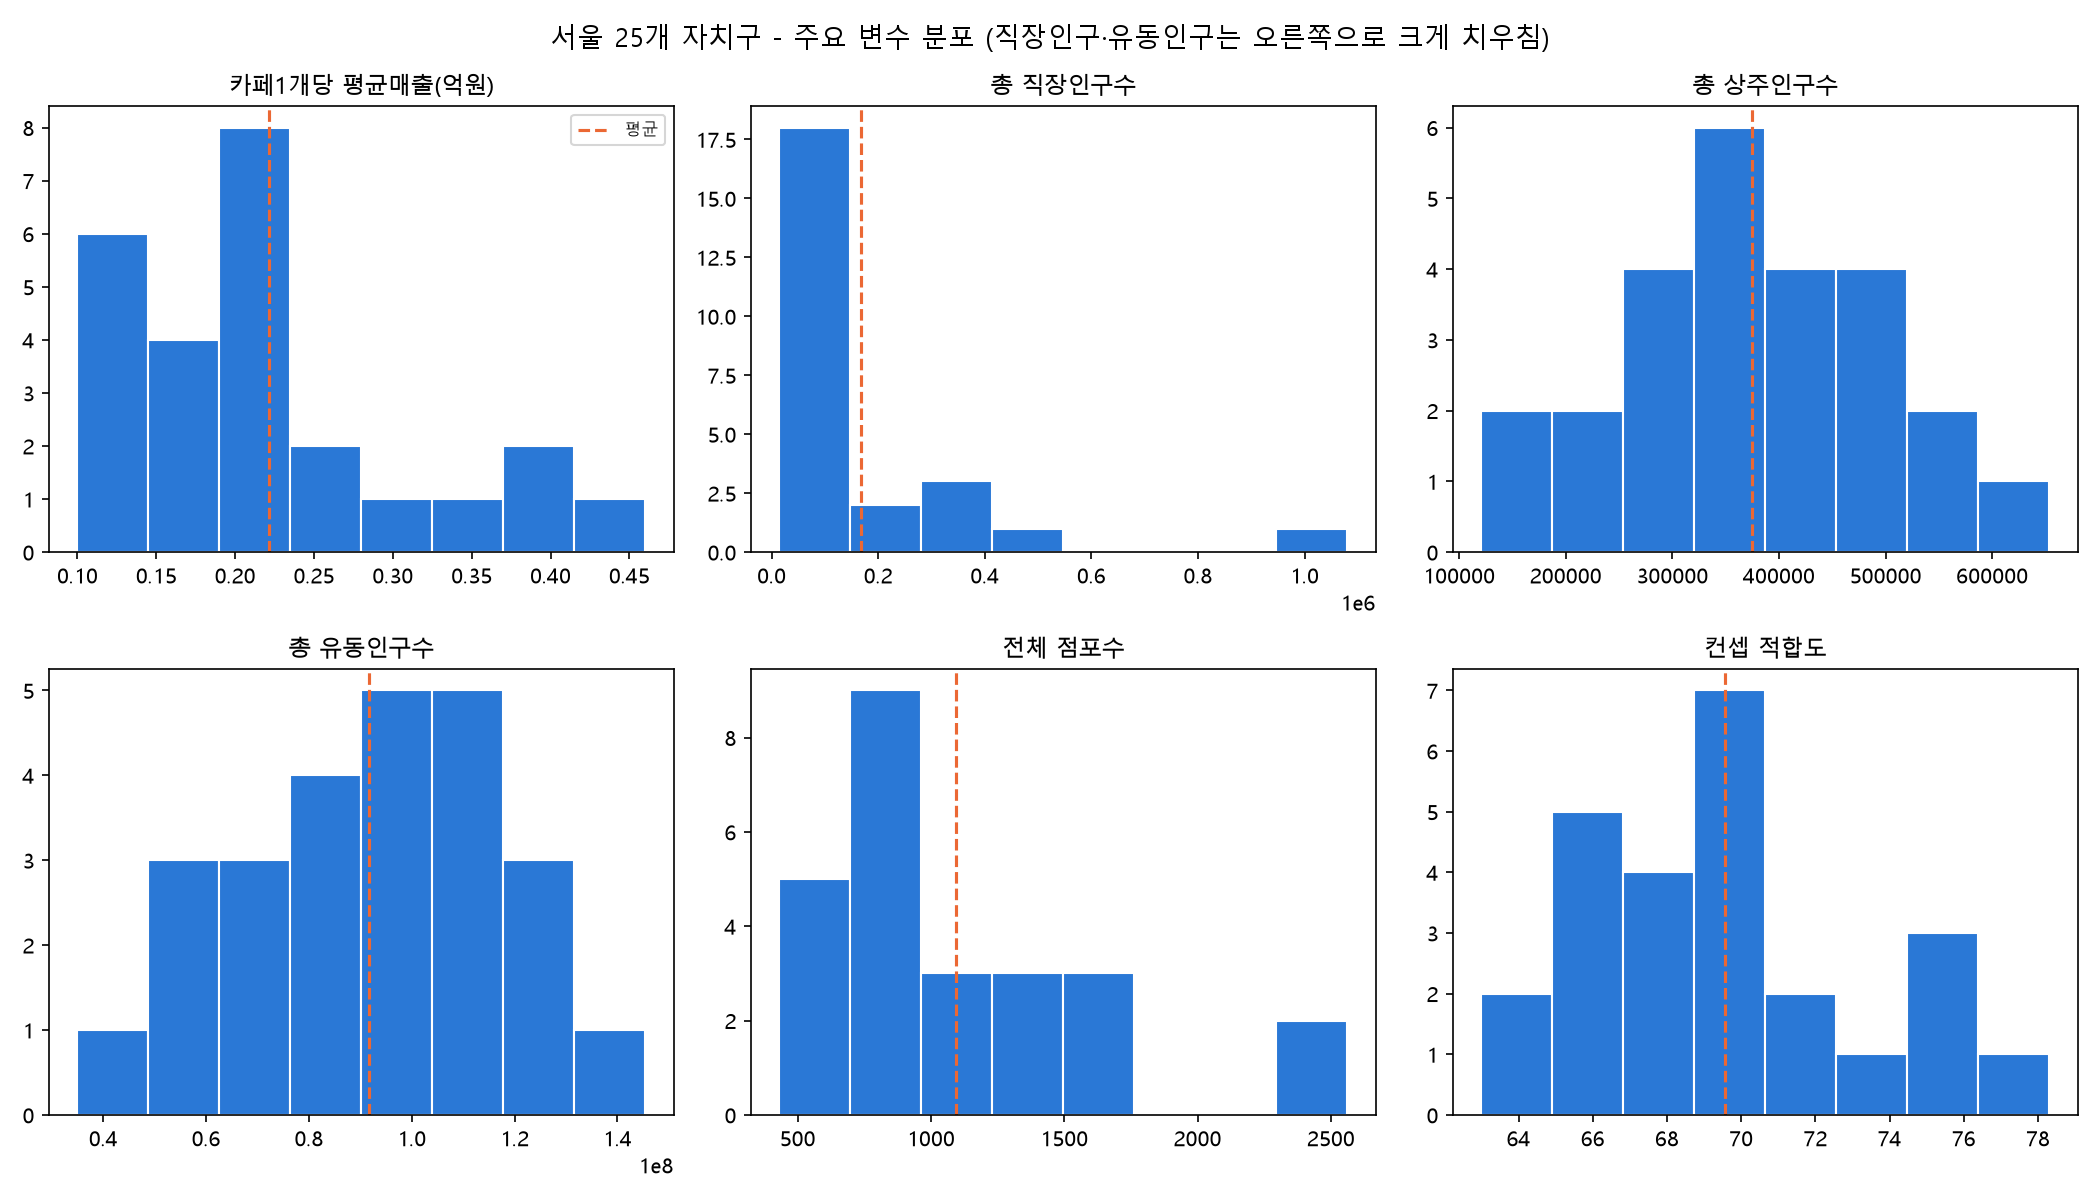
*그림1. 서울 25개 자치구 주요 변수 6종 분포 히스토그램*

### 6-2. 서울시 전체 카페 매출 시계열

2021년 1분기부터 2026년 1분기까지 21개 분기 동안 서울시 전체 카페(커피-음료) 매출을 확인한 결과, 매년 1분기(1~3월)마다 뚜렷하게 매출이 꺾이는 계절성이 반복적으로 나타났다(2022~2025년 모두 동일 패턴). 계절성을 제외하면 2021~2024년까지 완만한 우상향 추세를 보이다가 2025년 이후로는 대체로 보합 흐름이다. 이 계절성 때문에 4장의 "성장률"은 반드시 같은 분기가 아닌 연중 흐름(1분기→4분기)으로 계산해 계절 효과를 배제했다.

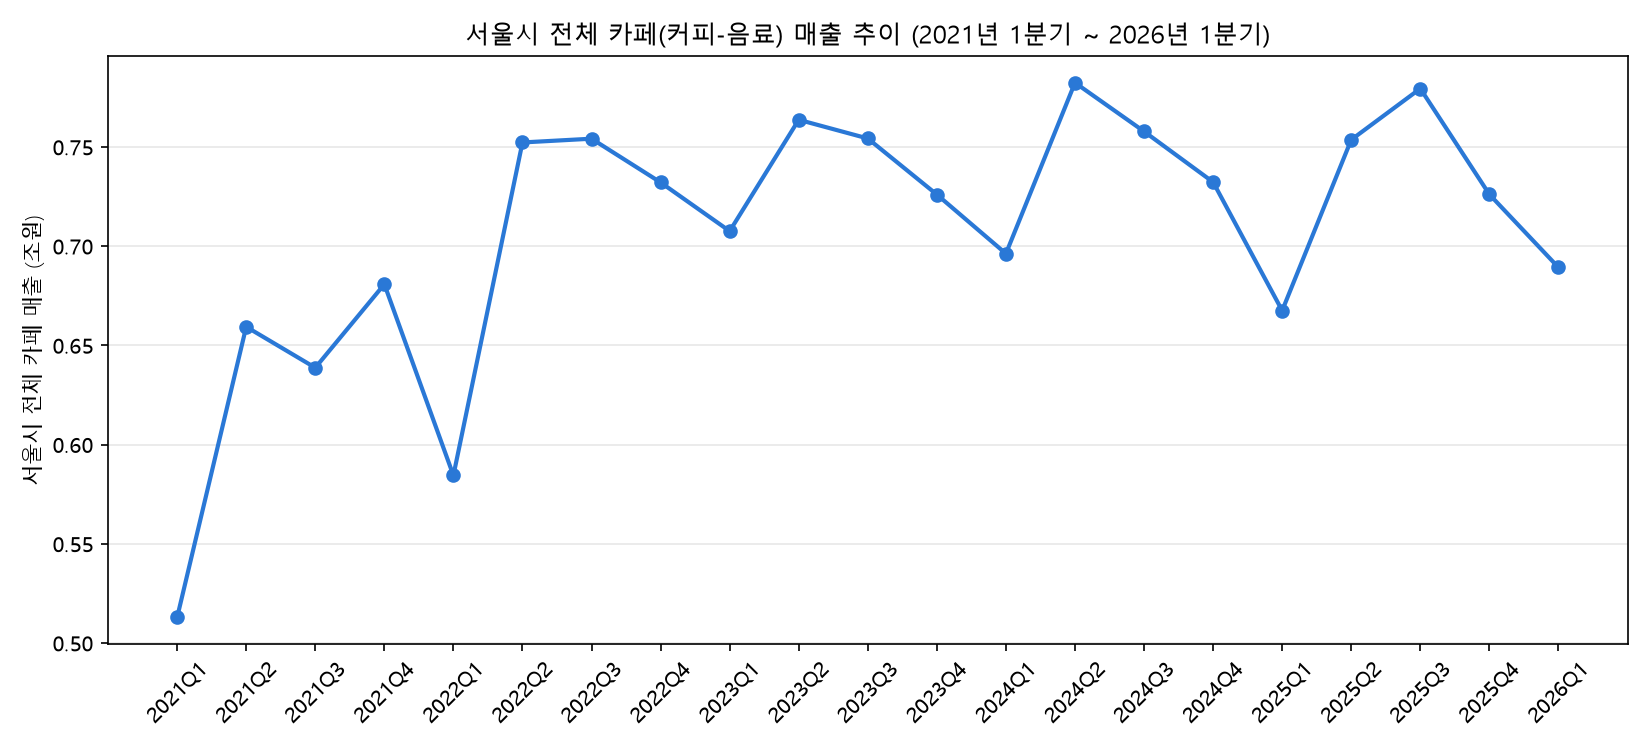
*그림2. 서울시 전체 카페 매출 추이 (2021Q1~2026Q1)*

### 6-3. Top5 자치구별 매출 추이 비교

7장에서 도출되는 Top5 자치구(중구·강남구·종로구·서초구·영등포구)의 카페1개당 매출을 21개 분기에 걸쳐 비교한 결과, 중구가 거의 전 기간에 걸쳐 1위를 유지했고 5개 자치구 간 순위 역전이 드물게만 나타났다. 즉 최신 1개 분기 스냅샷만으로 도출한 순위가 우연한 결과가 아니라 시계열 전반에 걸쳐 일관된 패턴이라는 근거가 된다.

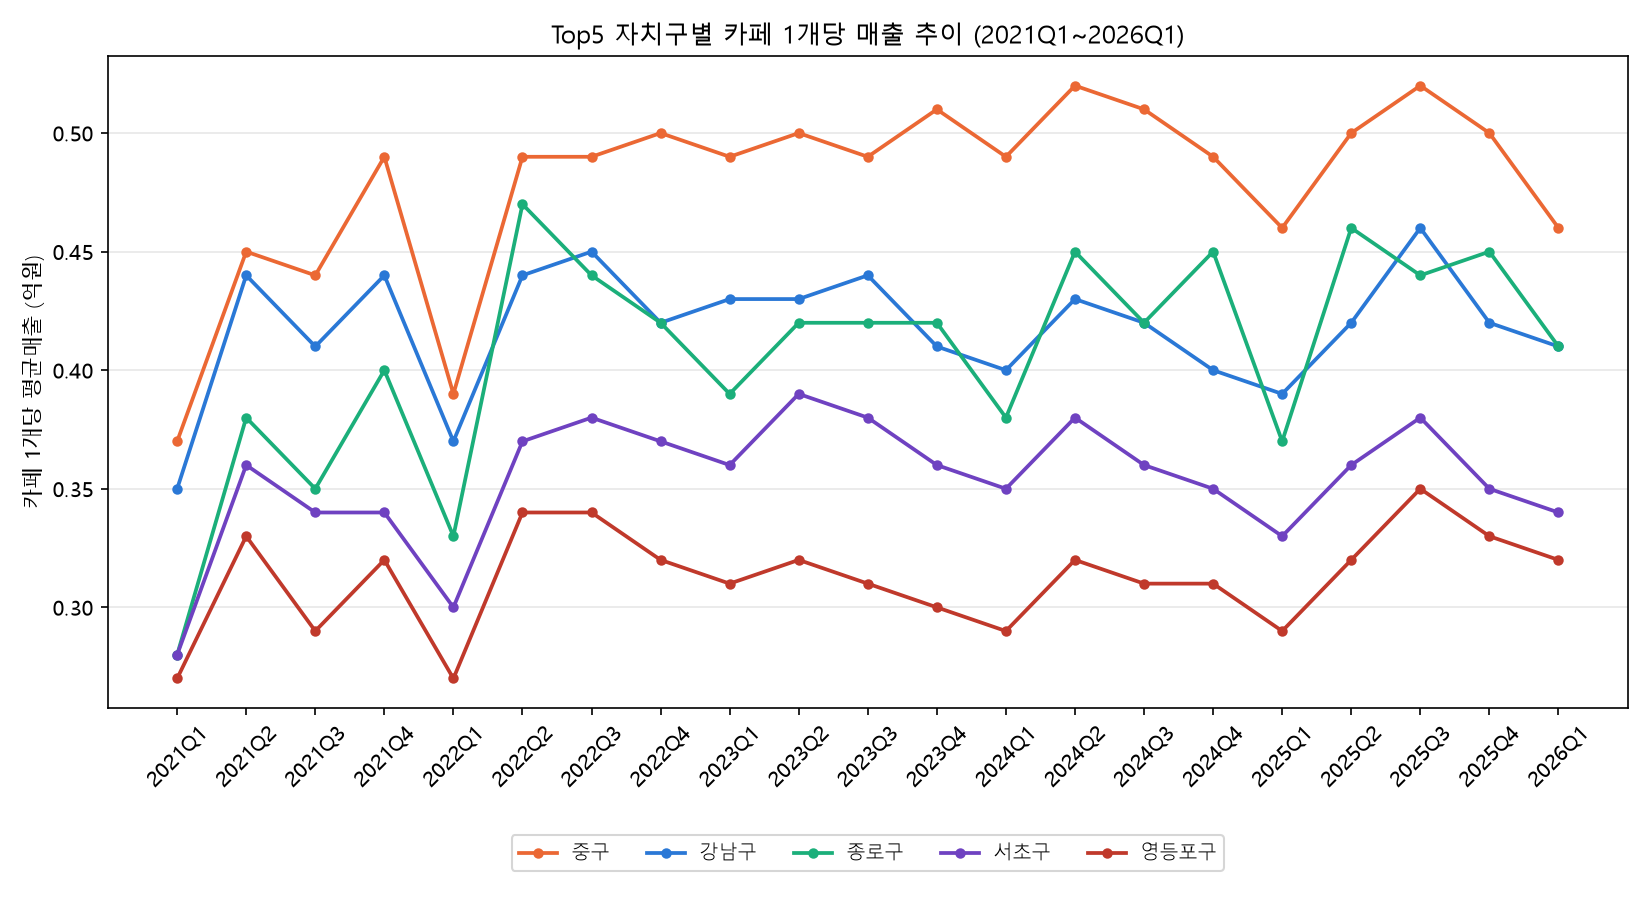
*그림3. Top5 자치구별 카페1개당 매출 추이 비교 (2021Q1~2026Q1)*

### 6-4. 이상치 확인

카페1개당_평균매출 분포를 박스플롯으로 확인한 결과 중구가 이상치(outlier) 범위에 위치했다. 다만 6-3에서 확인했듯 중구는 21개 분기 내내 일관되게 최고 매출을 기록해왔으므로, 이는 데이터 오류가 아니라 도심 업무지구라는 지역 특성이 반영된 실제 관측값으로 판단해 제거하지 않고 그대로 분석에 포함했다.

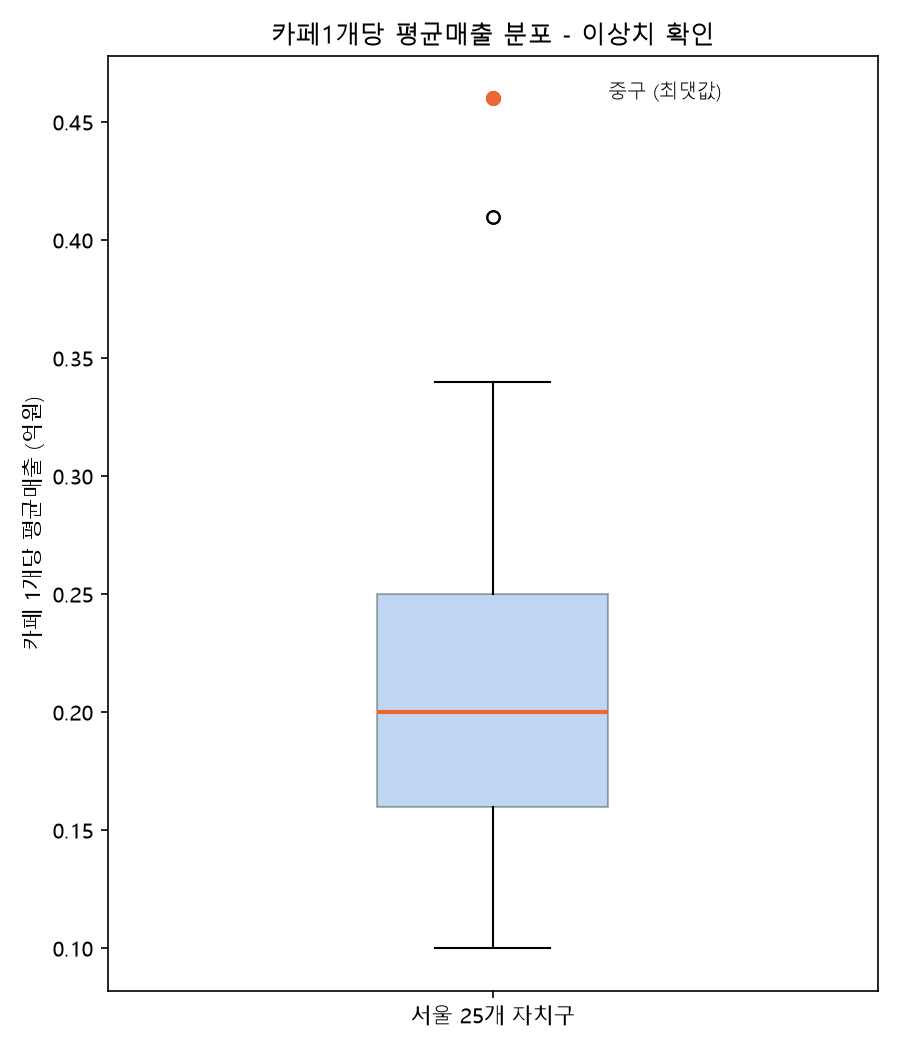
*그림4. 카페1개당 평균매출 박스플롯 — 중구 이상치 확인*

## 7. 변수 선택 (다중공선성 검증)

카페1개당_평균매출(종속변수)과 배후 수요 지표 9종의 상관계수를 확인했다. 전체_점포_수(0.696)는 상관계수 자체는 높지만 카페1개당_평균매출의 분모를 구성하는 변수이기 때문에 회귀모델에 포함하면 "매출을 매출로 설명하는" 순환논리에 빠질 위험이 있어 제외했다. 최종적으로 상관계수가 가장 높고 다중공선성 문제가 없는 총_직장_인구_수를 채택했으며, 6-1에서 확인한 오른쪽 치우침 때문에 로그 변환한 log(총_직장_인구_수)를 최종 설명변수로 사용했다(상세 회귀 결과는 모델링결과보고서 참고).

| 변수 | 상관계수 | 채택 여부 |
|---|---|---|
| **총_직장_인구_수** | **0.761** | **채택** |
| 전체_점포_수 | 0.696 | 제외 (다중공선성 — 종속변수의 분모라 순환논리 위험) |
| 지하철_역_수 | 0.572 | 미채택 (직장인구와 중복 정보) |
| 운영_영업_개월_평균 | 0.555 | 미채택 (상권 안정성 참고지표로만 활용) |
| 집객시설_수 | 0.441 | 미채택 |
| 컨셉_적합도 | 0.428 | 미채택 (별도 지표로 활용 — 5장 참고) |
| 총_가구_수 | -0.344 | 미채택 |
| 총_상주인구_수 | -0.288 | 미채택 |
| 총_유동인구_수 | -0.007 | 미채택 (거의 무관) |

## 8. 소표본 노이즈 필터링

행정동 단위로 드릴다운할 때는 점포수가 극히 적은 행정동에서 카페1개당매출이 불안정하게 튀는 문제가 있어(부산·경남 분석의 거창군·통영시 사례와 동일한 맥락), Top5 자치구 드릴다운 단계에서는 점포 5개 미만을, 서울 전체 최종후보 선정 단계에서는 점포 20개 미만을 참고용으로만 분리하고 안정적 표본에서 후보를 선정했다.

## 9. EDA 결론

- 결측치 없음(25개 자치구 전부 완비), 총_직장_인구_수·총_유동인구_수는 오른쪽으로 치우친 분포 → 로그 변환 필요성 확인
- 서울시 전체 카페 매출은 매년 1분기 계절성이 뚜렷 → 성장률은 연중(1분기→4분기) 기준으로 계산
- 중구는 21개 분기 내내 일관된 1위 → 박스플롯상 이상치이나 실제 관측값으로 판단해 유지
- 최종 채택 변수: log(총_직장_인구_수) — 상관계수 0.761로 가장 높고 다중공선성·순환논리 문제 없음
- 제외 변수: 전체_점포_수(종속변수와 순환논리 위험), 그 외 배후수요 지표는 직장인구 대비 설명력이 낮아 미채택
- **다음 단계: log(총_직장_인구_수) 단변량 회귀모델을 구성하고 LOOCV로 검증 — 상세 내용은 모델링결과보고서 참고**

# 모델링결과보고서 — 서울시 카페 입지 분석

**작성자:** 김석호 | **프로젝트:** 엘리스 ABA 1차 프로젝트 (서울 버전) | **기준 데이터:** 서울시 상권분석서비스(2026년 1분기 기준, 행정동 단위는 2025년 4분기까지)

---

## 1. 목적

베이커리 물류 회사가 서울에 신규 플래그십 카페를 낸다면 어느 자치구·행정동이 적합한 입지인지를, "카페 1개당 평균매출"을 종속변수로 하는 회귀모델로 설명하고, 이를 근거로 최종 후보 입지를 선정한다.

기획 단계(1차 기획안)에서는 부산·경남 상가정보를 바탕으로 "카페 경쟁밀도"를 예측하고 잔차로 저평가 입지를 찾는 방식이었다. 서울 데이터로 전환하면서는 실제 매출액을 이미 알고 있으므로, 모델의 역할이 "매출을 추정하기 위한 대리모델"에서 **"왜 특정 자치구의 매출이 더 높은가를 설명하는 모델"**로 바뀌었다.

## 2. 데이터 및 표본

- 분석 단위: 서울시 25개 자치구 (표본 수 n=25)
- 종속변수: 카페1개당_평균매출 = 당월_매출_금액 ÷ 전체_점포_수 (서비스_업종_코드 = CS100010, 커피-음료)
- 후보 독립변수 9종: 총_직장_인구_수, 총_상주인구_수, 총_가구_수, 총_유동인구_수, 집객시설_수, 지하철_역_수, 컨셉_적합도(아침·점심·저녁 매출비중 합), 전체_점포_수, 운영_영업_개월_평균
- 표본이 25개뿐이라는 점은 부산·경남 단계(34개)와 마찬가지로 다중회귀 시 과적합 위험이 크다는 것을 의미하며, 이 보고서 전체에서 이 제약을 계속 고려한다.

## 3. 변수 탐색 — 어떤 변수가 매출과 관련 있는가

카페1개당_평균매출과 후보 변수 9종의 상관계수(절댓값 큰 순):

| 변수 | 상관계수 r |
|---|---|
| 총_직장_인구_수 | **0.761** |
| 전체_점포_수 | 0.696 |
| 지하철_역_수 | 0.572 |
| 운영_영업_개월_평균 | 0.555 |
| 집객시설_수 | 0.441 |
| 컨셉_적합도 | 0.428 |
| 총_가구_수 | -0.344 |
| 총_상주인구_수 | -0.288 |
| 총_유동인구_수 | -0.007 |

총_직장_인구_수가 가장 강한 단일 설명변수로 확인됐다. 흥미로운 점은 총_상주인구_수·총_가구_수가 오히려 약한 음의 상관을 보인다는 것 — 이는 "사람이 많이 사는 곳"보다 "사람이 일하러 오는 곳"이 카페 매출과 더 밀접하다는 것을 시사하며, 34번 분석(주간인구지수)에서 다시 확인한 패턴과 일치한다.

**다중공선성 확인 — 후보 변수 간 상관관계**

총_직장_인구_수는 집객시설_수(r=0.75)·지하철_역_수(r=0.67)·전체_점포_수(r=0.77)와도 상관이 높다. 즉 이 변수들은 서로 독립적인 정보라기보다 "업무지구 성격"이라는 하나의 공통 축을 각자 다른 방식으로 반영하고 있을 가능성이 크다. 25개 표본에 이런 변수들을 동시에 넣으면 계수가 불안정해지므로, 다음 절의 모델링에서는 가장 설명력이 높고 해석이 명확한 총_직장_인구_수 하나만 채택한다.

참고로 상권_변화_지표_명(정체/상권축소/상권확장/다이나믹)별 평균 매출도 확인했으나, "정체" 상태 자치구의 평균매출(0.30억원)이 오히려 "다이나믹" 상태(0.18억원)보다 높게 나와 — 이 지표 자체를 회귀 설명변수로 쓰기보다는 3장(최종 후보 선정)의 "역성장 필터"처럼 보조 신호로만 활용한다.

## 4. 모델링

### 4-1. 원본 값 vs 로그 변환 비교

총_직장_인구_수는 자치구 간 편차가 매우 크다(최소 14,740명 ~ 최대 1,079,924명, 약 73배 차이). 이런 분포에서는 로그 변환이 이상치(극단적으로 직장인구가 많은 강남구 등) 하나에 모델이 과도하게 끌려가는 것을 막아준다.

| 모델 | 전체학습 R² | LOOCV R² |
|---|---|---|
| 총_직장_인구_수 (원본) | 0.5789 | 0.1919 |
| log(총_직장_인구_수) | **0.6748** | **0.6137** |

로그 변환 모델은 전체학습 R²와 LOOCV R²의 차이가 크지 않다(0.67 → 0.61). 반면 원본 값 모델은 표본 안에서는 0.58이 나오다가 LOOCV로 검증하면 0.19까지 떨어져 — 부산·경남 단계에서 겪었던 과적합 패턴(표본 내 R²=0.80 → LOOCV R²=0.27)과 유사한 불안정성을 보인다. 따라서 **log(총_직장_인구_수) 단일변수 모델을 최종 채택**한다.

### 4-2. 다변수 모델을 채택하지 않은 이유

3장에서 확인했듯 전체_점포_수·지하철_역_수·집객시설_수는 총_직장_인구_수와 상관이 0.66~0.77로 높다. 여기에 더해 이번 단계에서 새로 확인한 음식_지출_총금액(소비-자치구)·아파트_평균_시가(아파트-자치구) 역시 총_직장_인구_수와 각각 r=0.837, r=0.75로 강한 다중공선성을 보였다(37번 분석). 25개 표본에서 이런 변수들을 추가하면 표본 내 R²는 높아 보일 수 있어도 LOOCV 검증에서 무너질 가능성이 크다고 판단해, **모델은 단일변수로 유지하고 나머지 변수들은 모델 밖에서 가설을 뒷받침하는 보완 근거로만 사용**했다(37번 방법1~3 참고).

### 4-3. 최종 채택 모델

```
카페1개당_평균매출 = 7,086,542 × log(총_직장_인구_수) − 58,545,204
```

- 전체학습 R² = 0.6748, **LOOCV R² = 0.6137**
- 해석: 직장인구가 많을수록 카페1개당 평균매출이 로그 스케일로 증가하는 관계이며, 계수가 양수(+7,086,542)로 방향성이 뚜렷함
- LOOCV(자치구 25곳을 한 곳씩 빼고 재검증)로도 설명력의 약 61%가 유지돼, 특정 자치구 하나에 모델이 좌우되지 않는 비교적 안정적인 모델로 판단

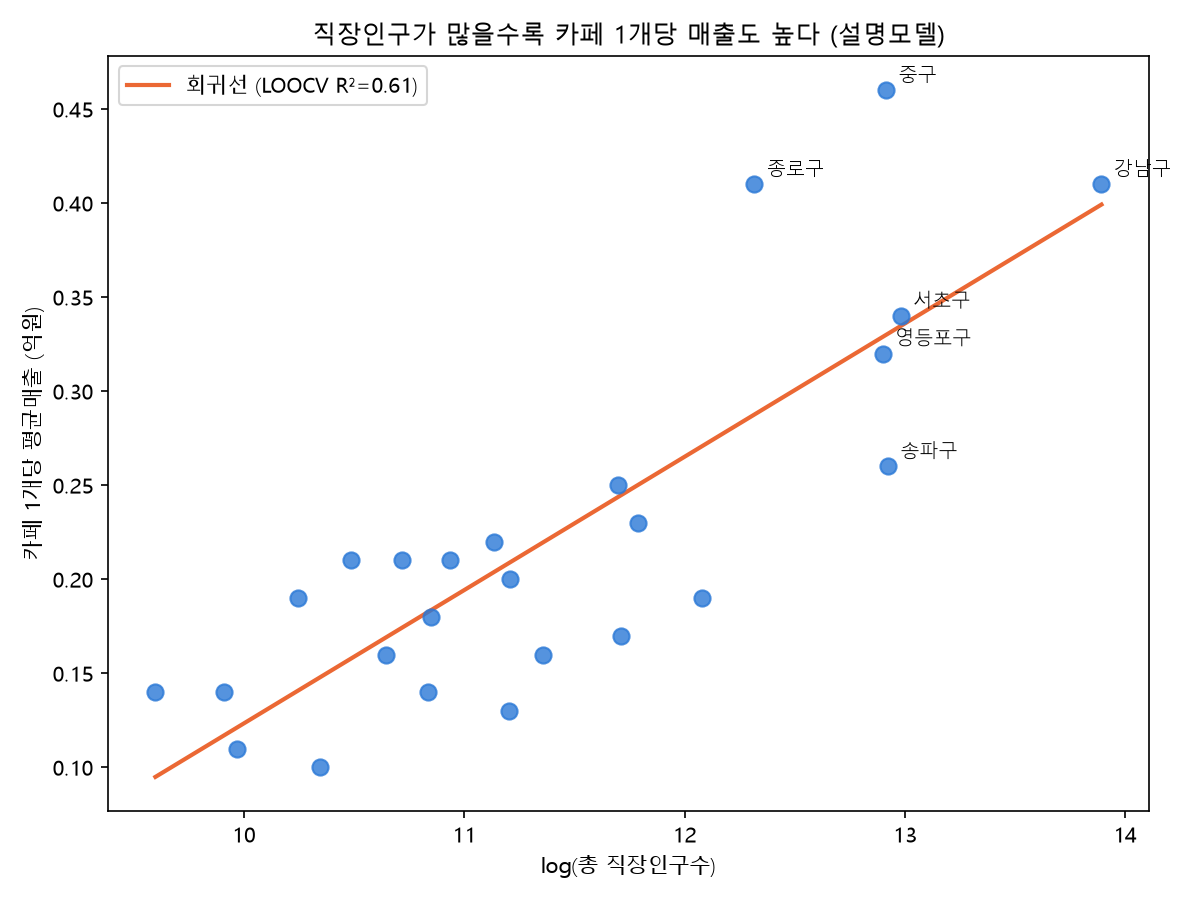

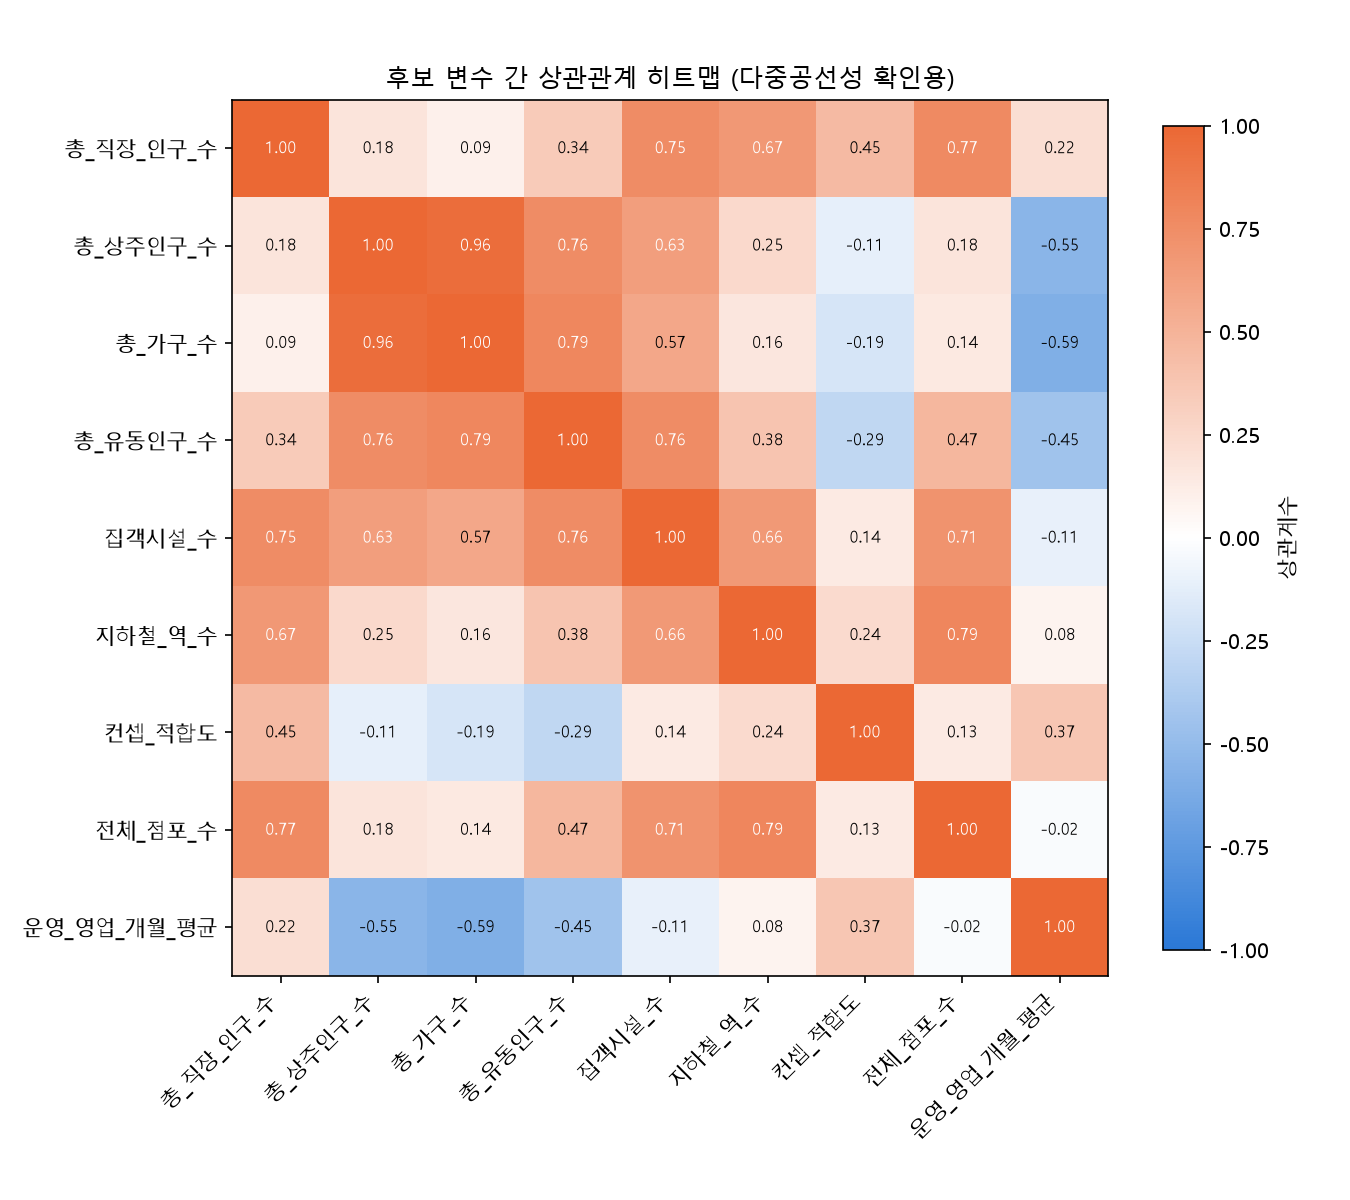

## 5. 잔차 분석 — 직장인구 대비 매출이 예상과 다른 자치구

잔차 = 실제 카페1개당_평균매출 − 모델 예측값. 잔차가 양수면 "직장인구 수준 대비 매출이 예상보다 높다", 음수면 "예상보다 낮다"는 뜻이다.

**예상보다 매출이 높은 자치구 Top5**

| 자치구 | 실제(억원) | 예측(억원) | 잔차(억원) | 상권 상태 |
|---|---|---|---|---|
| 중구 | 0.46 | 0.33 | +0.13 | 정체 |
| 종로구 | 0.41 | 0.29 | +0.12 | 정체 |
| 노원구 | 0.19 | 0.14 | +0.05 | 다이나믹 |
| 서대문구 | 0.21 | 0.16 | +0.05 | 상권확장 |
| 강북구 | 0.14 | 0.09 | +0.05 | 다이나믹 |

**예상보다 매출이 낮은 자치구 Top5**

| 자치구 | 실제(억원) | 예측(억원) | 잔차(억원) | 상권 상태 |
|---|---|---|---|---|
| 구로구 | 0.17 | 0.24 | −0.08 | 상권축소 |
| 강서구 | 0.13 | 0.21 | −0.08 | 다이나믹 |
| 용산구 | 0.19 | 0.27 | −0.08 | 정체 |
| 송파구 | 0.26 | 0.33 | −0.07 | 상권축소 |
| 양천구 | 0.16 | 0.22 | −0.06 | 다이나믹 |

중구·종로구는 직장인구 수준만으로 설명되는 것보다도 매출이 더 높은 지역 — 관광객·유동인구 등 직장인구 외 다른 수요가 추가로 작용하고 있을 가능성을 시사한다. 반대로 구로구·강서구·송파구는 직장인구는 많은 편이지만 매출이 그에 못 미쳐, 이미 카페 공급이 포화 상태이거나 다른 업종에 소비가 분산되고 있을 가능성이 있다(용산구·송파구는 상권변화지표도 "정체"·"상권축소"로 일치하는 신호).

## 6. 행정동 드릴다운 및 최종 후보 선정

### 6-1. 대상 범위

자치구 단위 최종 순위 Top5(중구·강남구·종로구·서초구·영등포구) 소속 행정동에서, 표본 안정성을 위해 카페 점포수 20개 미만 행정동은 "참고용"으로만 별도 표시하고 본 분석에서는 제외했다(307개 행정동이 안정 표본으로 남음).

### 6-2. 선정 기준 — 매출 스냅샷만으로는 부족한 이유

최신 분기 매출만 보면 명동(0.95억원, 매출 6위)이 상위권에 들지만, 2025년 1분기 대비 4분기 성장률이 **−5.3%로 역성장** 중이다. 스냅샷만으로 후보를 정하면 이미 꺾이고 있는 상권을 놓칠 수 있어, **① 카페1개당매출 ② 성장률 ③ 컨셉 적합도(아침·점심·저녁 매출이 고르게 분포하는지)** 세 가지를 함께 보고, 역성장(성장률 < 0) 지역은 후보에서 제외했다.

**Top20(안정 표본, 매출 상위) 중 역성장으로 제외된 지역**

| 행정동 | 점포수 | 카페1개당매출(억원) | 성장률 | 비고 |
|---|---|---|---|---|
| 명동 | 219 | 0.95 | −5.3% | 매출 6위였지만 역성장 |
| 역삼1동 | 400 | 0.88 | −1.6% | 매출 11위, 최대 표본(400개)인데도 역성장 |
| 자양3동 | 43 | 0.81 | −6.6% | |
| 위례동 | 28 | 0.78 | −22.1% | 낙폭 최대 |
| 방배본동 | 51 | 0.76 | −5.3% | |

### 6-3. 최종 후보

| 순위 | 행정동 | 점포수 | 카페1개당매출(억원) | 성장률 | 컨셉적합도 | 선정 포인트 |
|---|---|---|---|---|---|---|
| 1 | **소공동** | 124 | 1.61 | +9.6% | 74.9 | 매출 1위, 안정적 플러스 성장 |
| 2 | **잠실2동** | 24 | 1.34 | +25.6% | 66.6 | 매출 2위 + 높은 성장률 (표본은 상대적으로 작음) |
| 3 | 수서동 | 21 | 1.14 | +3.8% | 74.8 | |
| 4 | 서초4동 | 58 | 1.03 | +18.3% | 71.8 | |
| 5 | 삼성1동 | 110 | 1.02 | +45.8% | 71.3 | 성장률 최고 수준 |
| ... | **여의동** | 270 | 0.89 | +15.2% | **79.0** | 컨셉적합도 최고, 가장 큰 안정 표본(270개) |

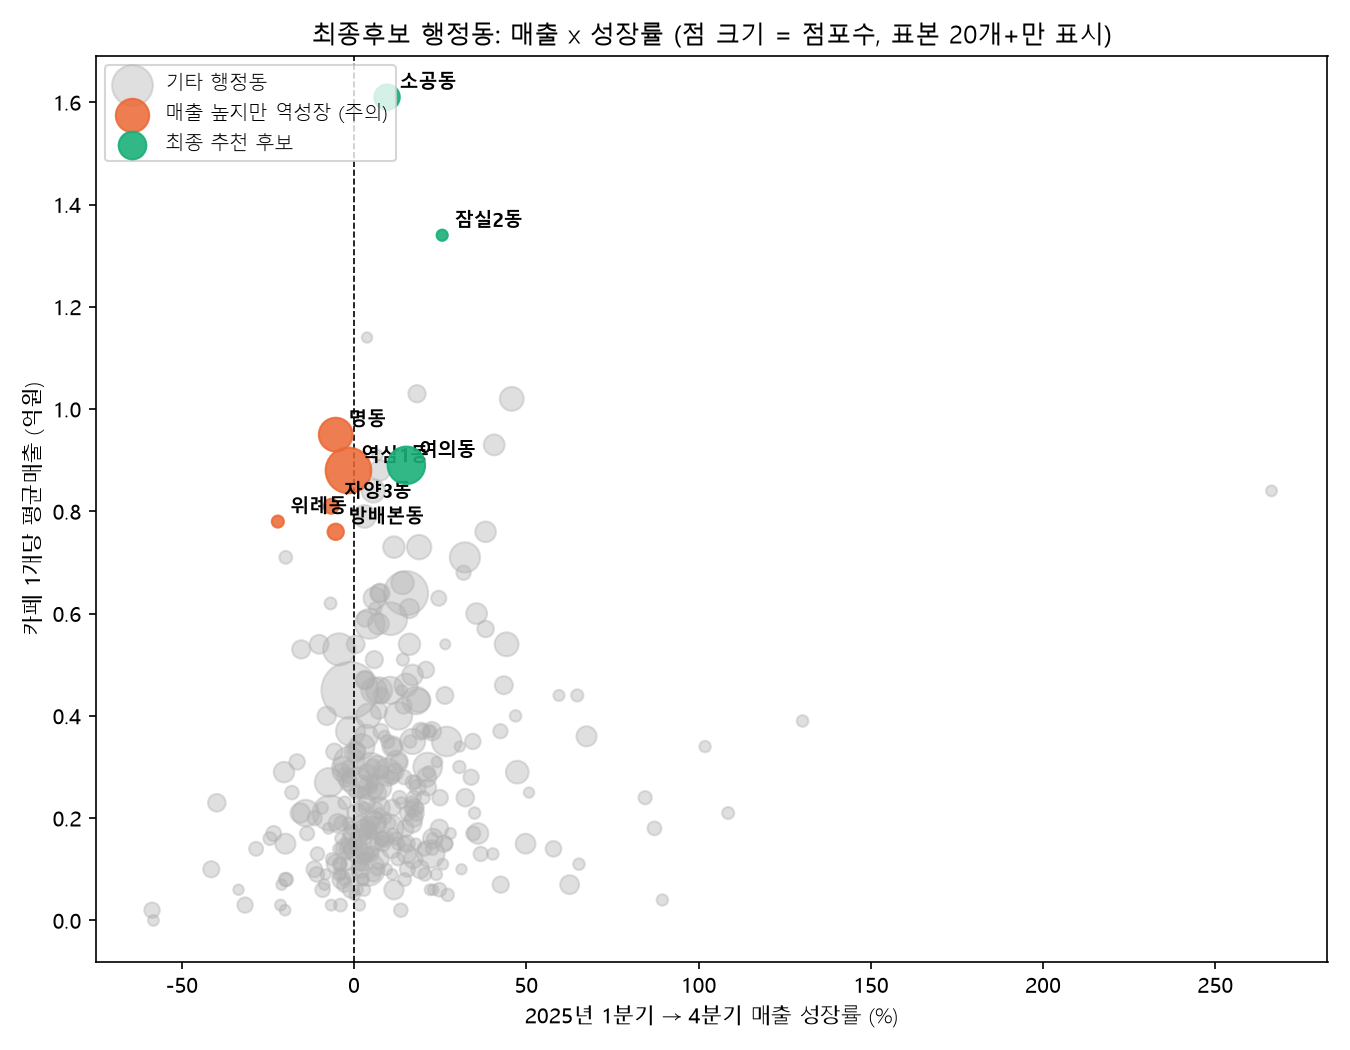

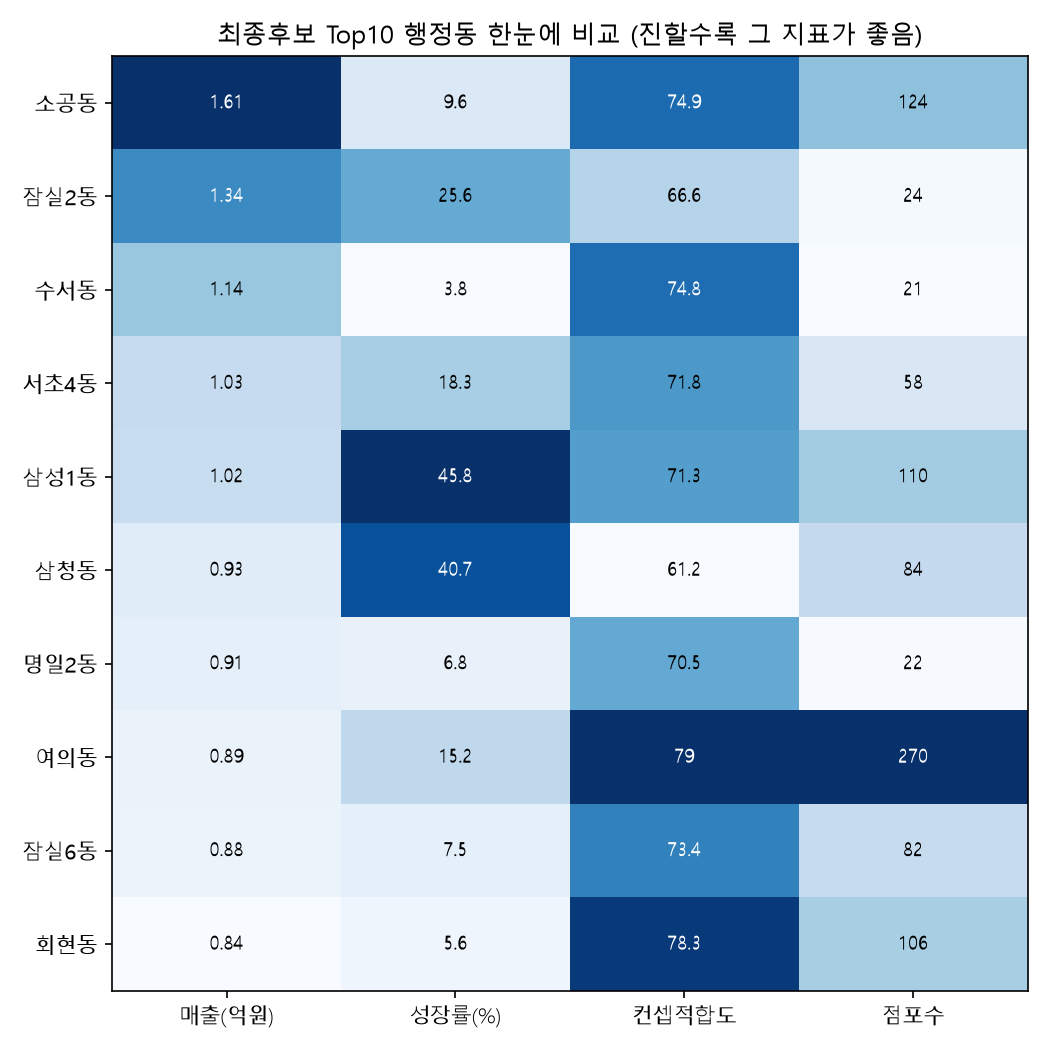

**소공동**을 1순위로 제시하는 이유는 매출·성장률·표본안정성 세 조건을 모두 상위권으로 충족하기 때문이고, **여의동**은 매출 자체는 9위권이지만 컨셉 적합도(아침·점심·저녁 매출이 고르게 분포 — 플래그십 카페 컨셉에 가장 부합)가 전체 1위이면서 표본도 270개로 가장 안정적이라 2순위 후보로 제시한다. **잠실2동**은 표본이 24개로 다소 작지만 매출 2위·성장률 25.6%로 상승세가 뚜렷해 3순위 "성장 잠재력" 후보로 제시한다.

## 7. 한계 및 유의사항

- **표본 크기**: 자치구 단위 회귀는 n=25로 매우 작다. 변수를 추가로 넣지 않고 단일변수 모델을 유지한 것, LOOCV로 검증한 것 모두 이 제약을 고려한 선택이다.
- **인과관계 아님**: 이 모델은 상관·설명 모델이며, "직장인구가 늘면 매출이 는다"는 인과를 증명하지 않는다. 직장인구와 카페매출 모두 "업무지구 성격"이라는 공통 요인의 결과일 수 있다.
- **행정동 단위 표본 편차**: 잠실2동·수서동·명일2동처럼 점포수가 20~30개 수준인 행정동은 카페 한두 곳의 매출 변동만으로도 지표가 크게 흔들릴 수 있어, 여의동(270개)·소공동(124개)보다는 해석에 더 주의가 필요하다.
- **데이터 시점 불일치**: 자치구 단위는 2026년 1분기까지, 행정동 단위는 2025년 4분기까지만 제공돼 두 레벨의 분석 시점이 한 분기 어긋나 있다.

# 최종 인사이트 리포트 — 서울시 신규 플래그십 카페 입지 분석

**작성자:** 김석호 | **프로젝트:** 엘리스 ABA 1차 프로젝트 (서울 버전)

---

## 핵심 결론 (Executive Summary)

베이커리 물류 회사가 서울에 신규 플래그십 카페를 낸다면, **소공동을 1순위**, **여의동을 2순위**, **잠실2동을 3순위** 후보로 제안한다. 이 결론은 (1) "직장인구가 많을수록 카페 매출이 높다"는 회귀모델(LOOCV R²=0.61)과, (2) 이를 상관관계·그룹비교·소비력 데이터로 세 번 교차검증한 정황 증거, (3) 매출 스냅샷이 아닌 최근 1년 성장률까지 반영한 필터링을 거쳐 도출됐다.

## 1. 프로젝트 개요

- **문제 정의:** 서울 25개 자치구·420개 행정동 중 신규 플래그십 카페를 낼 최적 입지는 어디인가?
- **데이터:** 서울시 상권분석서비스(추정매출·점포·직장인구·상주인구·유동인구·집객시설·상권변화지표·소비·아파트, 9개 카테고리 전체 활용)
- **방법론 요약:** 회귀모델로 매출을 설명하는 핵심 변수를 찾고 → 그 변수를 다른 데이터로 교차검증하고 → 행정동 단위로 드릴다운해 성장률까지 반영한 최종 후보를 선정 (세부 통계·모델 수식은 EDA_리포트_서울, 모델링결과보고서_서울 참고)

## 2. 핵심 인사이트

### 인사이트 1 — "직장인구"가 카페 매출을 가장 잘 설명하는 단일 변수다

9개 후보 변수 중 총_직장_인구_수가 카페1개당 매출과 가장 강한 상관(r=0.761)을 보였고, log(총_직장_인구_수) 단일변수 회귀모델은 LOOCV 검증에서도 설명력의 약 61%를 유지했다. 오히려 총_상주인구_수·총_가구_수는 약한 음의 상관(r=-0.29, -0.34)을 보여 — **"사람이 많이 사는 곳"보다 "사람이 일하러 오는 곳"이 카페 사업에는 더 유리한 신호**라는 것이 이번 분석의 출발점이다.

### 인사이트 2 — 이 가설은 서로 다른 3가지 데이터에서 동일하게 확인된다

하나의 상관계수만으로 결론을 내리지 않기 위해, 서로 독립적인 세 가지 방식으로 같은 가설을 검증했다.

1. **상관관계 4종**: 직장인구는 카페 매출뿐 아니라 카페 개수(r=0.772), 점심시간 매출비중(r=0.565), 평일 매출비중(r=0.524)과도 모두 뚜렷한 양의 상관을 보였다.
2. **그룹비교**: 주간인구지수(직장인구÷상주인구×100)가 100을 넘는 "업무지구" 5곳(중구·강남구·종로구·영등포구·서초구)은, 그렇지 않은 "주거지" 20곳보다 카페1개당 평균매출이 **2.16배**, 카페 개수가 **1.80배** 높다.
3. **소비력 데이터 교차검증**: 지금까지 쓰지 않았던 소비-자치구·아파트-자치구 데이터로 확인한 결과, 매출 Top5 자치구(강남·서초·영등포·종로·중구) 중 3곳이 음식지출 Top5, 3곳이 아파트시가 Top5와 겹친다. 서로 다른 데이터가 같은 지역을 가리킨다는 것 자체가 정황 증거의 무게를 더한다.

**단, 개인 단위로 "이 손님이 직장인이었는지"까지는 데이터에 없어 확인할 수 없다.** 위 근거는 모두 자치구 단위 집계 통계이며, "직장인구가 많은 지역일수록 카페 이용이 활발한 경향이 있다"는 수준의 상관적 결론으로 해석해야 한다.

### 인사이트 3 — 업무지구형 매출은 평일·점심시간에 집중되고, 20~30대 비중이 높다

카페 매출 상위 자치구(강남구·종로구·중구·서초구·영등포구)는 평일 매출비중이 서울 평균(73.7%)보다 높고(강남구 77.6%, 중구 84.0%, 영등포구 81.1%), 매출 연령대도 20~30대 비중이 높은 편이다(강남구 40.7%, 종로구 43.5%). 반면 도봉구·중랑구·강북구 등 주거 중심 자치구는 60대 이상 매출비중이 17~21%로 눈에 띄게 높다. 이는 **플래그십 카페의 타겟(20~30대 직장인)과 업무지구의 실제 고객 구성이 일치**한다는 것을 보여준다.

다만 유동인구 자체의 20~30대 비중은 강남구(33.8%)가 오히려 관악구(43.7%)·마포구(38.6%)보다 낮게 나타나 — **"유동인구가 많다"와 "카페 매출이 높다"는 별개**라는 점도 확인됐다(총_유동인구_수와 매출의 상관계수는 r=-0.007로 사실상 무관). 유동인구 규모 자체보다는 그 인구가 어떤 목적(출근 vs 관광 vs 단순 통행)으로 그 지역에 있는지가 더 중요하다는 뜻이다.

### 인사이트 4 — 매출 스냅샷만으로는 "지금 꺾이고 있는 곳"을 놓친다

행정동 단위 최신 분기 매출만 보면 명동(0.95억원)이 매출 상위권에 들지만, 2025년 1분기 대비 4분기 성장률이 **−5.3%로 역성장 중**이었다. 같은 방식으로 역삼1동(성장률 −1.6%, 표본 400개로 최대 규모)·위례동(−22.1%)도 매출은 높지만 최근 추세가 꺾인 지역으로 확인돼, 최종 후보에서 제외했다. **"지금 잘 나가는 곳"이 아니라 "지금도 잘 나가고 앞으로도 나갈 곳"을 봐야 한다**는 것이 이번 분석의 방법론적 교훈이다.

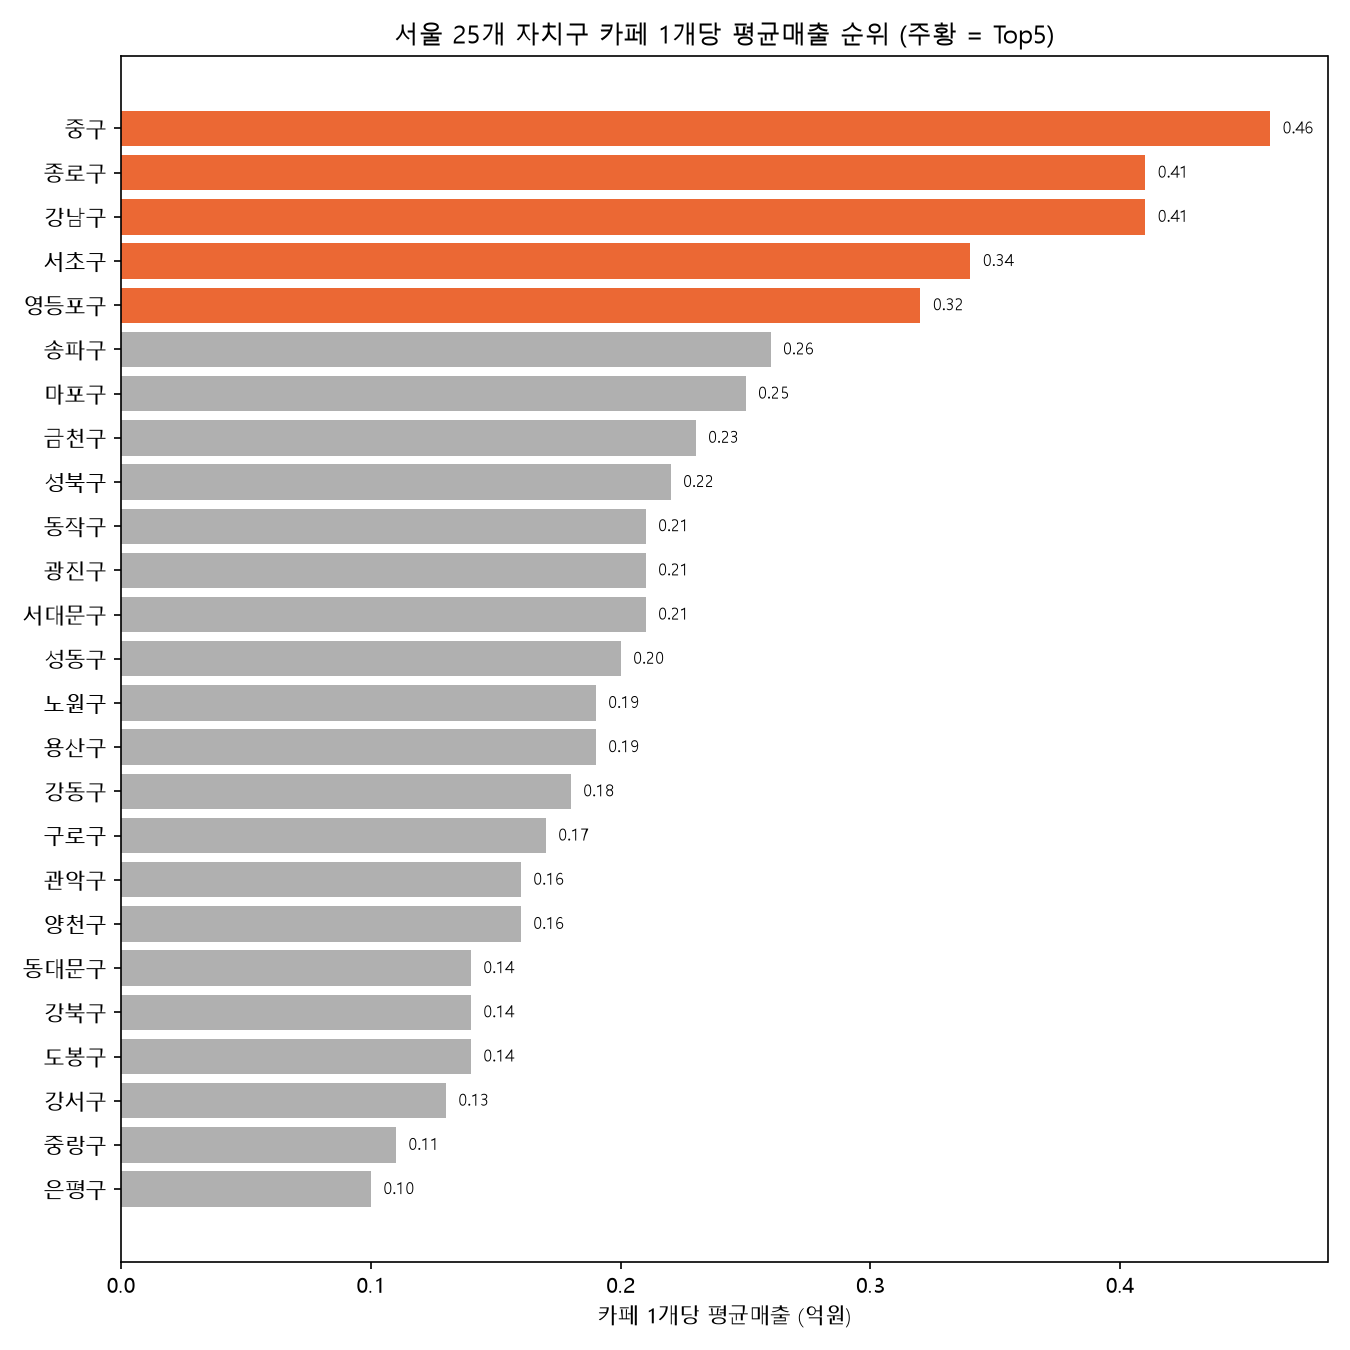

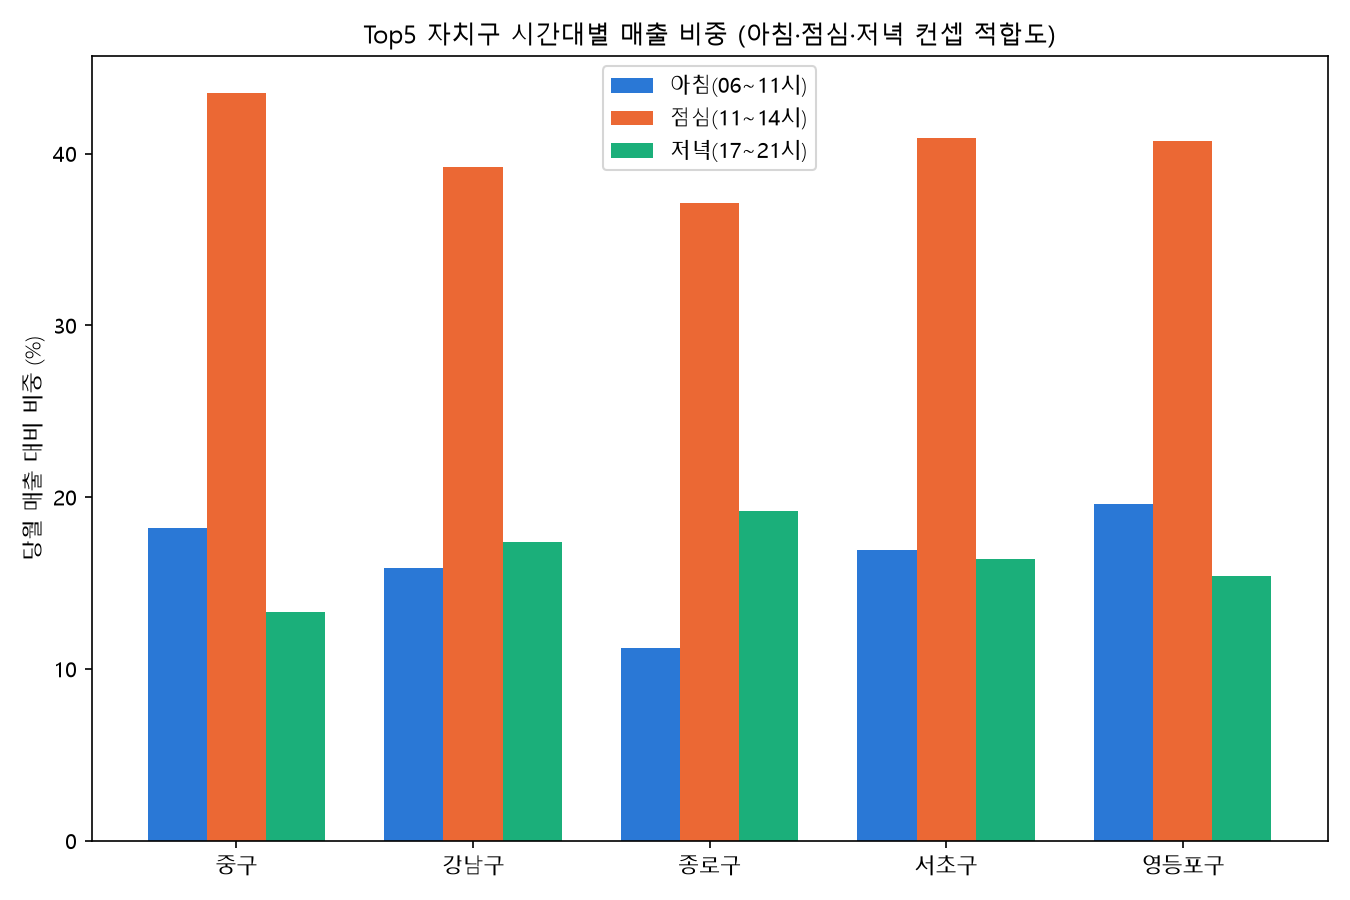

## 3. 최종 추천 입지

| 순위 | 행정동 | 소속 자치구 | 카페1개당매출 | 성장률 | 컨셉적합도 | 표본(점포수) |
|---|---|---|---|---|---|---|
| 1 | **소공동** | 중구 | 1.61억원 (전체 1위) | +9.6% | 74.9 | 124개 |
| 2 | **여의동** | 영등포구 | 0.89억원 | +15.2% | **79.0 (전체 1위)** | **270개 (최대 규모)** |
| 3 | **잠실2동** | 송파구 | 1.34억원 (전체 2위) | **+25.6% (최상위권)** | 66.6 | 24개 |

- **소공동 (1순위, 안정적 1위)**: 매출·성장률·표본 안정성을 모두 상위권으로 충족하는 가장 균형 잡힌 후보. 소속 자치구인 중구는 주간인구지수 336.0으로 서울에서 가장 업무지구 성격이 강한 지역이라, 인사이트 1~3의 논리가 가장 정확히 들어맞는 곳이기도 하다.
- **여의동 (2순위, 컨셉 최적합)**: 매출 자체는 9위권이지만 아침·점심·저녁 매출이 고르게 분포하는 컨셉 적합도가 전체 1위이고, 표본도 270개로 가장 크고 안정적이다. "하루 종일 이용되는 카페"라는 컨셉을 노린다면 가장 설득력 있는 후보.
- **잠실2동 (3순위, 성장 잠재력)**: 표본이 24개로 다소 작아 해석에 주의가 필요하지만, 매출 2위·성장률 25.6%로 상승세가 뚜렷해 "선점 효과"를 노릴 수 있는 후보.

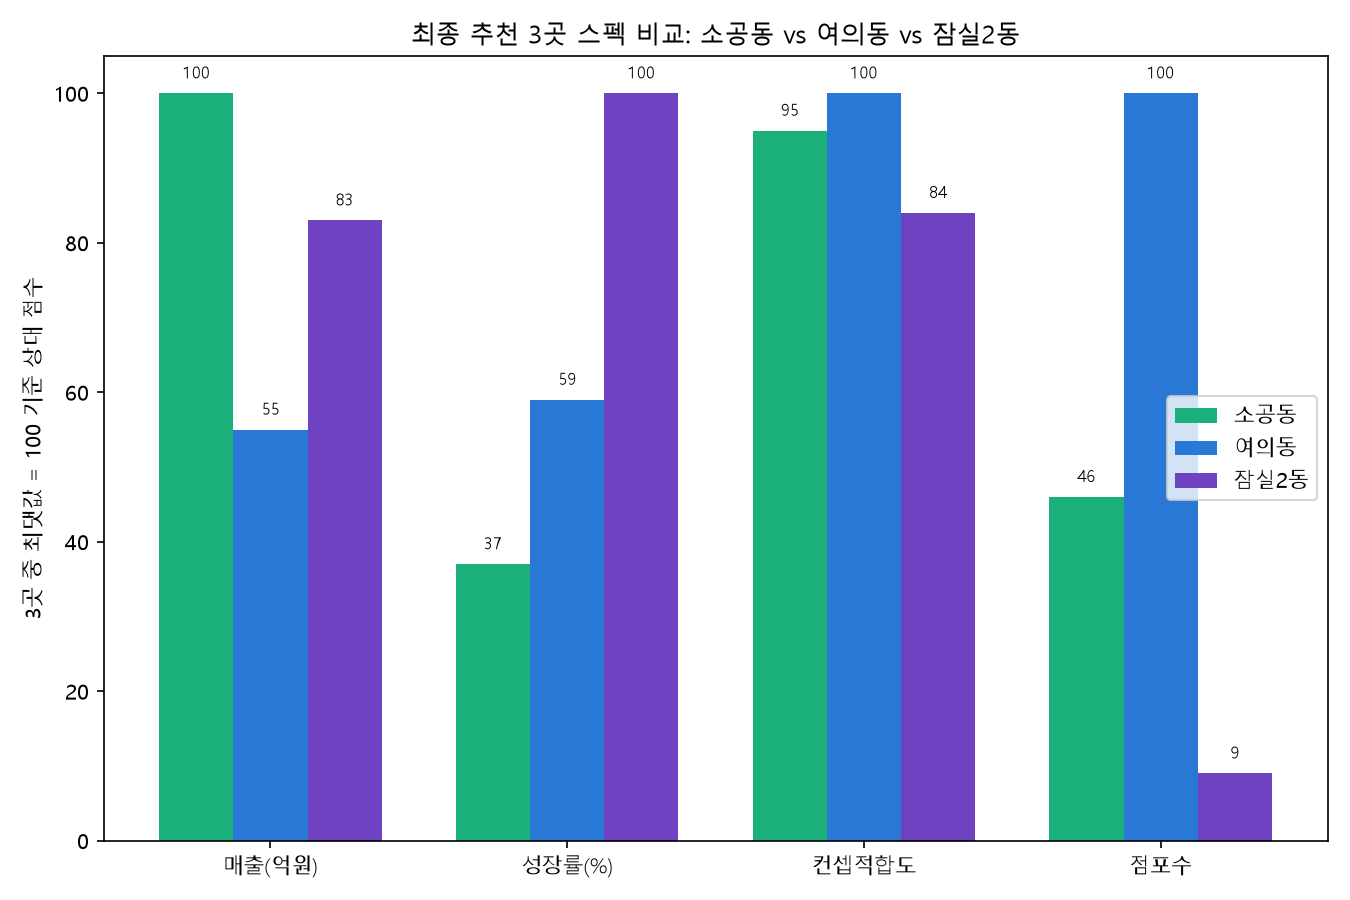

## 4. 주의가 필요한 지역

| 행정동 | 매출 순위 | 성장률 | 비고 |
|---|---|---|---|
| 명동 | 6위 (0.95억원) | −5.3% | 매출은 높지만 역성장 — 관광 수요 의존도가 높아 외부 변수에 취약할 가능성 |
| 역삼1동 | 11위 (0.88억원) | −1.6% | 표본 400개(전체 최대)로 이미 카페 공급이 포화 상태일 가능성 |
| 위례동 | Top20권 (0.78억원) | −22.1% | 낙폭 최대, 신도시 성장 둔화 가능성 |

용산구·송파구는 자치구 단위 잔차분석(모델링결과보고서 5장)에서도 "직장인구 대비 매출이 예상보다 낮은" 지역으로 확인돼, 위 행정동 단위 신호와 방향이 일치한다.

## 5. 비즈니스 제언

1. **입지 우선순위는 소공동 > 여의동 > 잠실2동**으로 진행하되, 예산·일정상 1곳만 가능하다면 소공동을 우선 검토한다.
2. 카페 컨셉을 "아침·점심·저녁 풀타임 이용"으로 잡는다면 여의동이 데이터상 가장 부합한다(컨셉적합도 79.0, 최대 표본).
3. 명동·역삼1동처럼 매출 규모만 보고 판단하면 놓치는 리스크(역성장·포화)가 있으므로, 향후 다른 후보지를 검토할 때도 성장률 지표를 반드시 함께 확인한다.
4. 카페 매출은 평일·점심시간에 집중되는 경향이 뚜렷하므로(업무지구 평균 평일비중 78.2%), 메뉴 구성·운영시간을 평일 점심 수요에 맞춰 설계하는 것이 매출 극대화에 유리하다.

## 6. 한계

- 자치구 단위 표본이 25개로 작아 회귀모델은 단일변수로 제한했다(모델링결과보고서 4-2 참고). 다변수 모델로 확장하려면 더 많은 지역(예: 수도권 전체) 데이터가 필요하다.
- "직장인이 카페를 얼마나 이용하는가"는 개인 단위로 측정할 수 없어, 자치구 단위 집계 데이터의 상관·그룹비교로만 뒷받침했다(인사이트 2 참고).
- 잠실2동은 표본(점포 24개)이 작아 실제 오픈 전 별도 현장 조사로 검증이 필요하다.
- 행정동 단위 데이터는 2025년 4분기까지만 제공되어(2026년 1분기는 자치구 단위까지만 공개), 최신 1개 분기의 흐름은 반영되지 않았다.